In [1]:
import pymc_marketing

print("pymc-marketing version:", pymc_marketing.__version__)

pymc-marketing version: 0.19.2


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

## Read the data

In [2]:
df=pd.read_csv("simulated_mmm_data.csv")

channel_columns=['channel1','channel2','channel3']
control_columns=['event_bf','event_summer']

df["date"] = pd.to_datetime(df["date"])
date_column='date'
sales_column='sales'

df.head()

,date,sales,channel1,channel2,channel3,event_bf,event_summer
0,2023-01-02,188081.87,8559.95,18121.64,14055.97,0.0,0.0
1,2023-01-09,145698.65,19951.55,0.00,2775.13,0.0,0.0
2,2023-01-16,176257.60,18564.11,0.00,8219.12,0.0,0.0
3,2023-01-23,213286.73,4922.58,17851.56,6782.28,0.0,0.0
4,2023-01-30,137048.48,3169.46,0.00,3637.16,0.0,0.0


In [19]:
df.tail()

,date,sales,channel1,channel2,channel3,event_bf,event_summer
152,2025-12-01,179649.64,14642.02,0.00,1572.88,0.0,0.0
153,2025-12-08,265663.17,2732.38,19873.62,8745.04,0.0,0.0
154,2025-12-15,216816.98,7581.63,0.00,6744.50,0.0,0.0
155,2025-12-22,191730.47,8659.05,0.00,3712.64,0.0,0.0
156,2025-12-29,196329.56,5122.86,0.00,8042.48,0.0,0.0


## Modeling

Test set starts from date: 2025-09-22 00:00:00


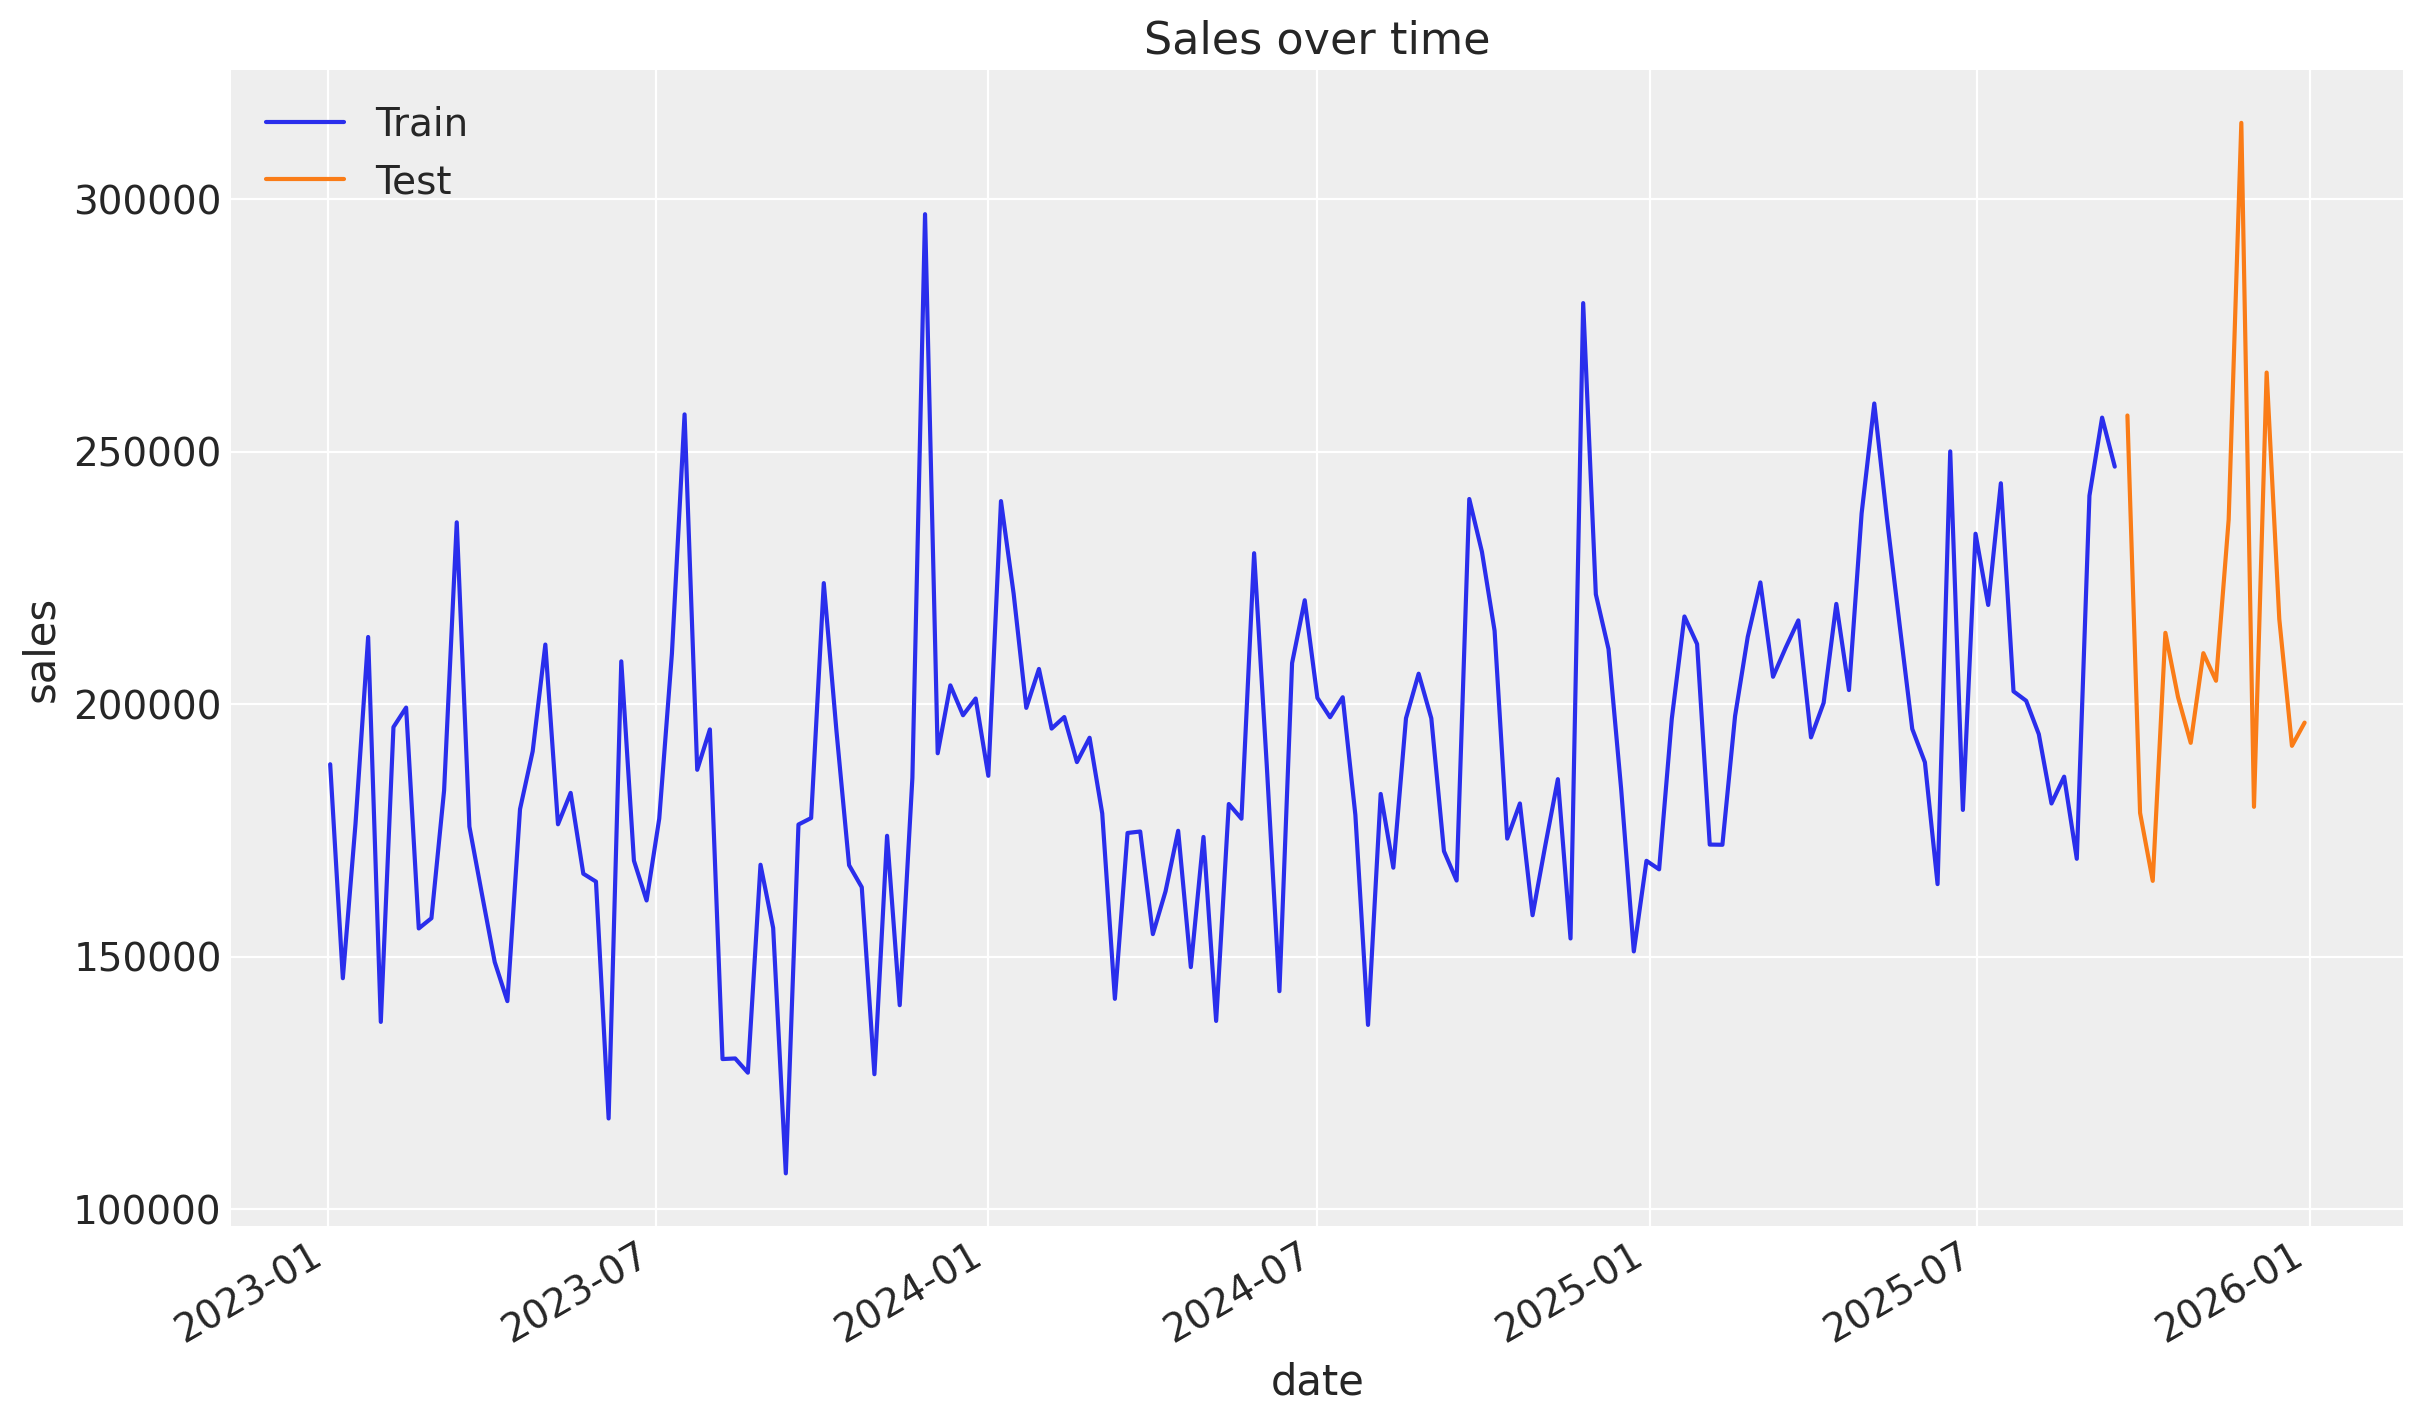

In [3]:
import matplotlib.dates as mdates

# Convert 'date' column to datetime
df["date"] = pd.to_datetime(df["date"])

# Calculate the split index for the last 10% of the dataframe
split_idx = int(len(df) * 0.9)
train_test_split_date = df.iloc[split_idx]["date"]

train_mask = df.date <= train_test_split_date
test_mask = df.date > train_test_split_date

train_df = df[train_mask]
test_df = df[test_mask]

print(f"Test set starts from date: {test_df['date'].iloc[0]}")

fig, ax = plt.subplots()
sns.lineplot(data=train_df, x="date", y="sales", color="C0", label="Train", ax=ax)
sns.lineplot(data=test_df, x="date", y="sales", color="C1", label="Test", ax=ax)

# Format x-axis for six-month intervals
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()
ax.set(title="Sales over time", xlabel="date", ylabel="sales");

In [4]:
X_train = train_df.drop(columns="sales")
X_test = test_df.drop(columns="sales")

y_train = train_df["sales"].rename('y')
y_test = test_df["sales"].rename('y')

In [5]:
n_channels = len(channel_columns)
controls = ["event_bf","event_summer"]

In [7]:
total_spend_per_channel=X_train[channel_columns].sum(axis=0)

spend_share = total_spend_per_channel / total_spend_per_channel.sum()
spend_share

channel1    0.500224
channel2    0.142880
channel3    0.356896
dtype: float64

In [8]:
prior_sigma =spend_share.to_numpy()
print(prior_sigma)

[0.50022372 0.14288049 0.35689579]


In [65]:
my_model_config = {
    "intercept": Prior("HalfNormal", sigma=0.5),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
    "adstock_alpha": Prior("Beta", alpha=1, beta=3, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.1),
    "likelihood": Prior("TruncatedNormal", lower=0, upper= df['sales'].max()*1.5, sigma=Prior("HalfNormal", sigma=0.25), dims="date"),
}

my_sampler_config = {"progressbar": True}

In [11]:
mmm = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=10),
    saturation=LogisticSaturation(),
    time_varying_intercept=False,
    yearly_seasonality=2,
    model_config=my_model_config,
    sampler_config=my_sampler_config,
)

In [21]:
mmm.build_model(X=X_train, y=y_train)

# Add the contribution variables to the model
# to track them in the model and trace.
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

## Prior predictive checks

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


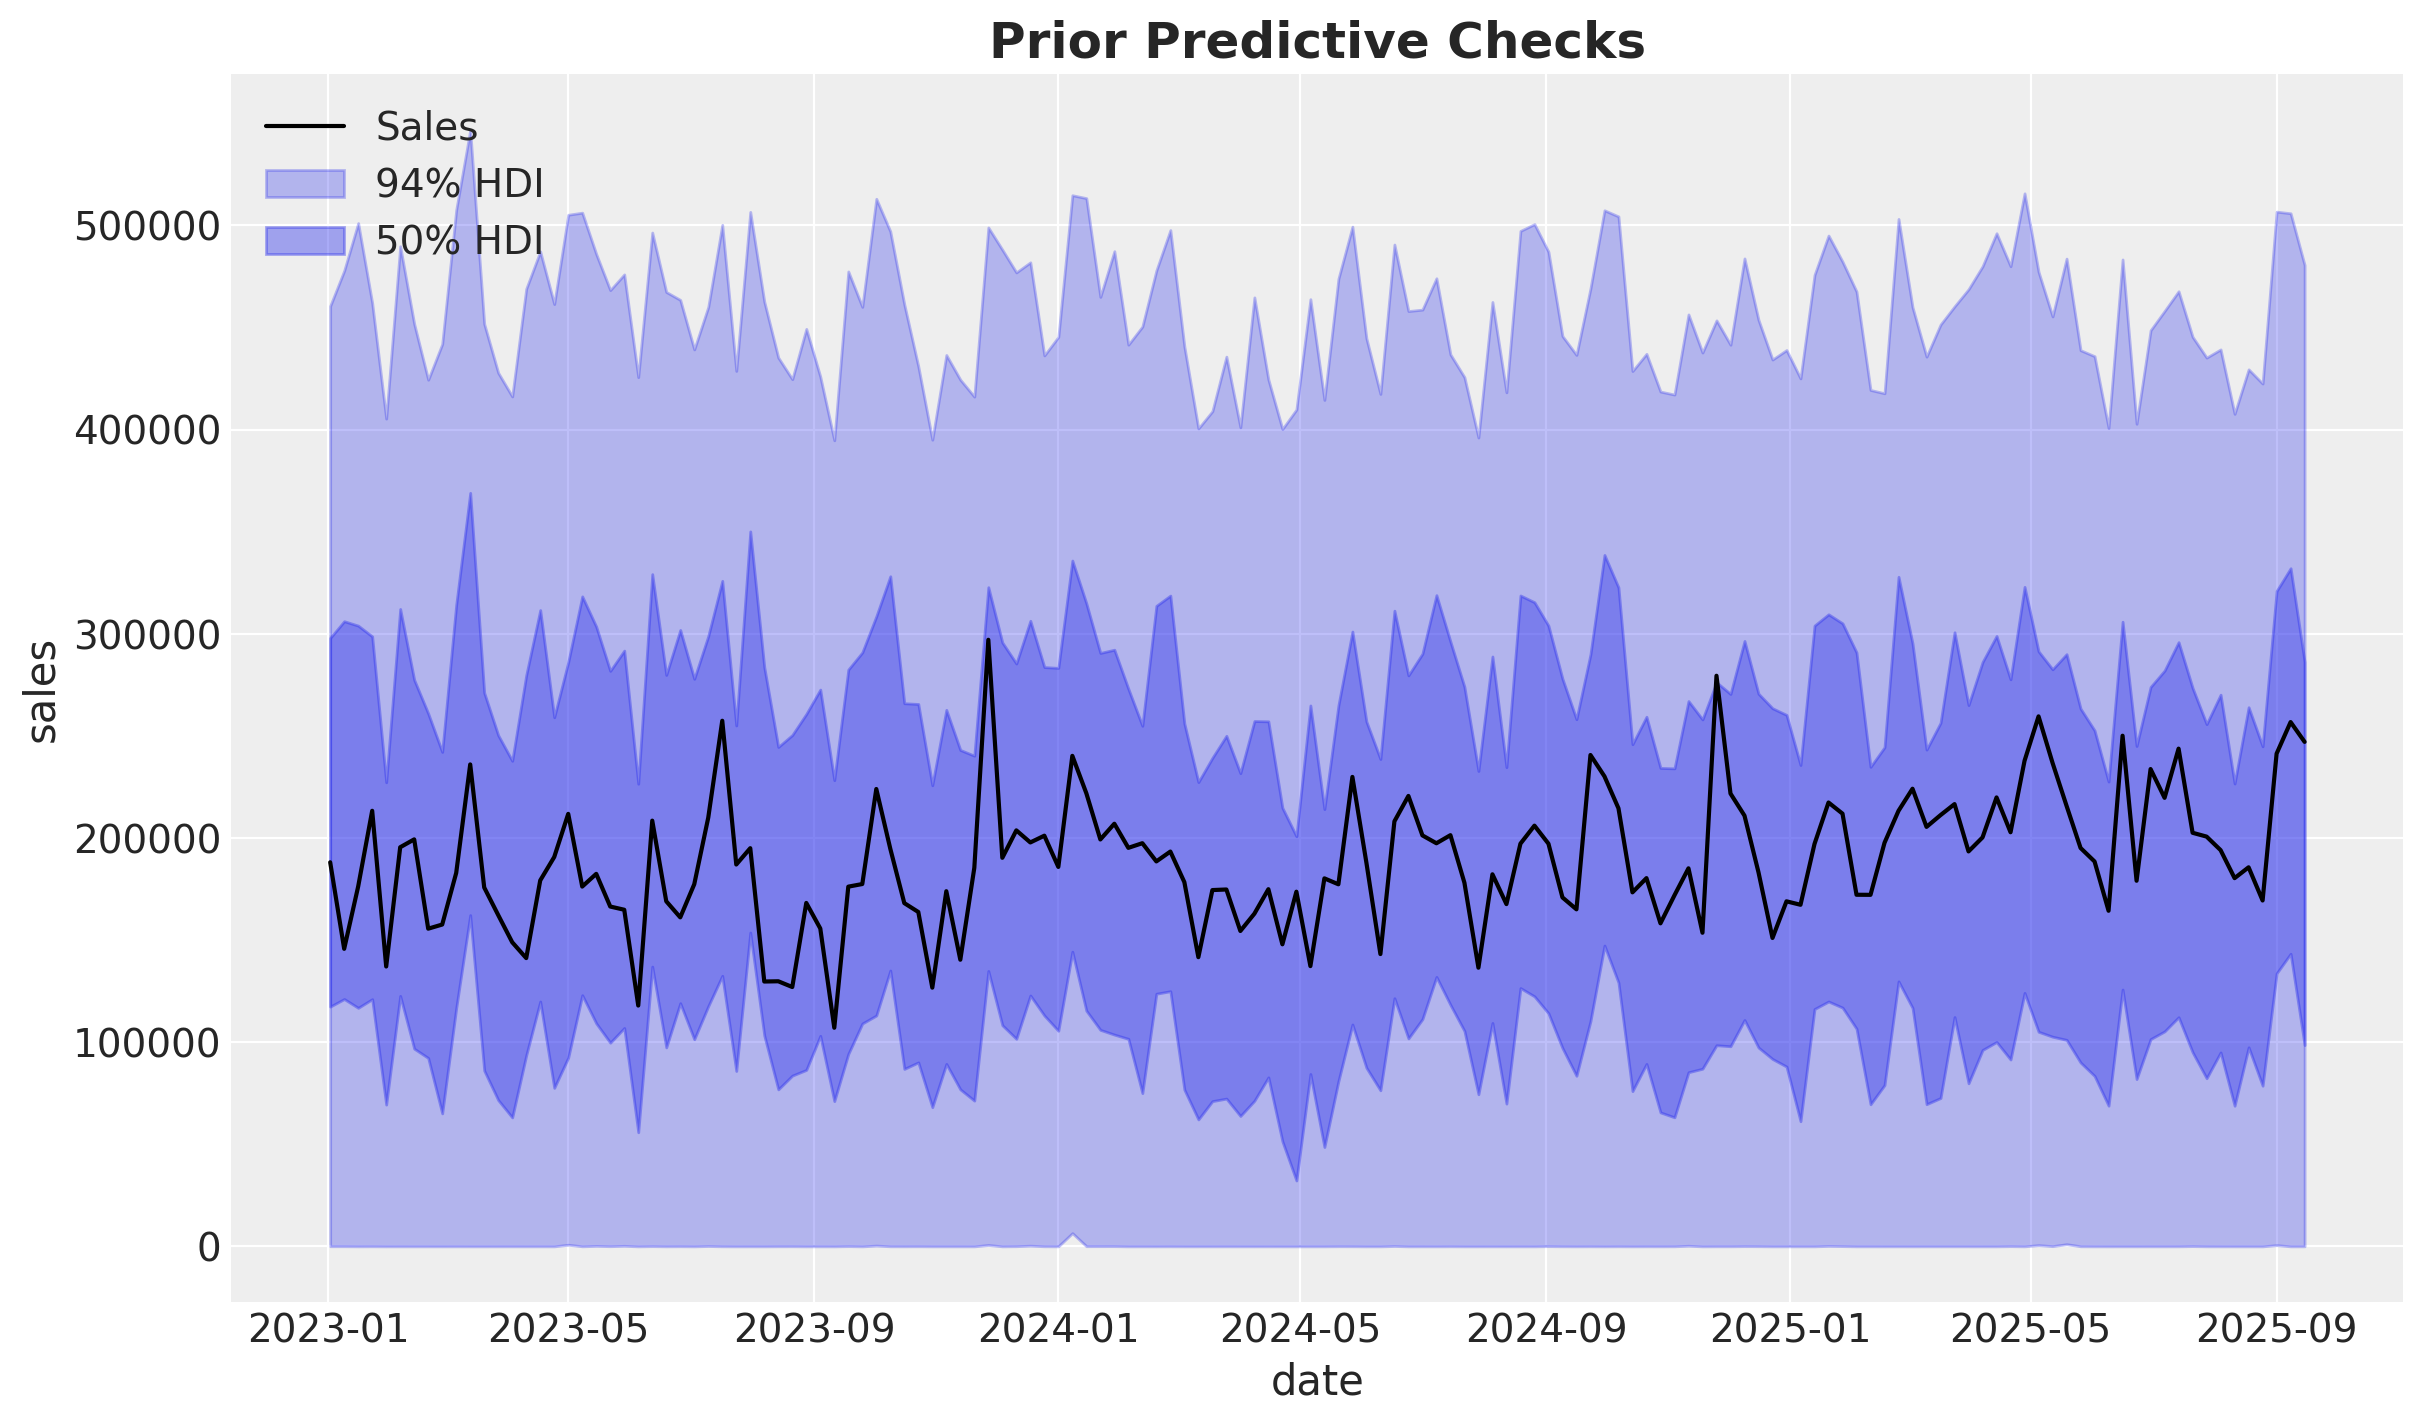

In [13]:
# Generate prior predictive samples
mmm.sample_prior_predictive(X_train, y_train, samples=4_000)

# Custom plot for demonstration
fig, ax = plt.subplots()
sns.lineplot(
    data=train_df, x="date", y="sales", color="black", label="Sales", ax=ax
)
for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        x=mmm.model.coords["date"],
        y=(mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date")),
        smooth=False,
        color="C0",
        hdi_prob=hdi_prob,
        fill_kwargs={"alpha": 0.3 + i * 0.1, "label": f"{hdi_prob:.0%} HDI"},
        ax=ax,
    )
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="sales")
ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold");

In [18]:
# 1. Statistical Summary
# ============================================================
print("="*60)
print("PRIOR PREDICTIVE STATISTICS")
print("="*60)

prior_samples = mmm.idata["prior"]["y_original_scale"]

# Overall statistics
print("\n📊 Prior Predictions Summary:")
print(f"  Min:      {prior_samples.min().values:>15,.0f}")
print(f"  5th %ile: {prior_samples.quantile(0.05).values:>15,.0f}")
print(f"  25th %ile:{prior_samples.quantile(0.25).values:>15,.0f}")
print(f"  Median:   {prior_samples.median().values:>15,.0f}")
print(f"  75th %ile:{prior_samples.quantile(0.75).values:>15,.0f}")
print(f"  95th %ile:{prior_samples.quantile(0.95).values:>15,.0f}")
print(f"  Max:      {prior_samples.max().values:>15,.0f}")
print(f"  Mean:     {prior_samples.mean().values:>15,.0f}")
print(f"  Std Dev:  {prior_samples.std().values:>15,.0f}")

print("\n📈 Actual Data Summary:")
print(f"  Min:      {train_df['sales'].min():>15,.0f}")
print(f"  25th %ile:{train_df['sales'].quantile(0.25):>15,.0f}")
print(f"  Median:   {train_df['sales'].median():>15,.0f}")
print(f"  75th %ile:{train_df['sales'].quantile(0.75):>15,.0f}")
print(f"  Max:      {train_df['sales'].max():>15,.0f}")
print(f"  Mean:     {train_df['sales'].mean():>15,.0f}")
print(f"  Std Dev:  {train_df['sales'].std():>15,.0f}")

PRIOR PREDICTIVE STATISTICS

📊 Prior Predictions Summary:
  Min:                    0
  5th %ile:          31,923
  25th %ile:        124,935
  Median:           212,309
  75th %ile:        313,115
  95th %ile:        476,933
  Max:            1,461,200
  Mean:             228,275
  Std Dev:          137,629

📈 Actual Data Summary:
  Min:              107,049
  25th %ile:        168,963
  Median:           187,422
  75th %ile:        208,379
  Max:              297,031
  Mean:             189,087
  Std Dev:           32,811


In [19]:
# 2. Coverage Check
# ============================================================
print("\n" + "="*60)
print("PRIOR COVERAGE ANALYSIS")
print("="*60)

# Check what percentage of actual data falls within prior HDI
prior_mean = prior_samples.mean(dim=["chain", "draw"])
prior_std = prior_samples.std(dim=["chain", "draw"])

# Calculate HDI bounds for each date
from scipy import stats
hdi_90_lower = prior_samples.quantile(0.05, dim=["chain", "draw"])
hdi_90_upper = prior_samples.quantile(0.95, dim=["chain", "draw"])

# Check coverage
within_90_hdi = ((train_df['sales'].values >= hdi_90_lower.values) & 
                 (train_df['sales'].values <= hdi_90_upper.values)).sum()
coverage_90 = (within_90_hdi / len(train_df)) * 100

print(f"\n✓ Actual data points within 90% HDI: {within_90_hdi}/{len(train_df)} ({coverage_90:.1f}%)")

if coverage_90 < 70:
    print("  ⚠️  WARNING: Low coverage - priors may be too restrictive")
elif coverage_90 > 95:
    print("  ℹ️  High coverage - priors may be too vague (this is okay for priors)")
else:
    print("  ✓ Good coverage for prior predictive check")


PRIOR COVERAGE ANALYSIS

✓ Actual data points within 90% HDI: 142/142 (100.0%)
  ℹ️  High coverage - priors may be too vague (this is okay for priors)


/var/folders/kl/t3xjjp5d4vnftjl0d8g0jmb00000gp/T/ipykernel_35025/2290392604.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Actual Data', 'Prior Predictions'],
/var/folders/kl/t3xjjp5d4vnftjl0d8g0jmb00000gp/T/ipykernel_35025/2290392604.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


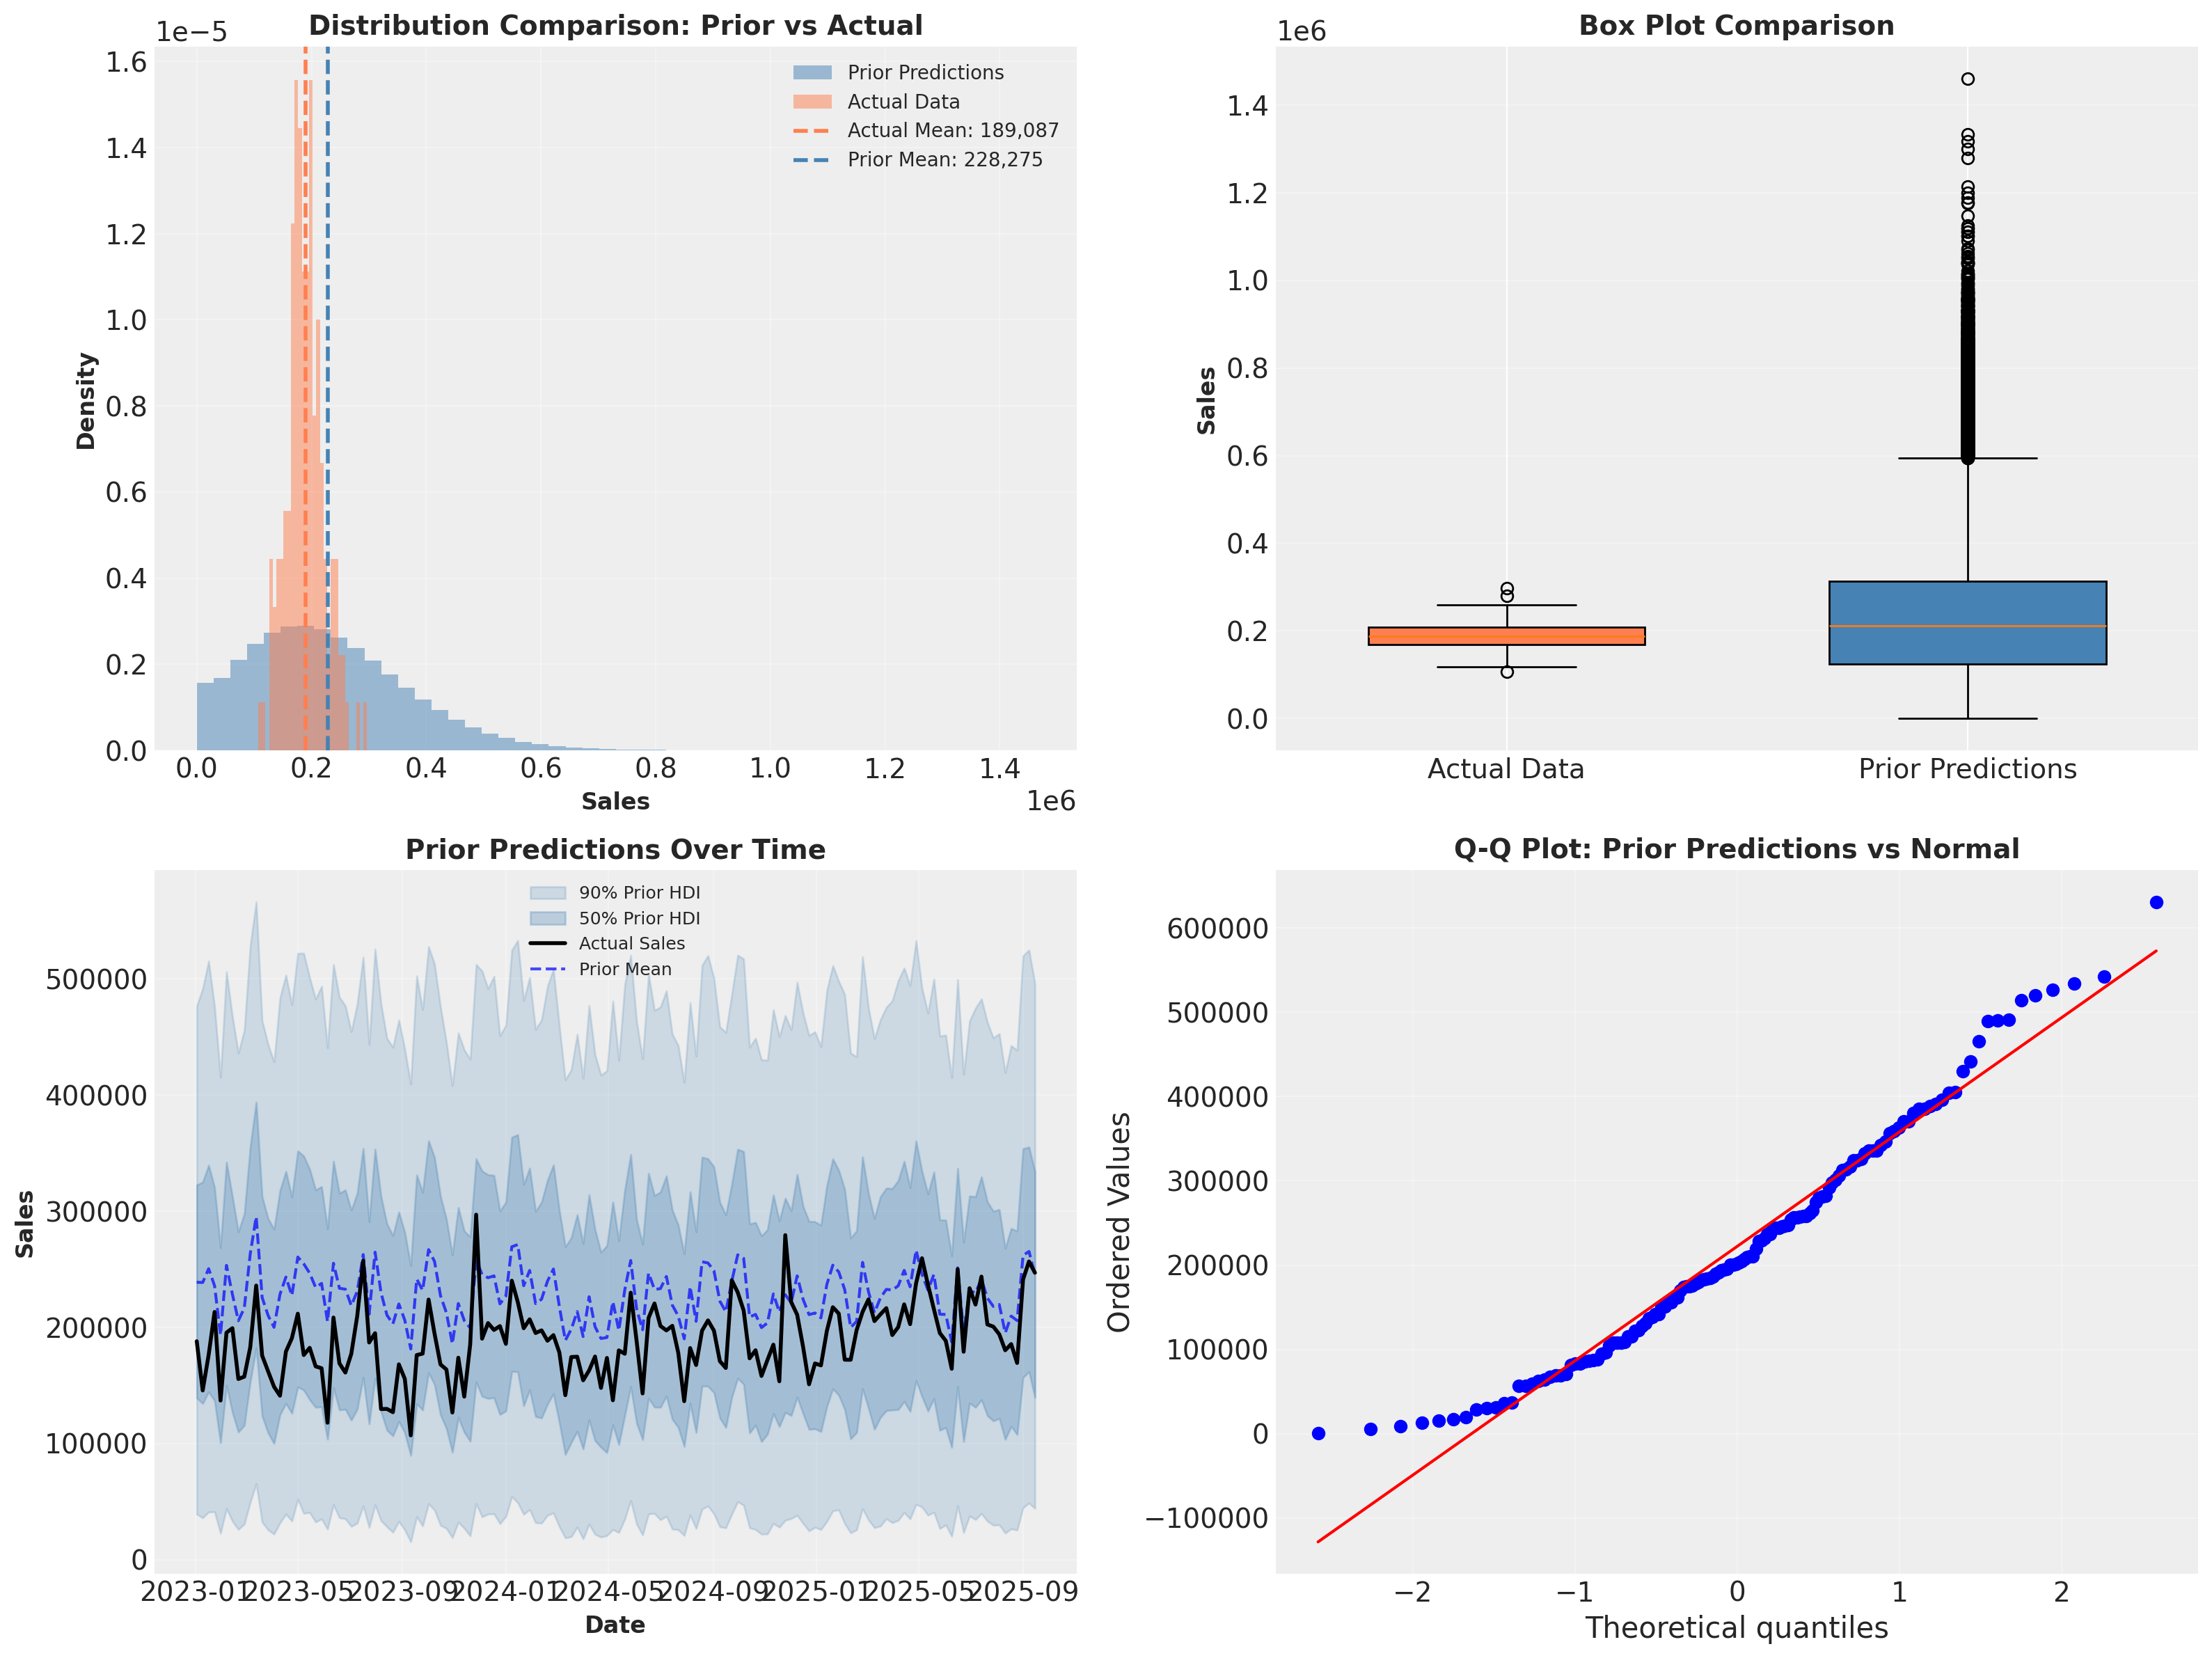

In [21]:
# 4. VISUALIZATION: Distribution Comparison
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Histogram comparison
ax = axes[0, 0]
ax.hist(prior_samples.values.flatten(), bins=50, alpha=0.5, 
        label='Prior Predictions', density=True, color='steelblue')
ax.hist(train_df['sales'].values, bins=30, alpha=0.5, 
        label='Actual Data', density=True, color='coral')
ax.axvline(train_df['sales'].mean(), color='coral', linestyle='--', 
           linewidth=2, label=f'Actual Mean: {train_df["sales"].mean():,.0f}')
ax.axvline(prior_samples.mean().values, color='steelblue', linestyle='--', 
           linewidth=2, label=f'Prior Mean: {prior_samples.mean().values:,.0f}')
ax.set_xlabel('Sales', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution Comparison: Prior vs Actual', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Plot 2: Box plot comparison
ax = axes[0, 1]
box_data = [train_df['sales'].values, prior_samples.values.flatten()]
bp = ax.boxplot(box_data, labels=['Actual Data', 'Prior Predictions'],
                patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
ax.set_ylabel('Sales', fontsize=12, fontweight='bold')
ax.set_title('Box Plot Comparison', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Plot 3: Time series with percentiles
ax = axes[1, 0]
dates = mmm.model.coords["date"]
ax.fill_between(dates, 
                prior_samples.quantile(0.05, dim=["chain", "draw"]),
                prior_samples.quantile(0.95, dim=["chain", "draw"]),
                alpha=0.2, color='steelblue', label='90% Prior HDI')
ax.fill_between(dates,
                prior_samples.quantile(0.25, dim=["chain", "draw"]),
                prior_samples.quantile(0.75, dim=["chain", "draw"]),
                alpha=0.3, color='steelblue', label='50% Prior HDI')
ax.plot(dates, train_df['sales'].values, color='black', linewidth=2, 
        label='Actual Sales', zorder=10)
ax.plot(dates, prior_mean.values, color='blue', linestyle='--',
        linewidth=1.5, alpha=0.7, label='Prior Mean')
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales', fontsize=12, fontweight='bold')
ax.set_title('Prior Predictions Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Q-Q plot
ax = axes[1, 1]
from scipy import stats as sp_stats
# Sample from prior for Q-Q plot (use a subset to avoid overplotting)
prior_sample_subset = np.random.choice(
    prior_samples.values.flatten(), 
    size=min(5000, len(train_df)), 
    replace=False
)
sp_stats.probplot(prior_sample_subset, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Prior Predictions vs Normal', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
sum_contributions = mmm.idata["prior"]["channel_contribution"].sum(dim="date")
share_contributions = sum_contributions / sum_contributions.sum(dim="channel")

fig, ax = plt.subplots(figsize=(10, 6))
az.plot_forest(share_contributions, combined=True, ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
fig.suptitle("Prior Channel Contribution Share", fontsize=18, fontweight="bold");

## Model Fitting

In [ ]:

print("Starting MCMC sampling...")

# Define rng for reproducibility
rng = np.random.default_rng(123)

mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    target_accept=0.95,
    random_seed=rng,
)

print("MCMC sampling complete.")

mmm.sample_posterior_predictive(X=X_train, random_seed=rng)



In [ ]:
# Number of diverging samples
mmm.idata["sample_stats"]["diverging"].sum().item()

## Posterior Predictive diagnostics

Text(0.5, 1.0, 'Posterior Predictive with Actual Sales and 90% HDI')

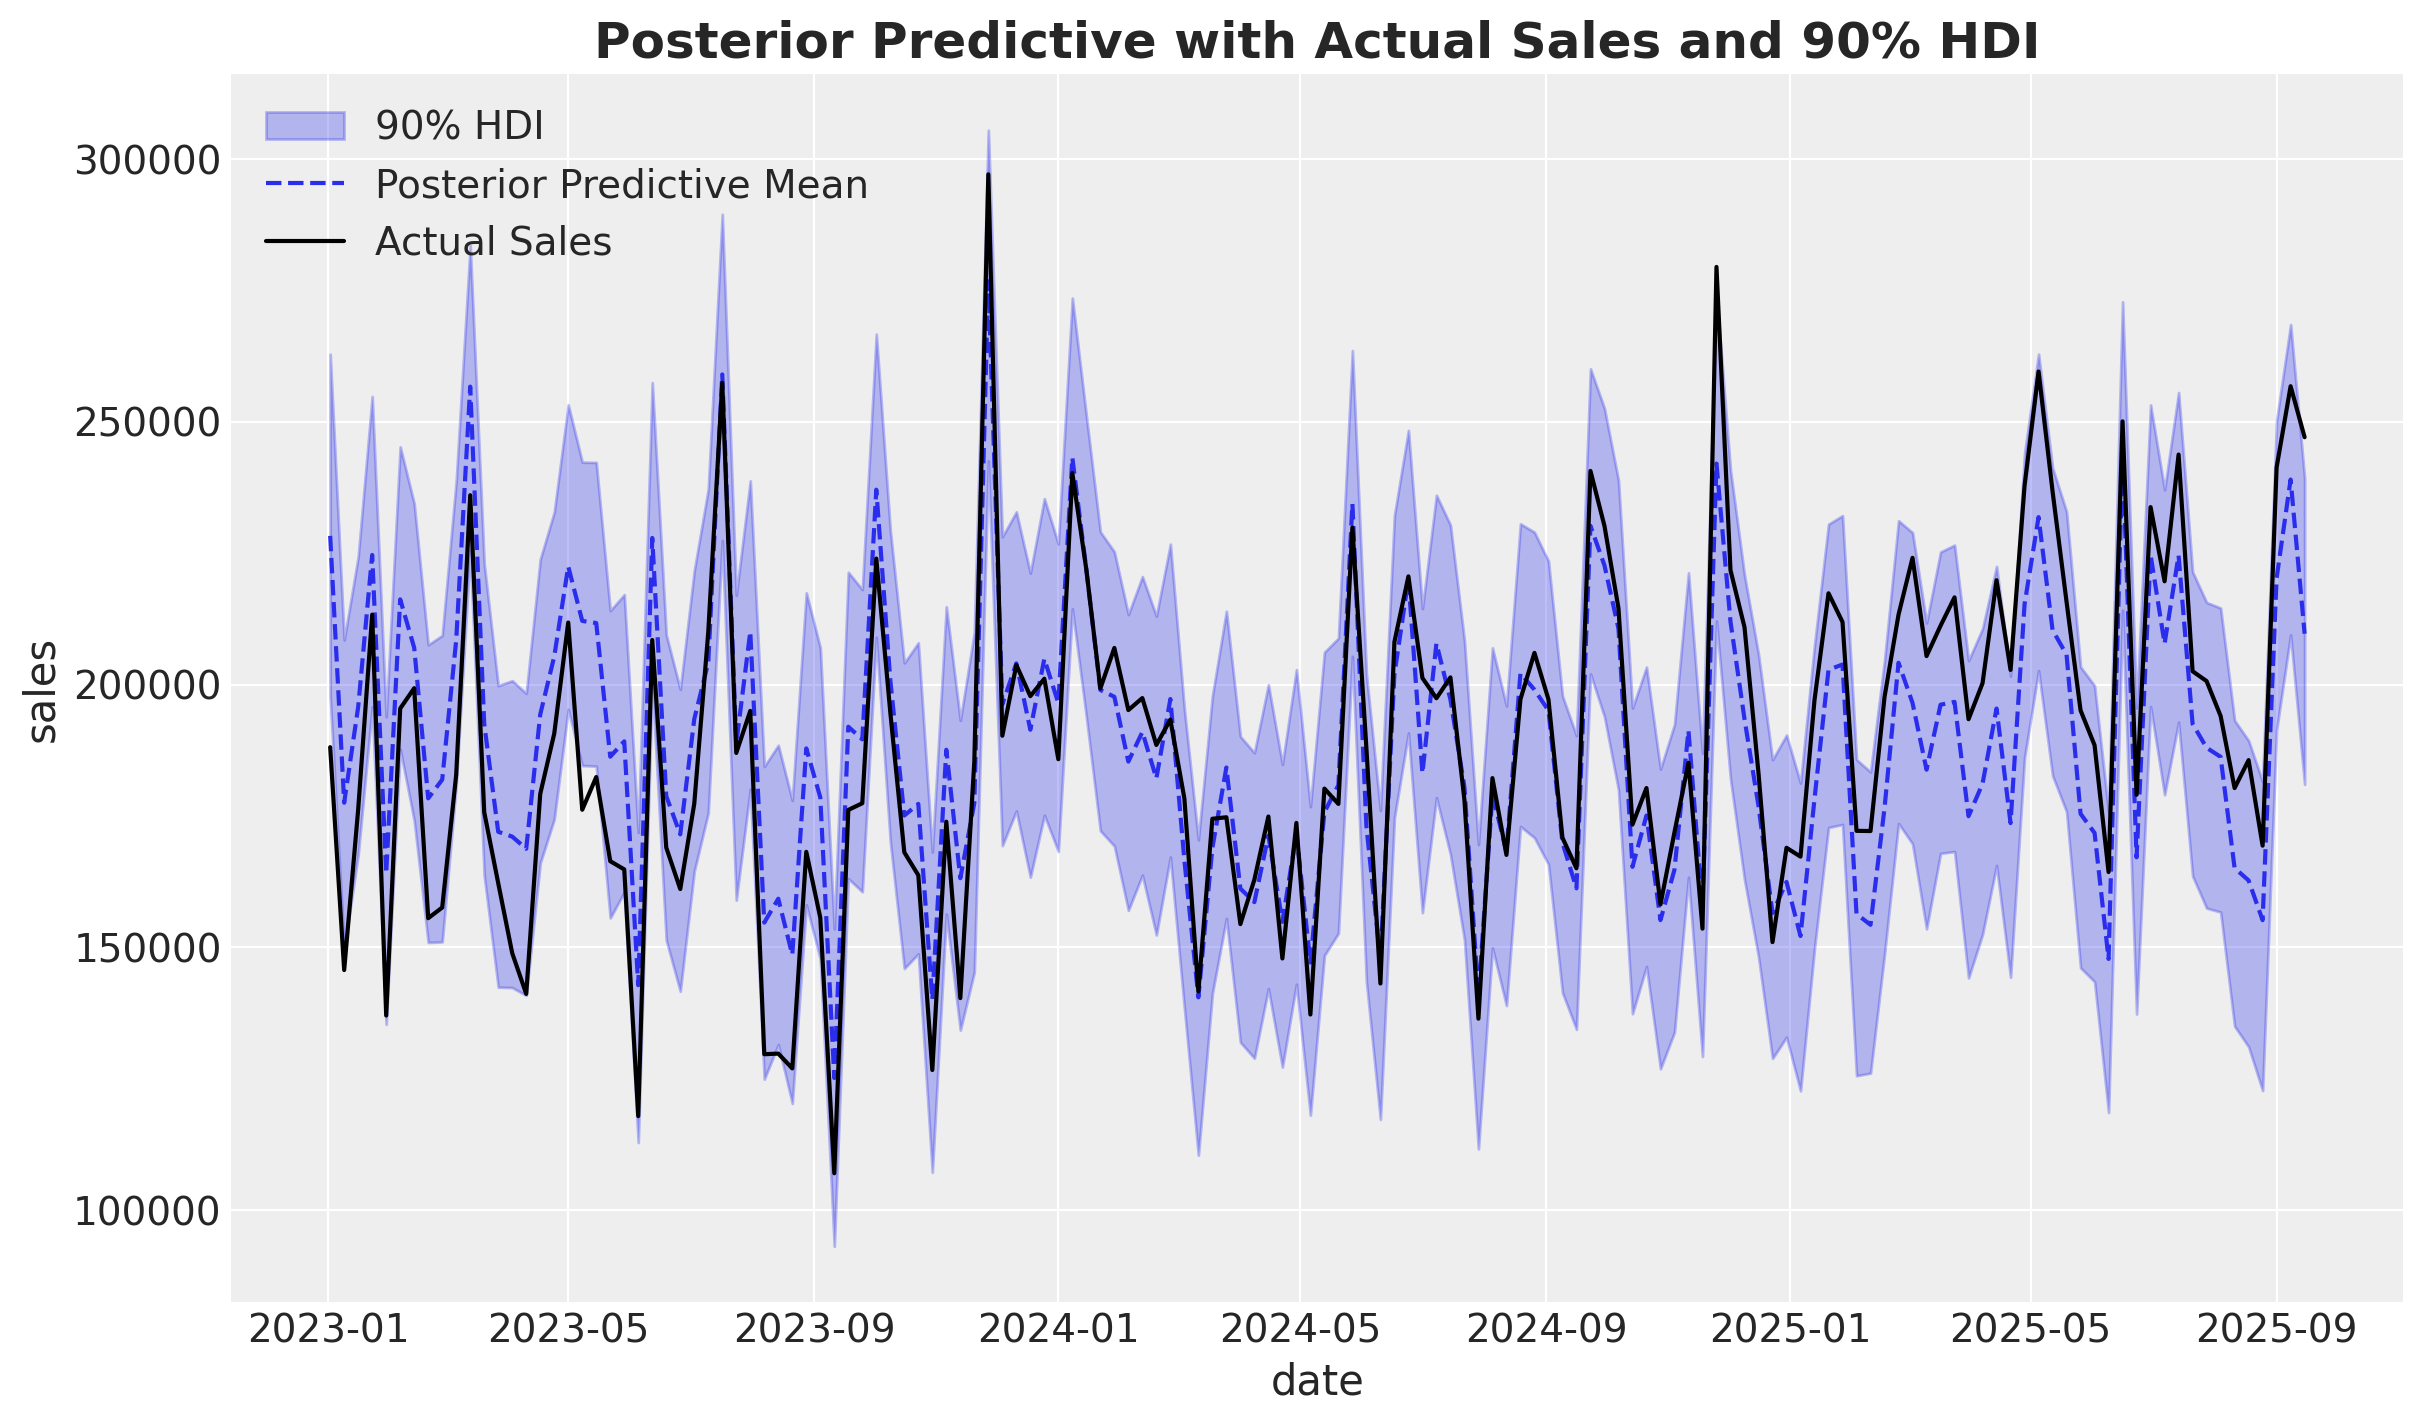

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot 90% HDI for posterior predictive
az.plot_hdi(
    x=mmm.model.coords["date"],
    y=mmm.idata["posterior_predictive"]["y_original_scale"],
    color="C0",
    smooth=False,
    hdi_prob=0.9,
    fill_kwargs={"alpha": 0.3, "label": "90% HDI"},
    ax=ax,
)

# Plot posterior predictive mean
posterior_pred_mean = mmm.idata["posterior_predictive"]["y_original_scale"].mean(dim=("chain", "draw")).values
ax.plot(mmm.model.coords["date"], posterior_pred_mean, color="C0", linestyle="--", label="Posterior Predictive Mean")

# Plot actual sales
sns.lineplot(data=train_df, x="date", y="sales", color="black", label="Actual Sales", ax=ax)

ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="sales")
ax.set_title("Posterior Predictive with Actual Sales and 90% HDI", fontsize=18, fontweight="bold")

In [37]:
mmm.plot_interactive.posterior_predictive()

## Model Evaluation

In [49]:
from pymc_marketing.mmm.evaluation import (
    calculate_metric_distributions,
    compute_summary_metrics,
    summarize_metric_distributions,
)


Failed to reload module 'cutils_ext' from file '/Users/Office/.pytensor/compiledir_macOS-26.3.1-x86_64-i386-64bit-i386-3.12.11-64/cutils_ext/__init__.py'
Traceback (most recent call last):
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/pymc-marketing-new/lib/python3.12/importlib/__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)


In [51]:
posterior_preds=mmm.sample_posterior_predictive(X=X_train, random_seed=rng)

Sampling: [y]


Output()

In [31]:
# Calculate metrics for all posterior samples
results = compute_summary_metrics(
    y_true=y_train,
    y_pred=posterior_preds.y_original_scale.to_numpy(),
    metrics_to_calculate=[
        "r_squared",
        "rmse",
        "nrmse",
        "mae",
        "nmae",
        "mape",
    ],
    hdi_prob=hdi_prob,
)

# Print results in a formatted way
for metric, stats in results.items():
    print(f"\n{metric.upper()}:")
    for stat, value in stats.items():
        print(f"  {stat}: {value:.4f}")


R_SQUARED:
  mean: 0.6464
  median: 0.6485
  std: 0.0345
  min: 0.5081
  max: 0.7535
  50%_hdi_lower: 0.6276
  50%_hdi_upper: 0.6735

RMSE:
  mean: 23898.5306
  median: 23815.1120
  std: 1570.0901
  min: 19139.7796
  max: 29674.1081
  50%_hdi_lower: 22751.1674
  50%_hdi_upper: 24843.4032

NRMSE:
  mean: 0.1258
  median: 0.1254
  std: 0.0083
  min: 0.1007
  max: 0.1562
  50%_hdi_lower: 0.1198
  50%_hdi_upper: 0.1308

MAE:
  mean: 19196.5903
  median: 19129.9266
  std: 1321.8973
  min: 14649.2092
  max: 24267.4425
  50%_hdi_lower: 18006.6141
  50%_hdi_upper: 19741.6146

NMAE:
  mean: 0.1010
  median: 0.1007
  std: 0.0070
  min: 0.0771
  max: 0.1277
  50%_hdi_lower: 0.0948
  50%_hdi_upper: 0.1039

MAPE:
  mean: 0.1049
  median: 0.1046
  std: 0.0073
  min: 0.0795
  max: 0.1322
  50%_hdi_lower: 0.0988
  50%_hdi_upper: 0.1085


In [52]:
# Calculate distributions for multiple metrics
metric_distributions = calculate_metric_distributions(
    y_true=mmm.y,
    y_pred=posterior_preds.y_original_scale.to_numpy(),
    metrics_to_calculate=["r_squared", "mape"],
)

# Summarize the distributions
summaries = summarize_metric_distributions(metric_distributions, hdi_prob=0.89)

# Create a nice display of the summaries
for metric, summary in summaries.items():
    print(f"\n{metric.upper()} Summary:")
    print(f"  Mean: {summary['mean']:.4f}")
    print(f"  Median: {summary['median']:.4f}")
    print(f"  Standard Deviation: {summary['std']:.4f}")
    print(
        f"  89% HDI: [{summary['89%_hdi_lower']:.4f}, {summary['89%_hdi_upper']:.4f}]"
    )


R_SQUARED Summary:
  Mean: 0.6451
  Median: 0.6475
  Standard Deviation: 0.0351
  89% HDI: [0.5895, 0.7005]

MAPE Summary:
  Mean: 0.1052
  Median: 0.1048
  Standard Deviation: 0.0075
  89% HDI: [0.0930, 0.1165]


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]
/Users/Office/.local/lib/python3.12/site-packages/pymc_marketing/mmm/plot.py:1962: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/Office/.local/lib/python3.12/site-packages/pymc_marketing/mmm/plot.py:1962: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


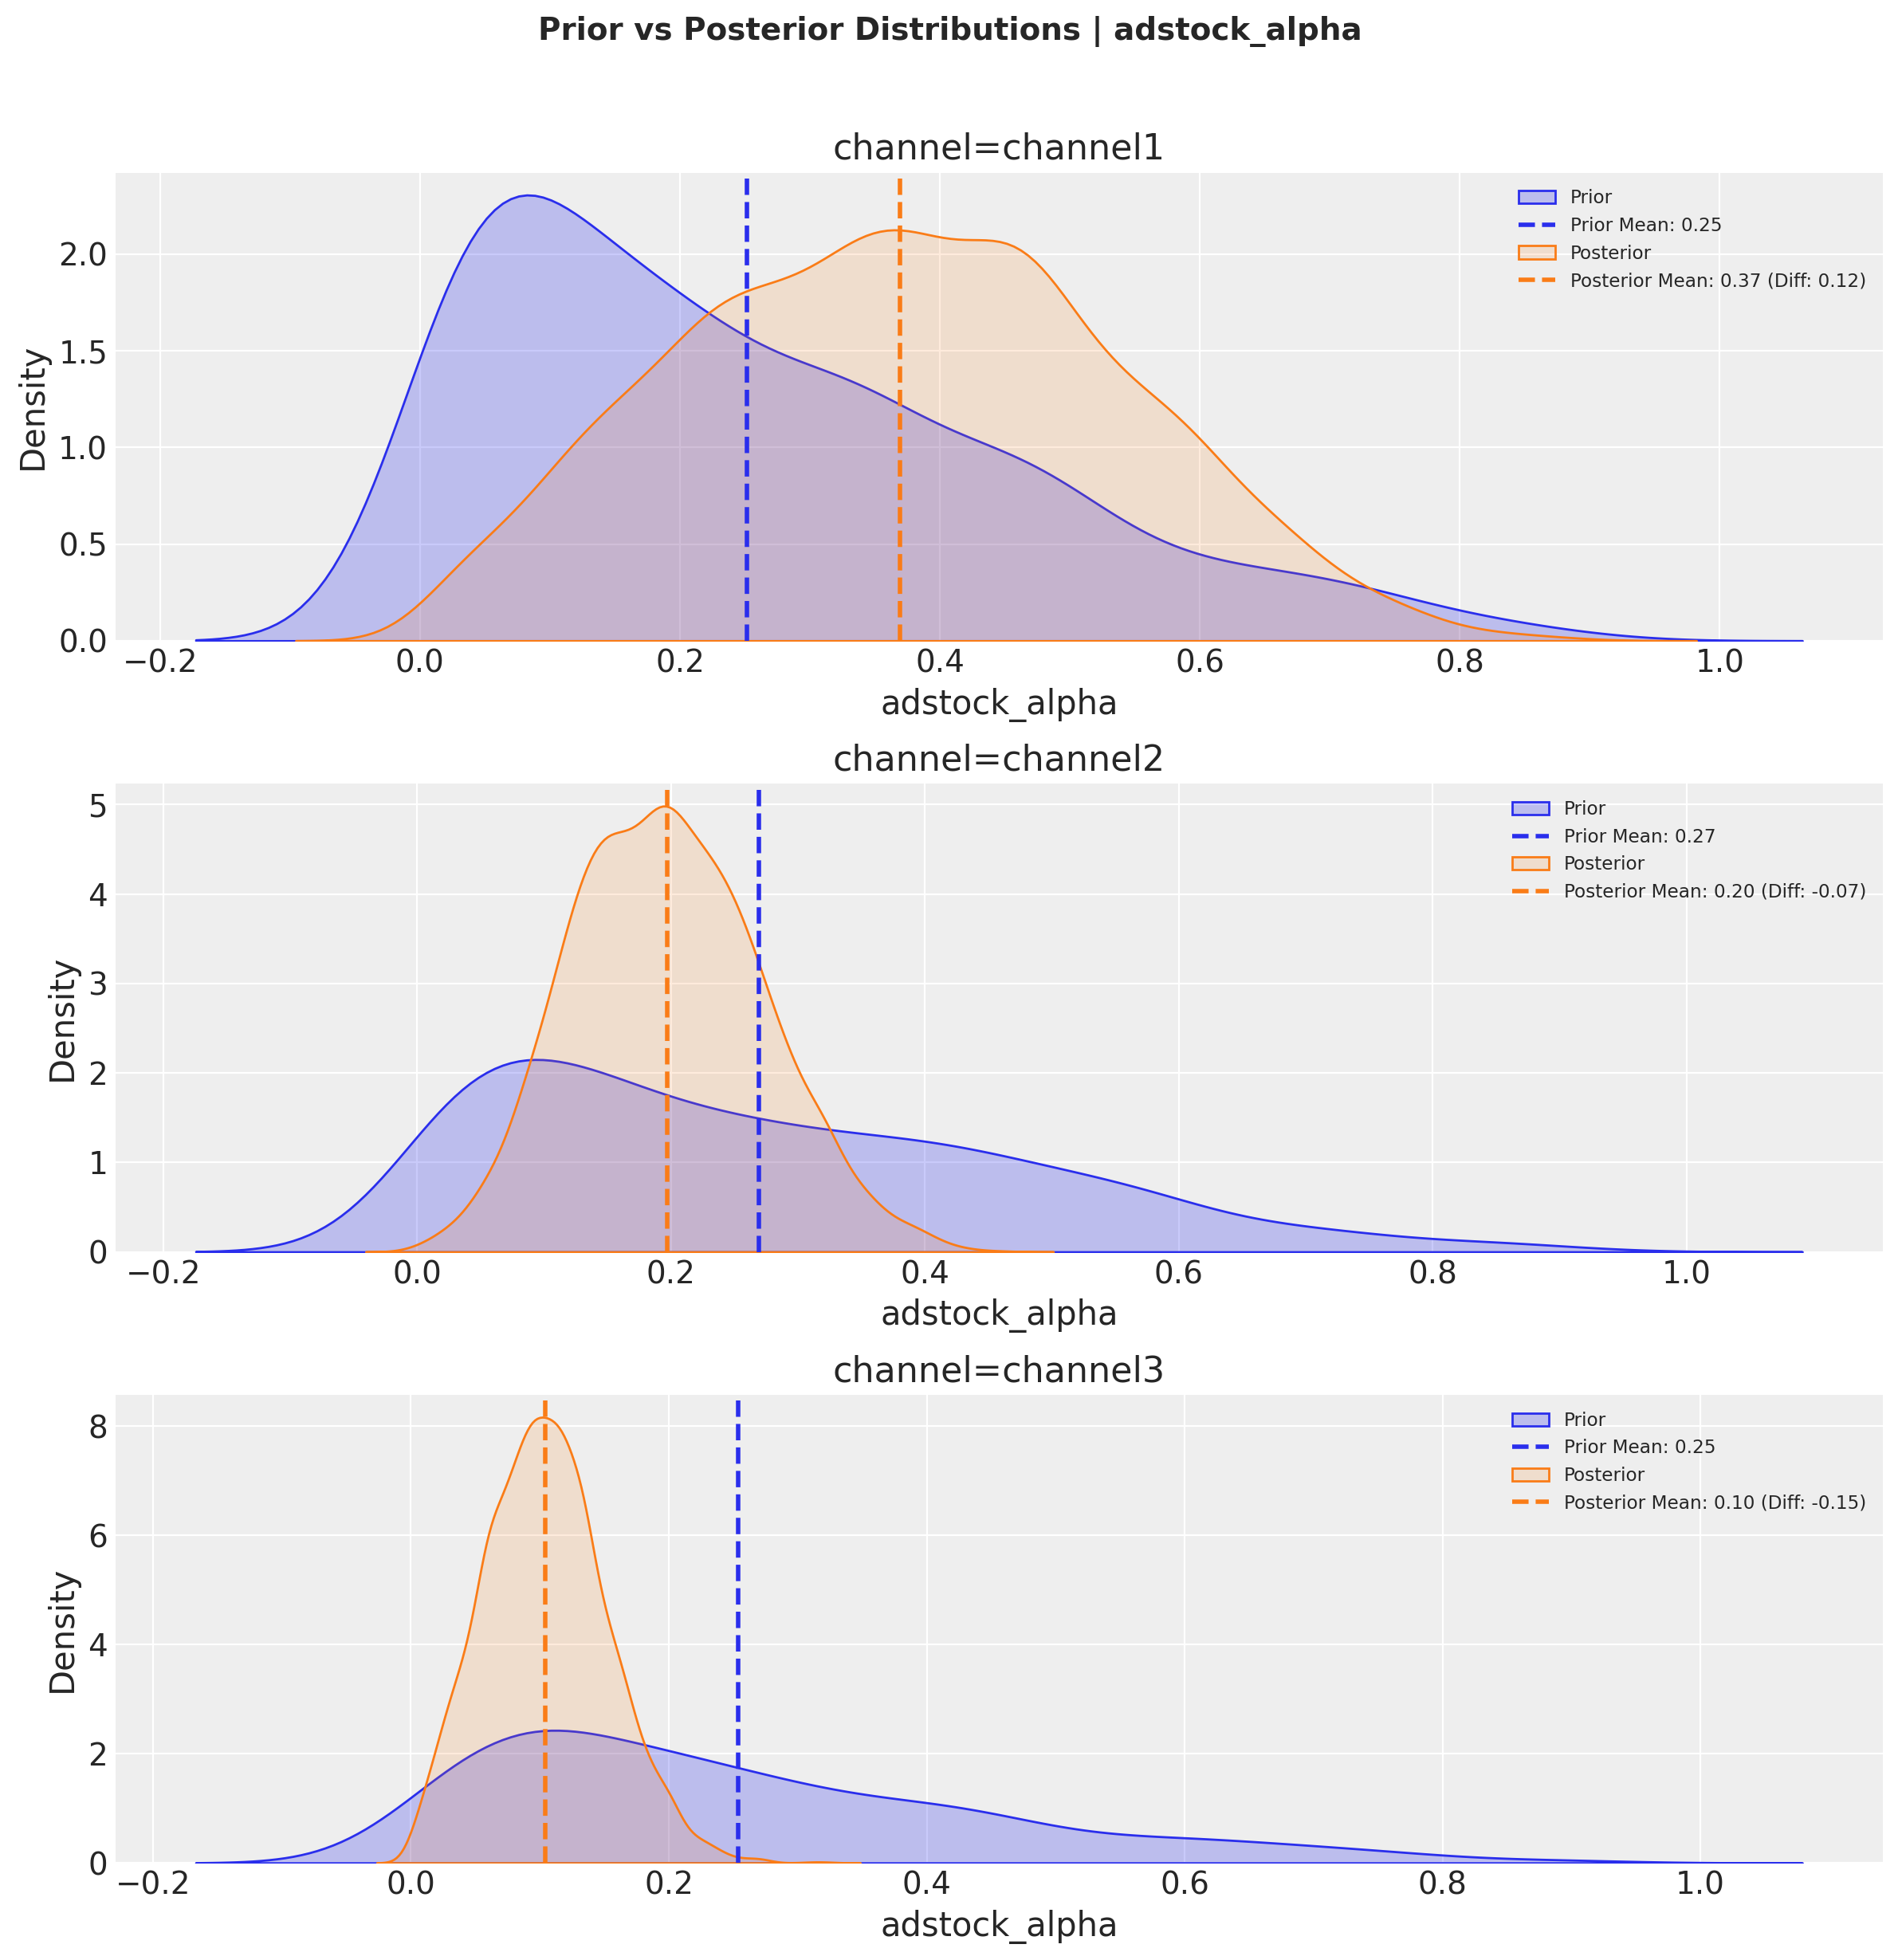

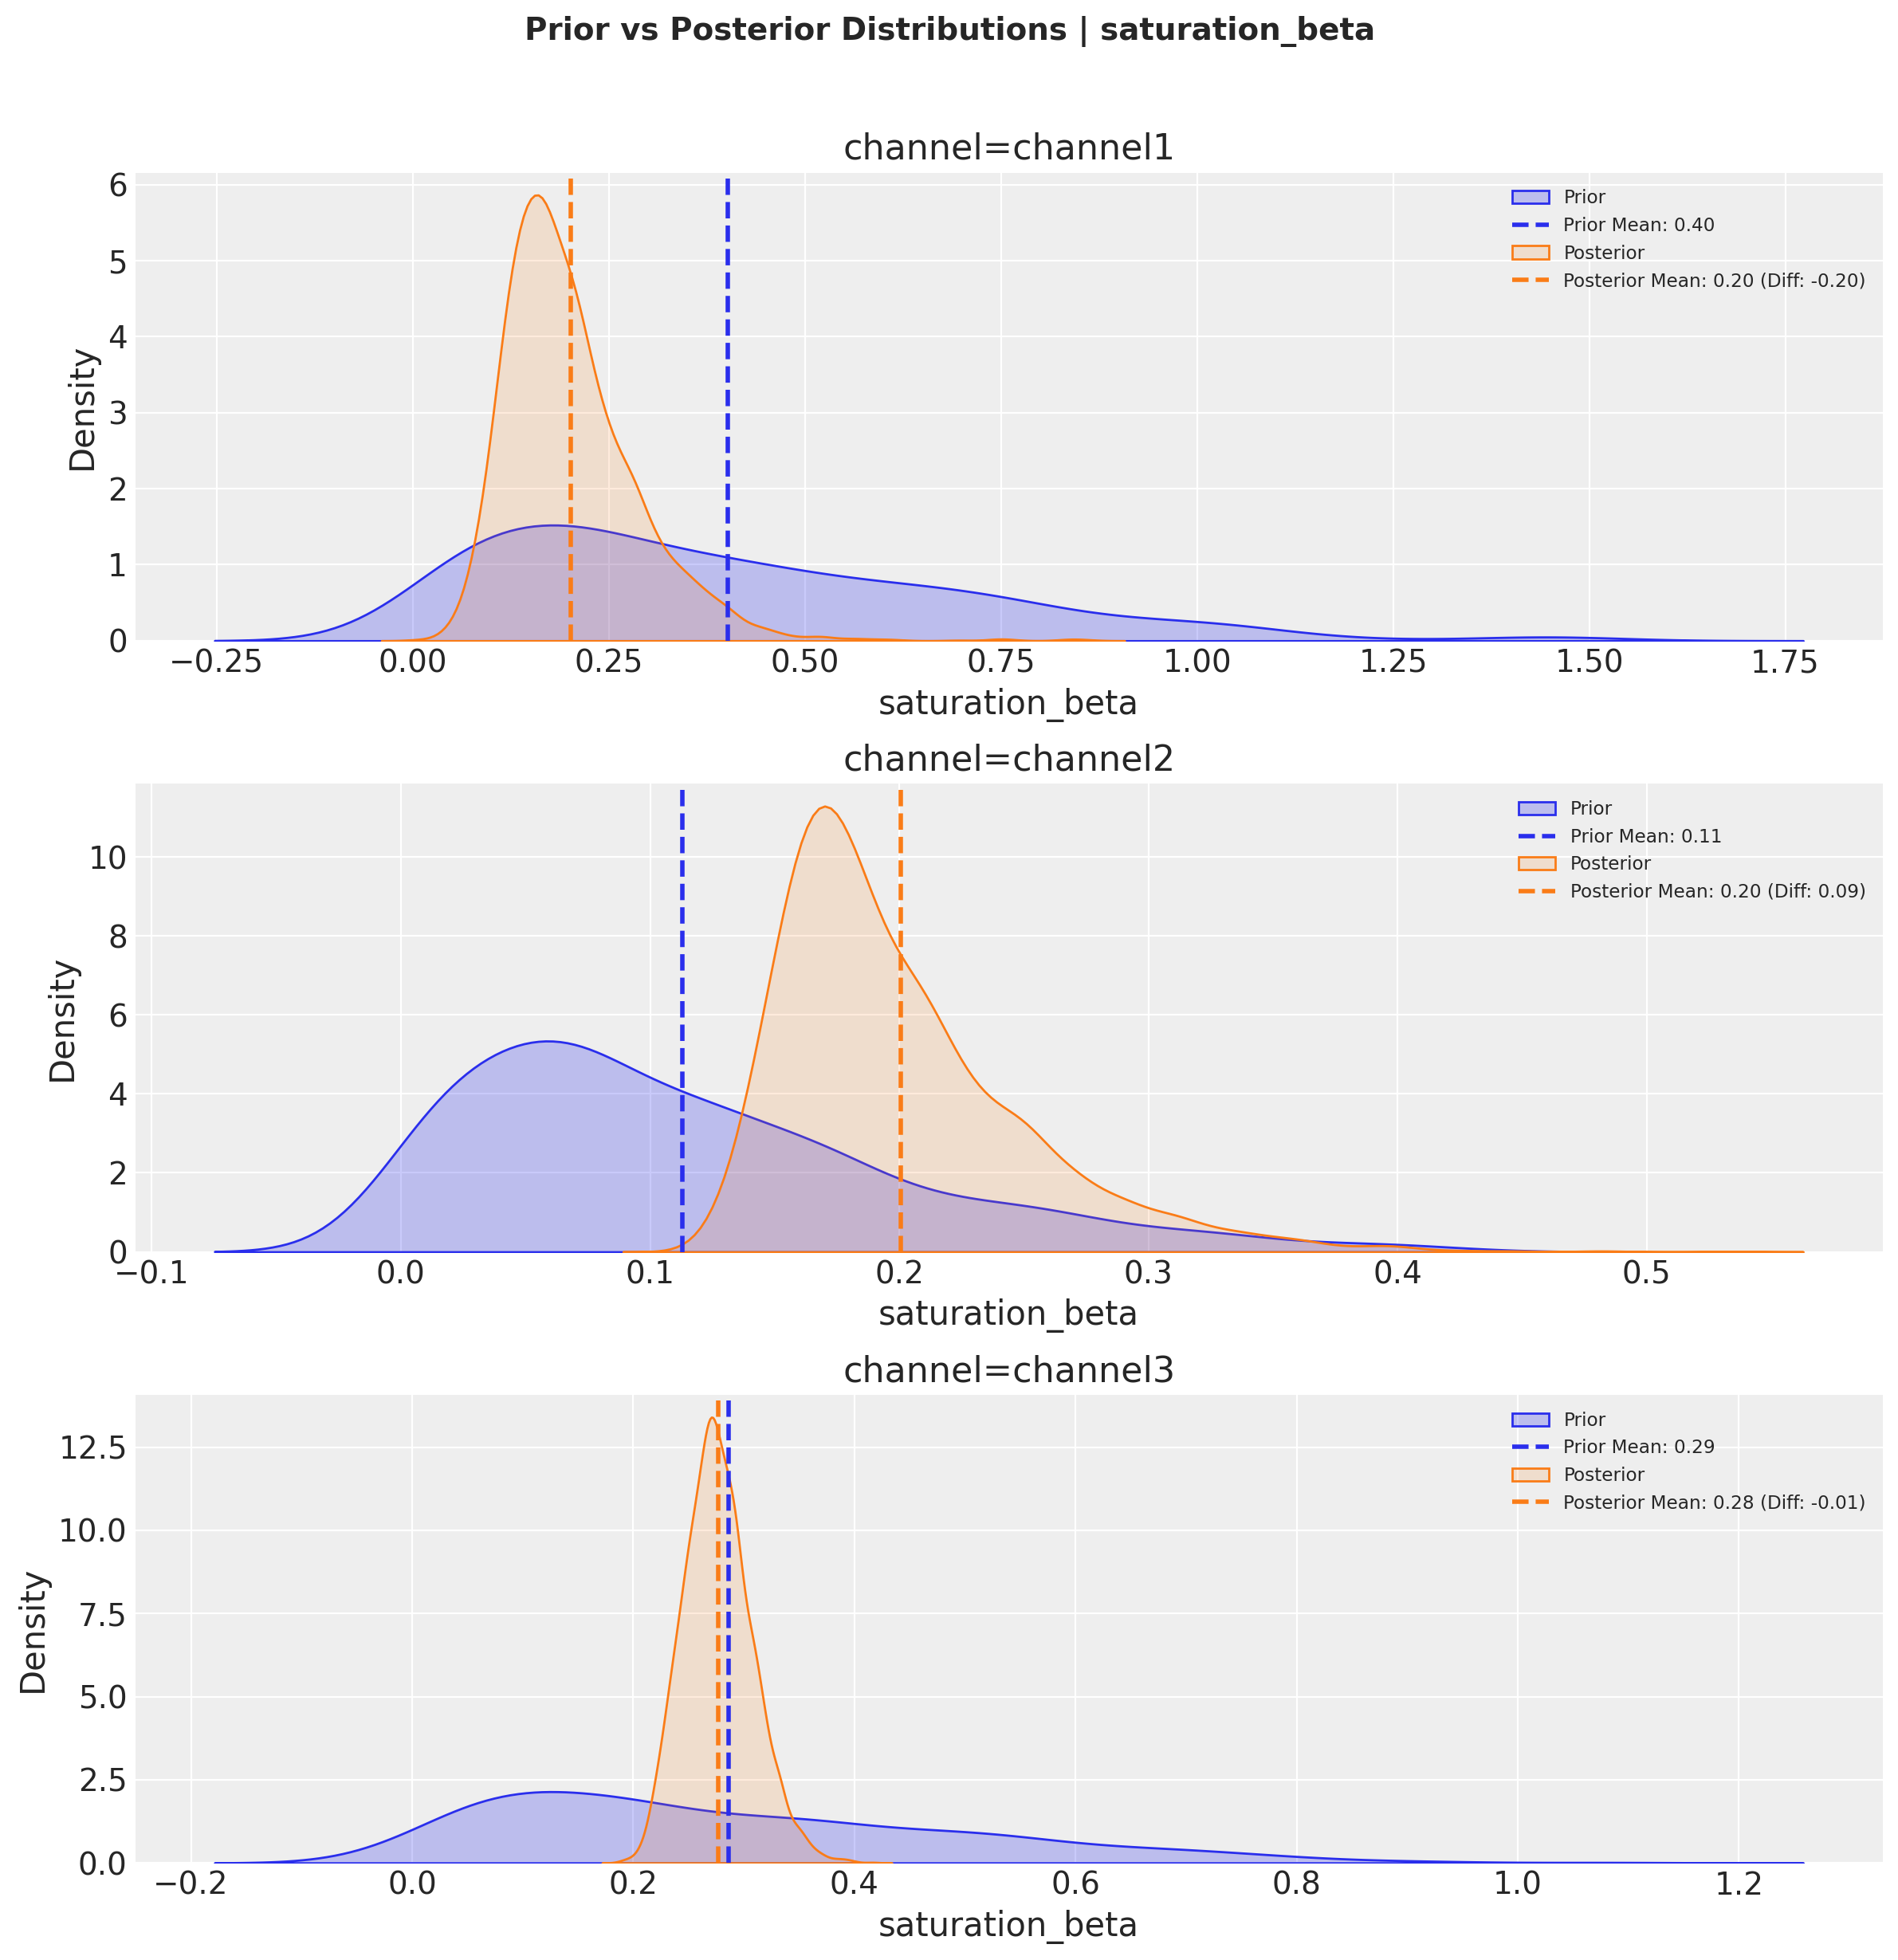

In [49]:
# First, sample from the prior
prior_preds = mmm.sample_prior_predictive(X_train, random_seed=rng)

# Plot prior vs posterior for adstock parameter
fig, axes = mmm.plot.prior_vs_posterior(
    var="adstock_alpha",
    alphabetical_sort=True,  # Sort channels alphabetically
)

# Plot prior vs posterior for saturation parameter
fig, axes = mmm.plot.prior_vs_posterior(
    var="saturation_beta",
    alphabetical_sort=True,  # Sort channels alphabetically
)

## Cross validation

In [ ]:
from pymc_marketing.mmm.time_slice_cross_validation import TimeSliceCrossValidator

# Time Slice Cross-Validation Setup
# Optimized for complete temporal coverage with 157 weeks of data:
# - n_init=78 (~1.5 years initial training - same as before)
# - forecast_horizon=13 (~3 months test periods)
# - step_size=13 (equals forecast_horizon - no gaps, complete coverage!)
# - This gives 6 folds (one more than original) but uses full dataset with no gaps

cv = TimeSliceCrossValidator(
    n_init=140,              # Initial training observations (~1.5 years)
    forecast_horizon=13,    # Weeks to forecast ahead in each fold (~3 months)
    step_size=1,           # Move forward by one forecast period (complete coverage!)
    date_column="date",     # Name of the date column in your data
)

# Show the configuration
print(f"Cross-validation configuration:")
print(f"  Total data: 157 weeks (~3 years)")
print(f"  Initial training size: 78 weeks (~1.5 years)")
print(f"  Forecast horizon: 13 weeks (~3 months)")
print(f"  Step size: 13 weeks (= forecast_horizon, no gaps!)")
print(f"  Expected number of folds: 6 (uses complete dataset)")

Cross-validation configuration:
  Total data: 157 weeks (~3 years)
  Initial training size: 78 weeks (~1.5 years)
  Forecast horizon: 13 weeks (~3 months)
  Step size: 13 weeks (= forecast_horizon, no gaps!)
  Expected number of folds: 6 (uses complete dataset)


In [ ]:
X=df.drop(columns="sales")
y=df["sales"].rename('y')

In [ ]:
# Check how many folds will be created
n_splits = cv.get_n_splits(X, y)
print(f"Number of CV folds: {n_splits}")
print(f"\n⚠️  The model will be trained {n_splits} times (once per fold)")
print(f"    Each training run will take several minutes depending on your hardware")
print(f"    Total CV time estimate: {n_splits} × training time per fold")

Number of CV folds: 5

⚠️  The model will be trained 5 times (once per fold)
    Each training run will take several minutes depending on your hardware
    Total CV time estimate: 5 × training time per fold


In [ ]:
my_sampler_config = {
    "progressbar": True,
    "target_accept": 0.985,  # High target_accept to reduce divergences
    "chains": 4,
}

In [ ]:
# IMPORTANT: Do NOT use the saved/already-trained model for cross-validation!
# The cv.run() method needs a FRESH, unfitted model configuration.
# It will train the model multiple times on different data splits.

# Create a fresh model configuration (same structure as before, but unfitted)
# The sampler_config includes target_accept=0.95 and chains=4 to reduce divergences
mmm_for_cv = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=10),
    saturation=LogisticSaturation(),
    time_varying_intercept=False,
    yearly_seasonality=2,
    model_config=my_model_config,
    sampler_config=my_sampler_config,  # Includes target_accept=0.95, chains=4
)

# Run cross-validation with the FULL dataset (not just X_train, y_train)
# The cv.run() method will automatically handle the train/test splits
print("Starting cross-validation...")
print("This will train the model multiple times, so it may take a while...")
cv_results = cv.run(X, y, mmm=mmm_for_cv, original_scale_vars=['y'])

print("\nCross-validation complete!")

In [ ]:
# Check divergences across all CV folds
print("="*70)
print("DIVERGENCES PER CV FOLD")
print("="*70)

# Get the number of folds - try different possible locations
if hasattr(cv_results.sample_stats, 'fold'):
    n_folds = len(cv_results.sample_stats.fold)
elif 'fold' in cv_results.sample_stats.coords:
    n_folds = len(cv_results.sample_stats.coords['fold'])
else:
    # If fold is a dimension in the diverging array itself
    n_folds = cv_results.sample_stats["diverging"].sizes.get('fold', 1)

print(f"Number of folds: {n_folds}\n")

for fold_idx in range(n_folds):
    fold_data = cv_results.sel(fold=fold_idx)
    n_divergences = fold_data["sample_stats"]["diverging"].sum().item()
    print(f"Fold {fold_idx + 1}: {n_divergences} divergences")
    
total_divergences = cv_results["sample_stats"]["diverging"].sum().item()
print(f"\nTotal divergences across all folds: {total_divergences}")
print("="*70)

if total_divergences == 0:
    print("✓ No divergences! Parameter estimates should be stable.")
elif total_divergences < 10:
    print("⚠️  Few divergences - parameter stability should be acceptable.")
else:
    print("❌ Many divergences - this will cause parameter instability!")
    print("   → Increase target_accept further (try 0.99)")
    print("   → Or use stronger priors (e.g., Beta(3,3) for adstock_alpha)")

Failed to reload module 'cutils_ext' from file '/Users/Office/.pytensor/compiledir_macOS-26.3.1-x86_64-i386-64bit-i386-3.12.11-64/cutils_ext/__init__.py'
Traceback (most recent call last):
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/pymc-marketing-new/lib/python3.12/importlib/__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "/Users/Office/.local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)


DIVERGENCES PER CV FOLD
Number of folds: 1

Fold 1: 0 divergences

Total divergences across all folds: 0
✓ No divergences! Parameter estimates should be stable.


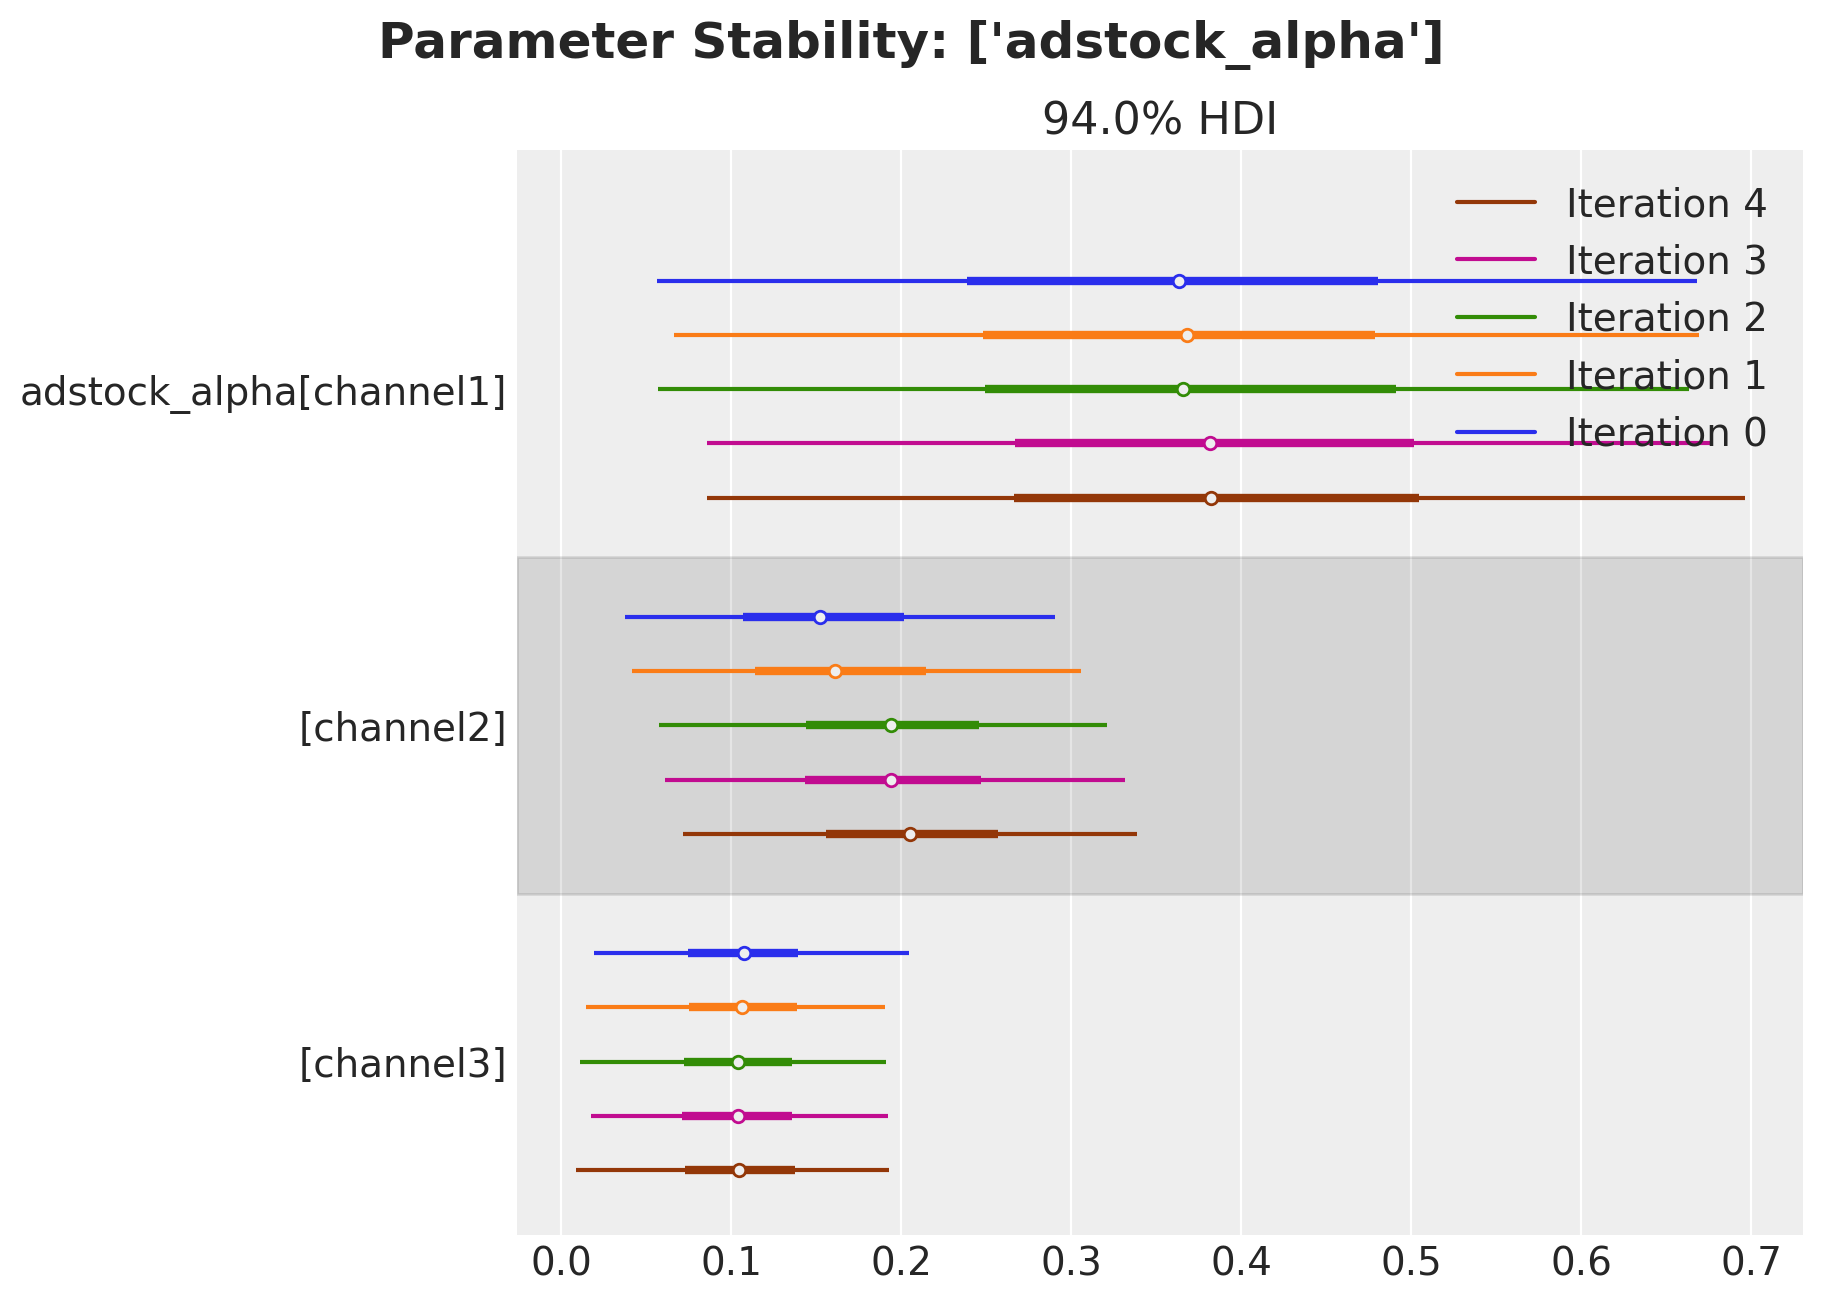

In [ ]:
cv.plot.param_stability(
    results=cv_results,
    parameter=["adstock_alpha"]
);

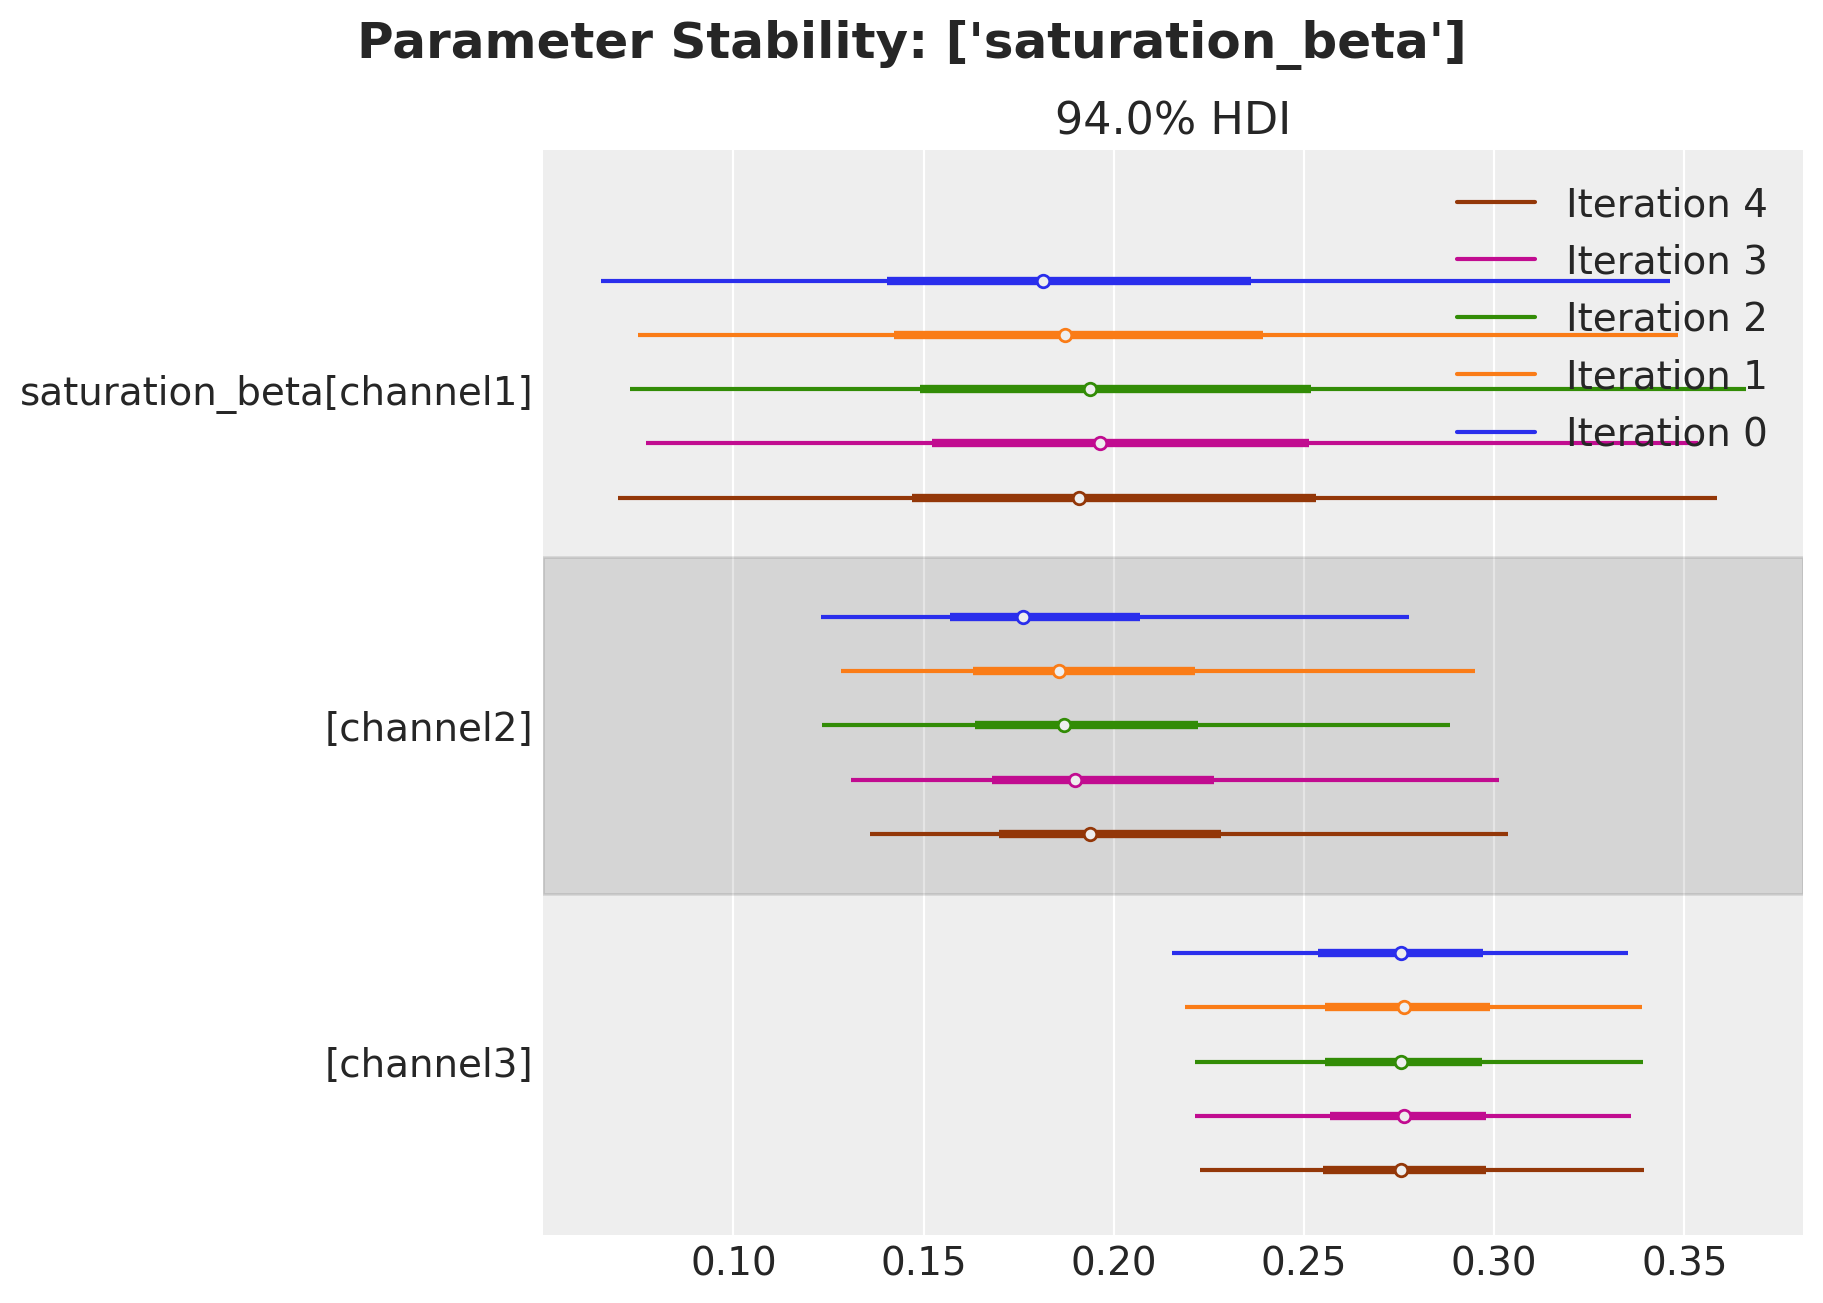

In [ ]:
cv.plot.param_stability(
    cv_results,
    parameter=["saturation_beta"]
);

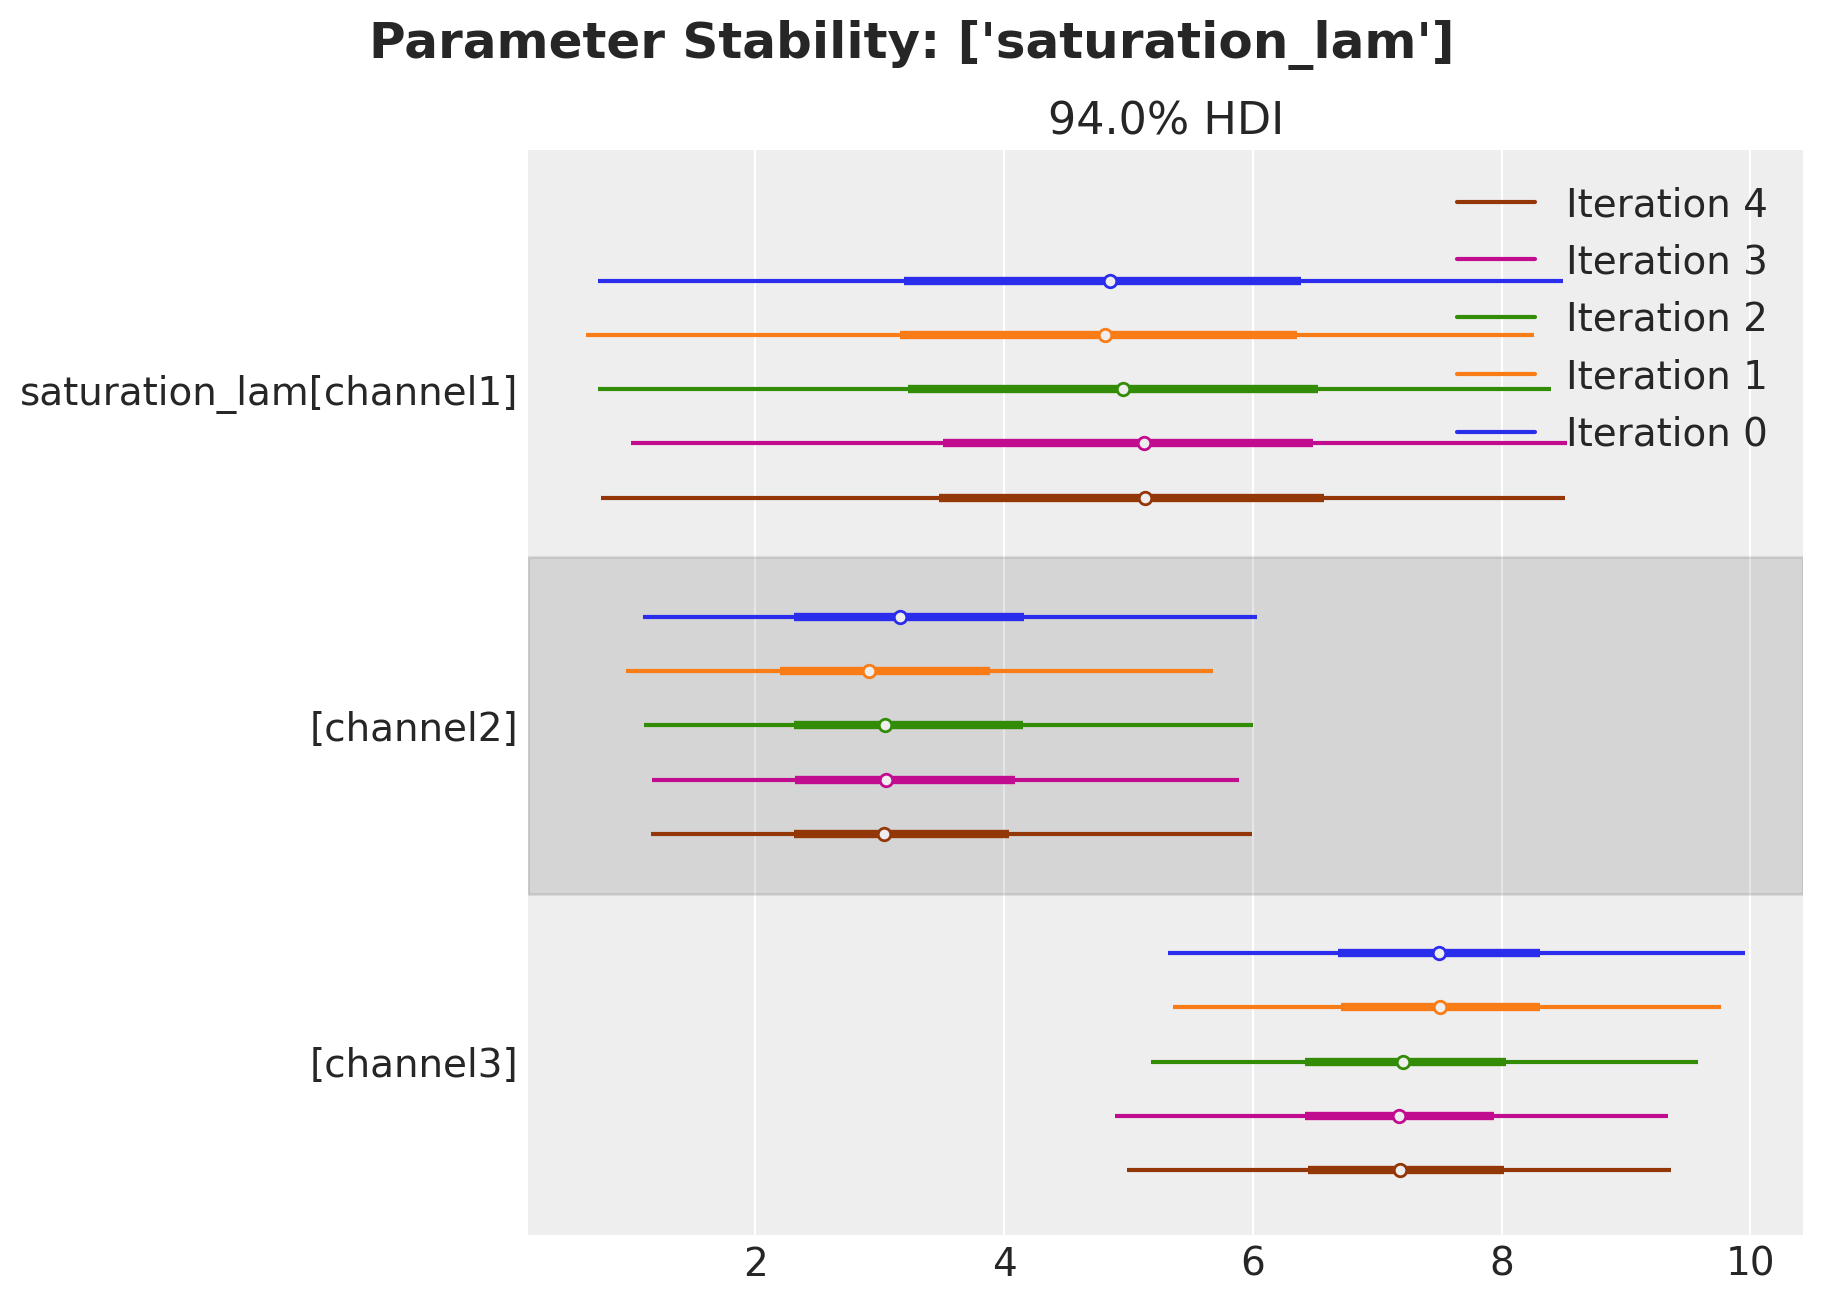

In [ ]:
cv.plot.param_stability(
    cv_results,
    parameter=["saturation_lam"]
);

/Users/Office/.local/lib/python3.12/site-packages/pymc_marketing/mmm/plot.py:4628: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.07, 1, 1])


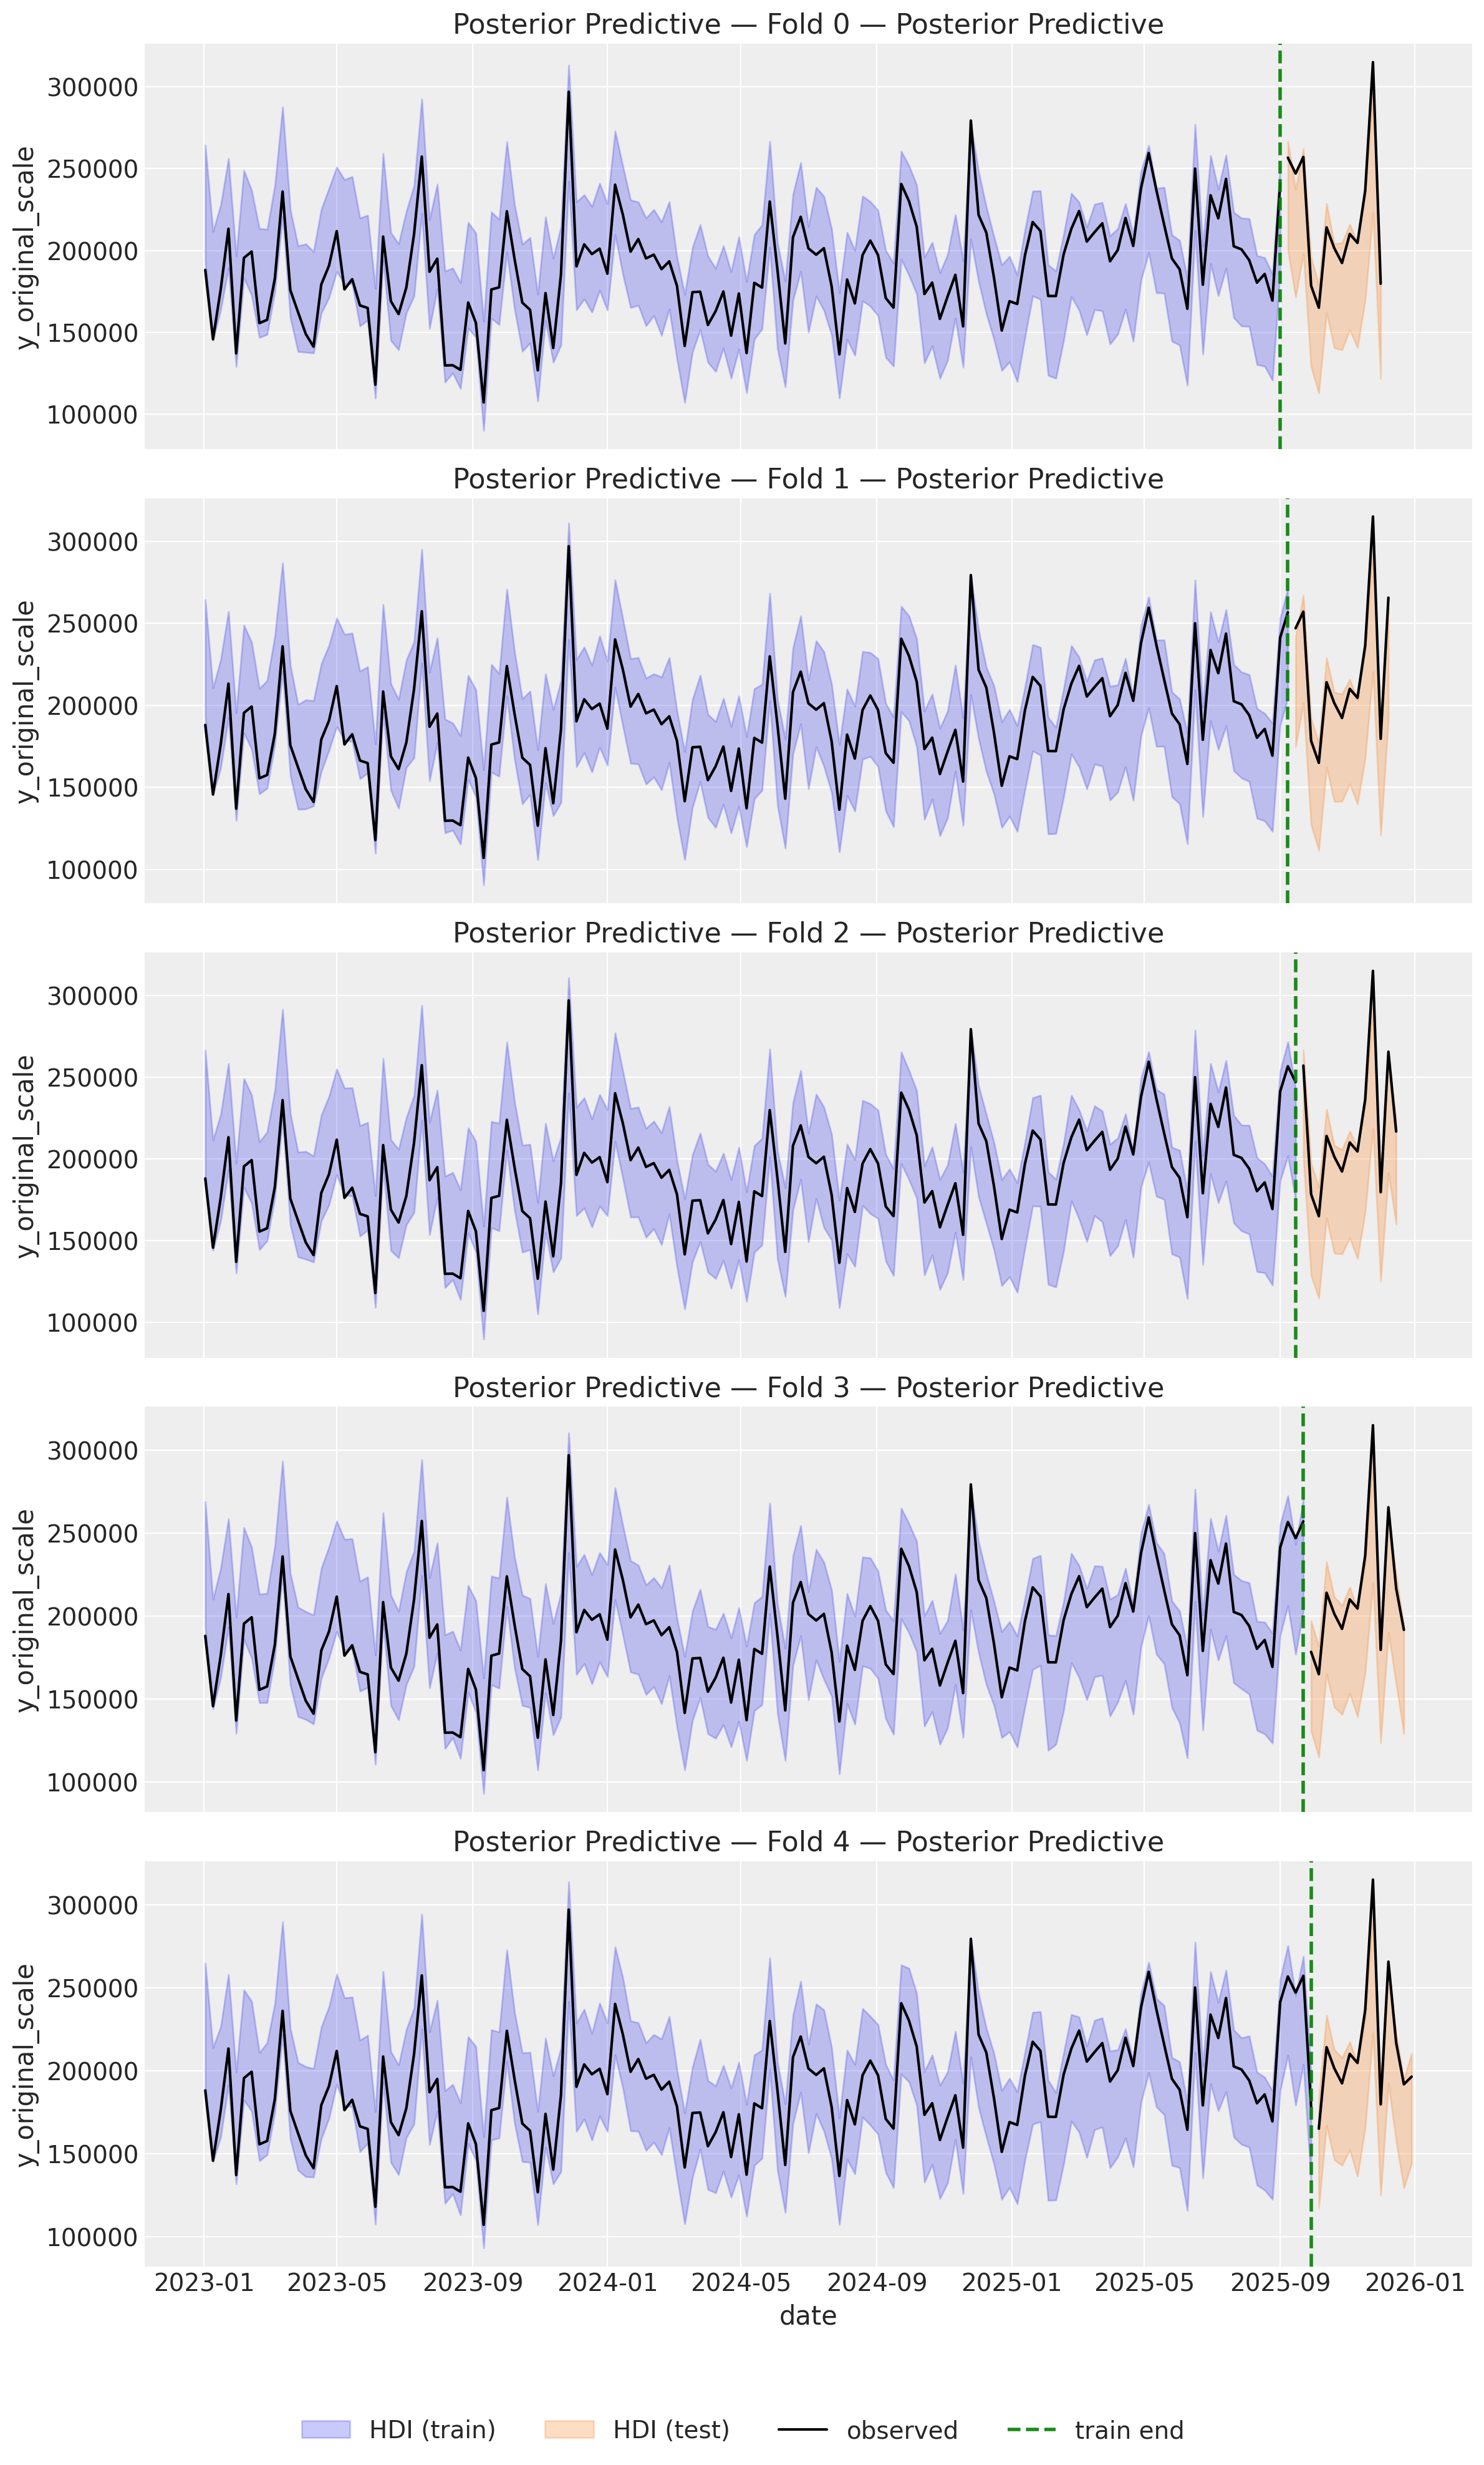

In [ ]:
# Plot model predictions across time slices
cv.plot.cv_predictions(
    cv_results
);

## Media deep dive

In [38]:
mmm.plot_interactive.roas(
    frequency="yearly",
    color="date",
    x="channel",
)

In [29]:
mmm.plot_interactive.roas()

In [39]:
mmm.plot_interactive.contributions(frequency="all_time")

In [40]:
mmm.plot_interactive.contributions(
    frequency="yearly",
    color="channel",
    x="date",
)

In [41]:
mmm.plot_interactive.contributions(
    component="control",
    frequency="yearly",
    color="control",
    x="date",
    hdi_prob=None,
)

In [42]:
mmm.plot_interactive.saturation_curves(
)

/Users/Office/.local/lib/python3.12/site-packages/pymc_extras/prior.py:822: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
Sampling: []


Output()

In [43]:
mmm.plot_interactive.adstock_curves(
    single_dim_facet="col",
)

Sampling: []


Output()

## Budget Optimization

In [8]:
X_test[channel_columns].sum(axis=0)

channel1    150216.08
channel2     72902.43
channel3     84802.32
dtype: float64

In [9]:
X_test[channel_columns].sum().sum()

np.float64(307920.82999999996)

In [8]:
num_periods = X_test.shape[0]

# Total budget for the test set per channel
all_budget_per_channel = X_test[channel_columns].sum()

# Total budget for the test set
all_budget = all_budget_per_channel.sum()

# Weekly budget for each channel
# We are assuming we do not know the total budget allocation in advance
# so this would be the naive "uniform" allocation.
weekly_budget = all_budget / num_periods

In [53]:
weekly_budget

np.float64(20528.05533333333)

In [9]:
percentage_change = 0.5

mean_spend_per_period_test = X_test[channel_columns].mean()

budget_bounds = {
    key: [(1 - percentage_change) * value, (1 + percentage_change) * value]
    for key, value in (mean_spend_per_period_test).to_dict().items()
}

budget_bounds_xr = xr.DataArray(
    data=list(budget_bounds.values()),
    dims=["channel", "bound"],
    coords={
        "channel": list(budget_bounds.keys()),
        "bound": ["lower", "upper"],
    },
)

In [10]:
# Get the test date range for optimization
start_date = X_test[date_column].min()
end_date = X_test[date_column].max()

# Create the wrapper
optimizable_model = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=str(start_date),
    end_date=str(end_date),
)

In [11]:
allocation_strategy, optimization_result = optimizable_model.optimize_budget(
    budget=weekly_budget,
    budget_bounds=budget_bounds_xr,
    minimize_kwargs={
        "method": "SLSQP",
        "options": {"ftol": 1e-4, "maxiter": 10_000},
    },
)

/Users/Office/.local/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(


In [12]:
# Calculate current spend per channel in X_test (total over test period)
current_spend = X_test[channel_columns].sum()

# Calculate optimized spend per channel
optimized_spend = allocation_strategy * num_periods

# Calculate total spend for percentage calculation
total_current_spend = current_spend.sum()
total_optimized_spend = optimized_spend.sum()

# Calculate spend percentages
current_spend_pct = (current_spend / total_current_spend) * 100
optimized_spend_pct = (optimized_spend / total_optimized_spend) * 100

# Combine into a DataFrame for comparison
spend_comparison = pd.DataFrame({
    "Current Spend (%)": current_spend_pct,
    "Optimized Spend (%)": optimized_spend_pct
})

print(spend_comparison)

          Current Spend (%)  Optimized Spend (%)
channel1          48.783994             31.88857
channel2          23.675706             26.80098
channel3          27.540300             41.31045


In [ ]:
fig, ax = plt.subplots()

contribution_comparison_df = (
    pd.Series(allocation_strategy, index=mean_spend_per_period_test.index)
    .to_frame(name="optimized_allocation")
    .join(mean_spend_per_period_test.to_frame(name="initial_allocation"))
    .sort_index(ascending=False)
)
contribution_comparison_df.plot.barh(figsize=(12, 8), color=["C1", "C0"], ax=ax)
ax.set(title="Budget Allocation Comparison", xlabel="allocation");

In [14]:
shares_comparison_df = contribution_comparison_df / contribution_comparison_df.sum(
    axis=0
)

shares_comparison_df = shares_comparison_df.assign(
    # We can compute the multiplier as the ratio of the optimized to the initial allocation.
    # This will be used to re-weight the original training data.
    multiplier=lambda df: df["optimized_allocation"] / df["initial_allocation"]
)

shares_comparison_df

,optimized_allocation,initial_allocation,multiplier
channel3,0.413104,0.275403,1.500000
channel2,0.268010,0.236757,1.132003
channel1,0.318886,0.487840,0.653669


In [15]:
X_test_weighted = X_test.copy()

# We re-weight the original test data with the optimized allocation distribution.
for channel in channel_columns:
    channel_multiplier = shares_comparison_df[shares_comparison_df.index == channel][
        "multiplier"
    ].item()
    X_test_weighted[channel] = X_test_weighted[channel] * channel_multiplier

# We normalize the total spend in the optimized data to be the same as in the original data.
normalization_factor = (
    X_test[channel_columns].sum().sum() / X_test_weighted[channel_columns].sum().sum()
)

# We apply the normalization factor to the optimized data.
X_test_weighted[channel_columns] = (
    X_test_weighted[channel_columns] * normalization_factor
)

# We validate that the total spend is the same as in the original data.
np.testing.assert_allclose(
    X_test_weighted[channel_columns].sum().sum(),
    X_test[channel_columns].sum().sum(),
)

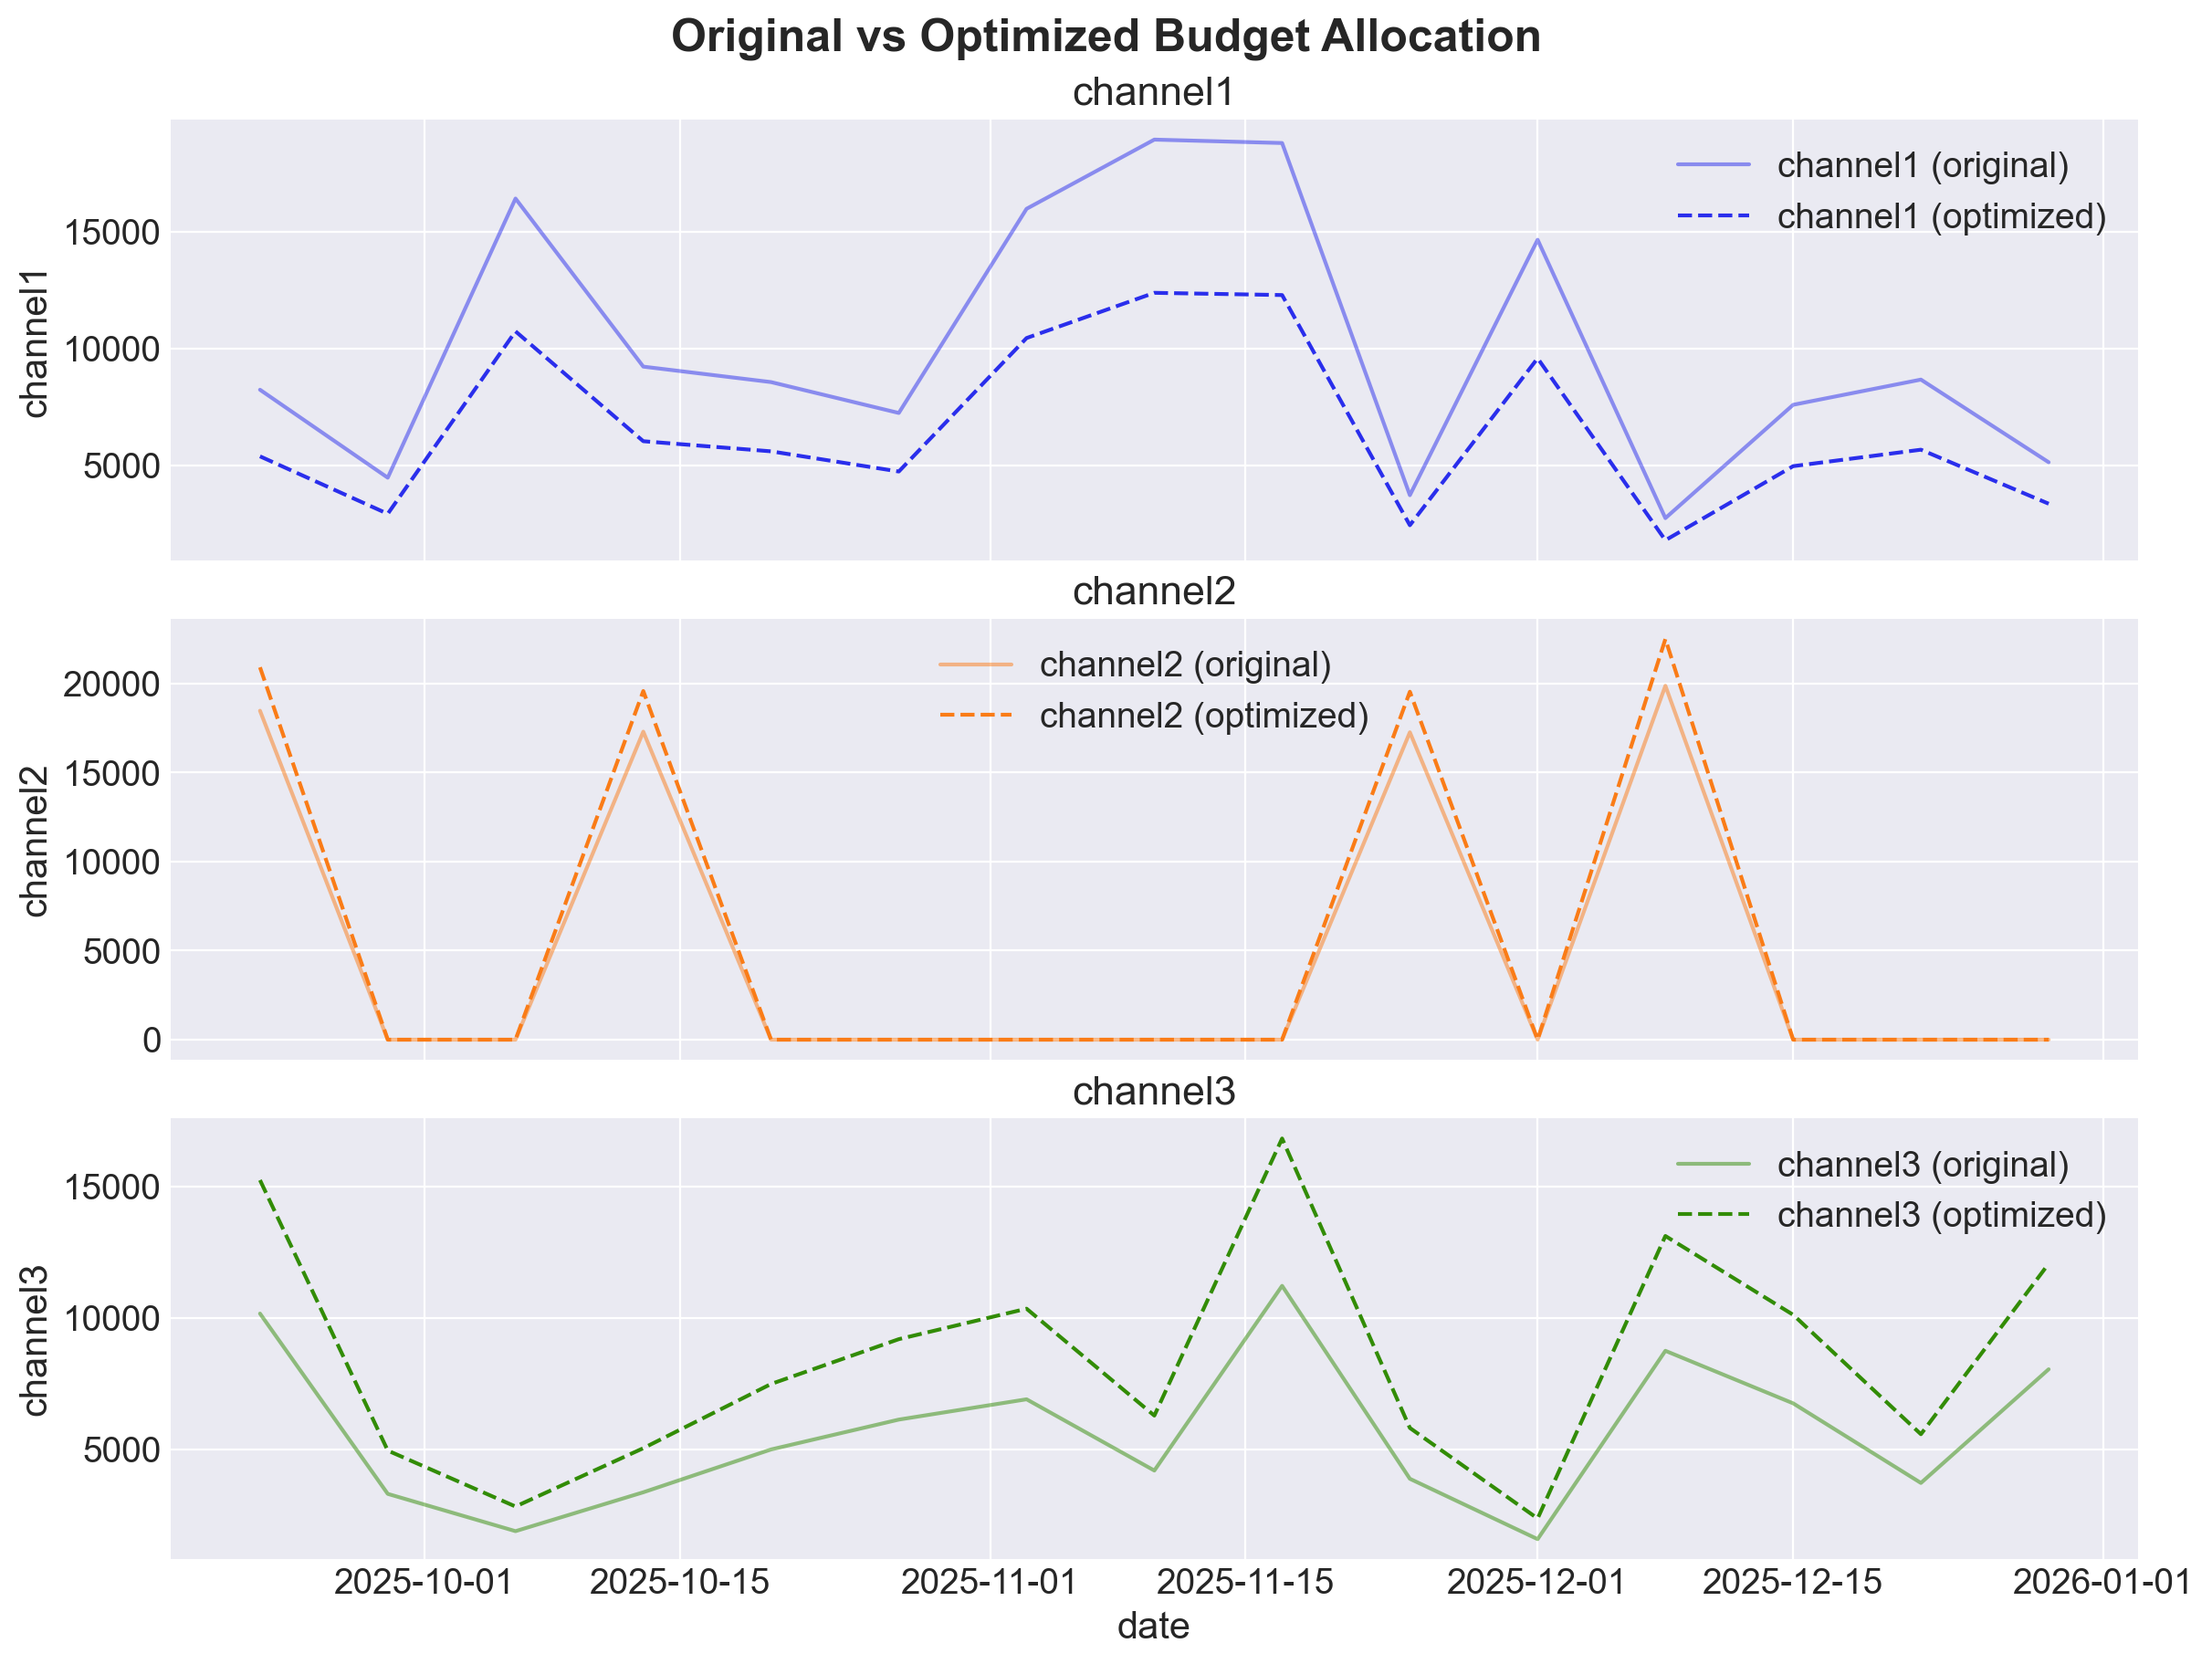

In [26]:
fig, axes = plt.subplots(
    nrows=n_channels,
    ncols=1,
    figsize=(12, 3 * n_channels),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for i, channel in enumerate(channel_columns):
    ax = axes[i]
    sns.lineplot(
        data=X_test,
        x=date_column,
        y=channel,
        color=f"C{i}",
        label=f"{channel} (original)",
        alpha=0.5,
        ax=ax,
    )
    sns.lineplot(
        data=X_test_weighted,
        x=date_column,
        y=channel,
        color=f"C{i}",
        linestyle="--",
        label=f"{channel} (optimized)",
        ax=ax,
    )
    ax.set(title=f"{channel}")

ax.set_xlabel("date")

fig.suptitle(
    "Original vs Optimized Budget Allocation",
    fontsize=18,
    fontweight="bold",
);

In [17]:
rng = np.random.default_rng(123)
y_pred_test = mmm.sample_posterior_predictive(
    X_test,
    var_names=["y_original_scale", "channel_contribution_original_scale"],
    include_last_observations=True,
    extend_idata=False,
    progressbar=False,
    random_seed=rng,
)

y_pred_test_weighted = mmm.sample_posterior_predictive(
    X_test_weighted,
    var_names=["y_original_scale", "channel_contribution_original_scale"],
    include_last_observations=True,
    extend_idata=False,
    progressbar=False,
    random_seed=rng,
)

Sampling: [y]
Sampling: [y]


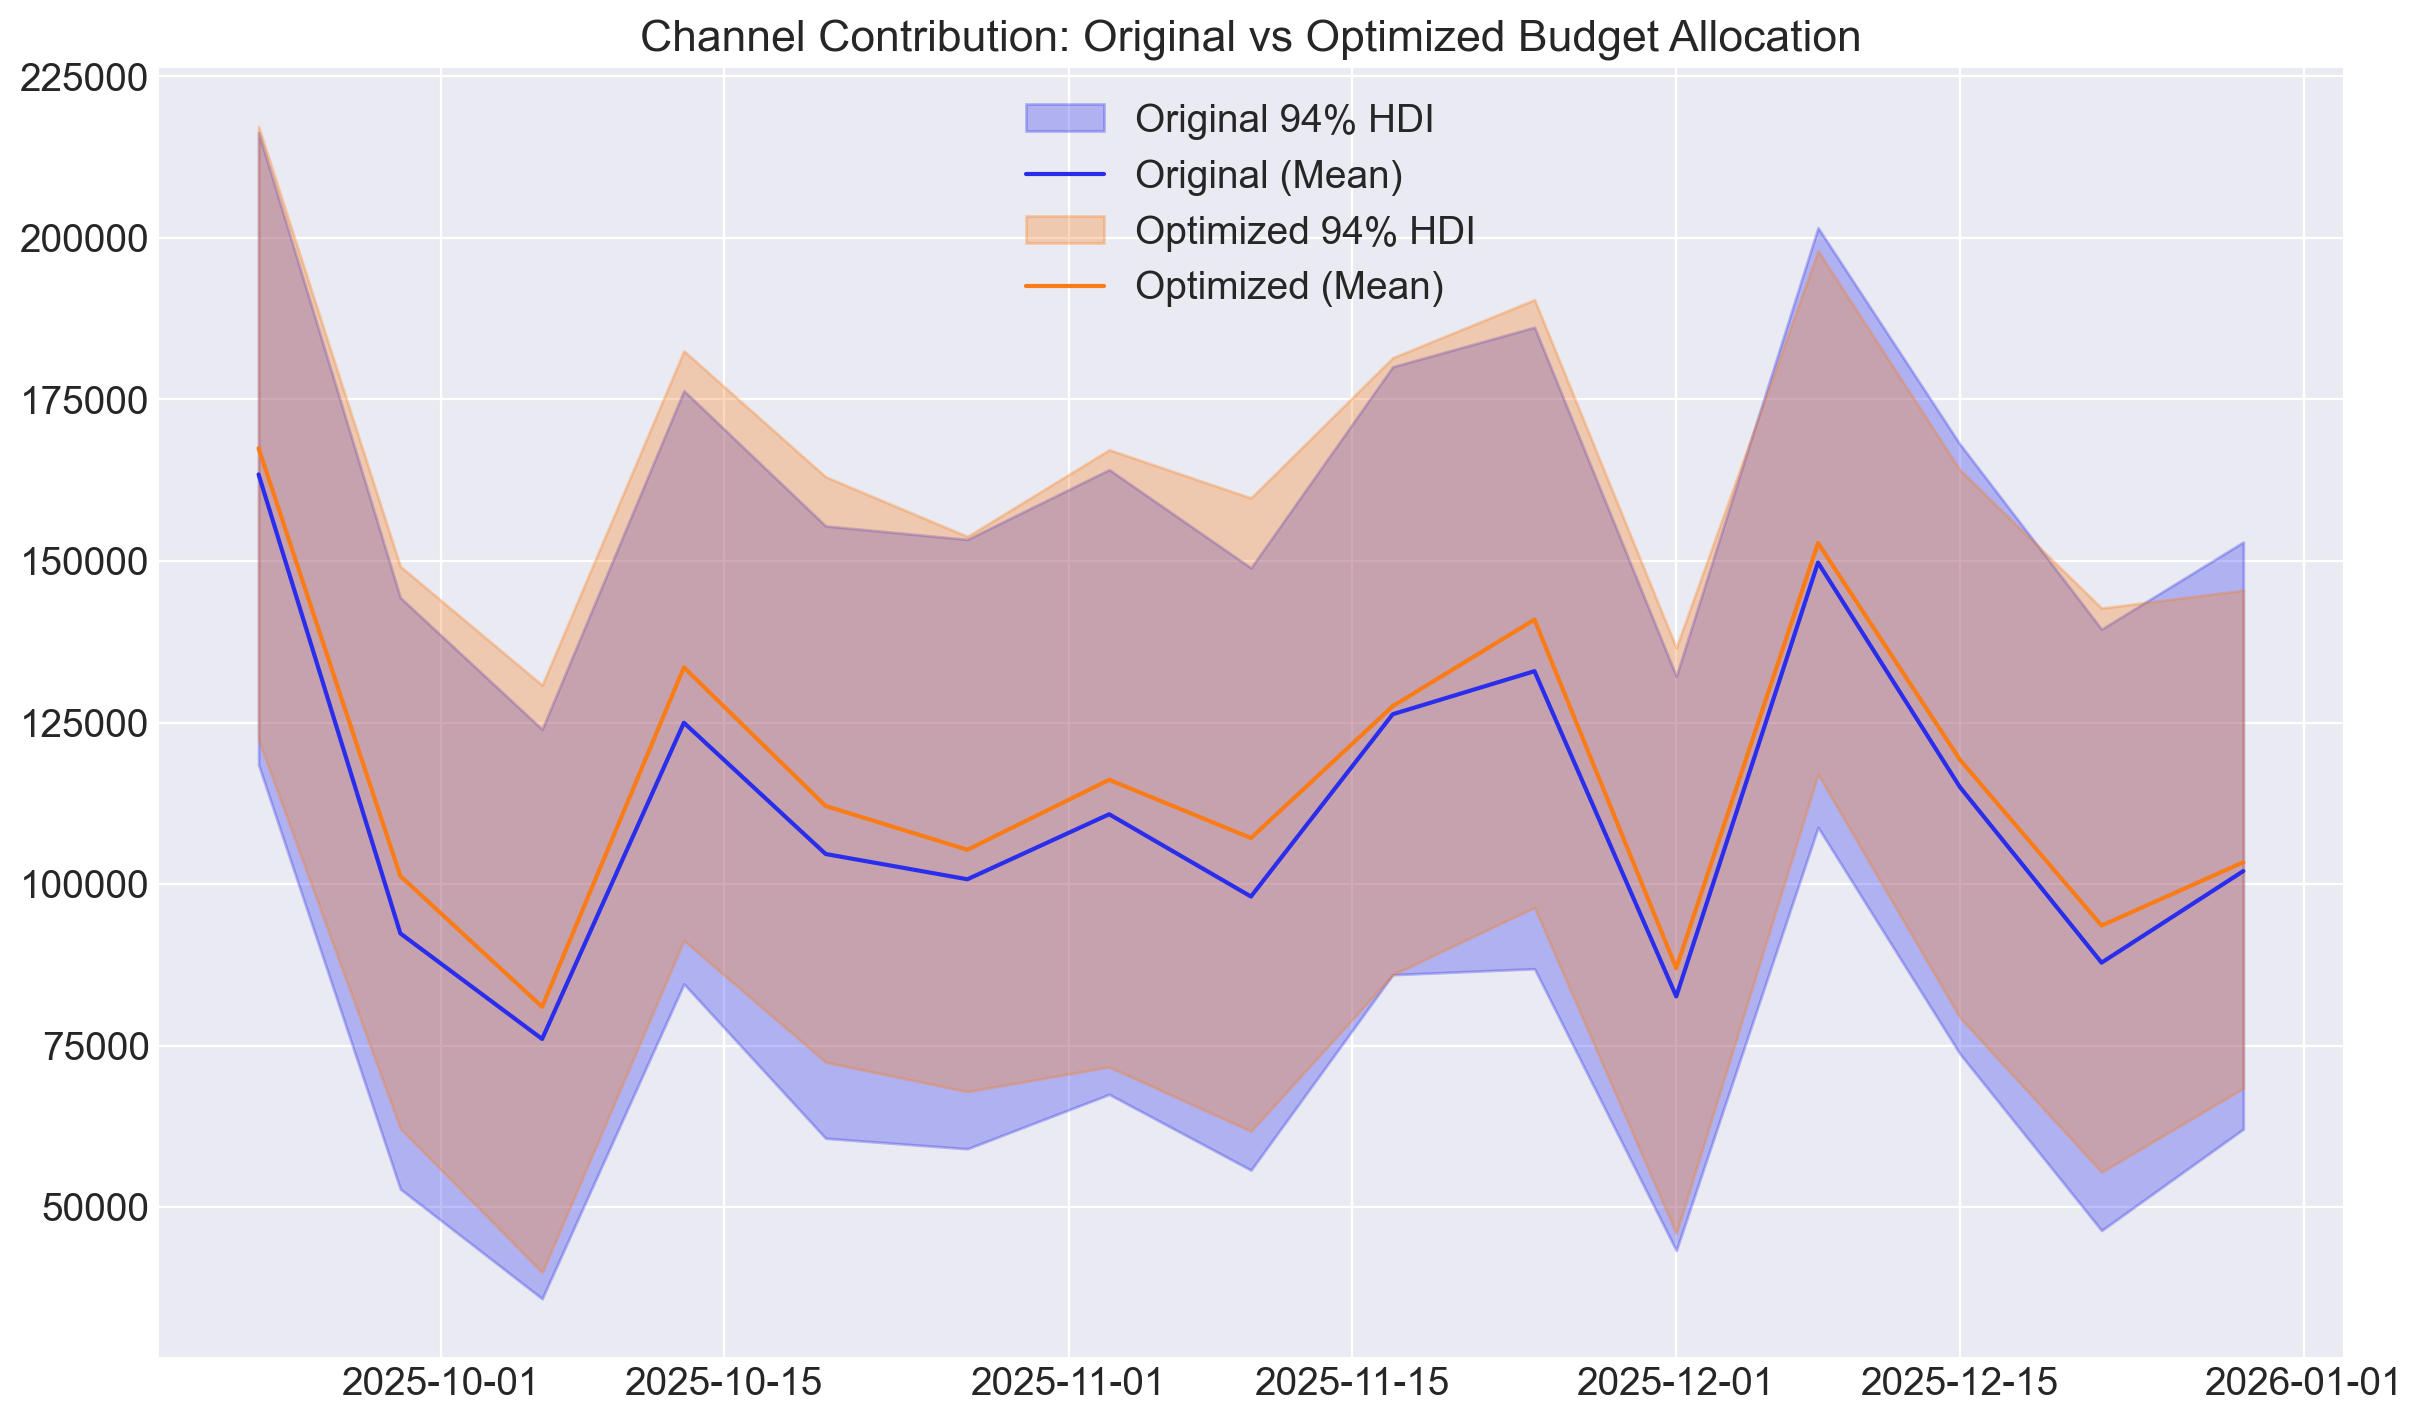

In [29]:
fig, ax = plt.subplots()

az.plot_hdi(
    y_pred_test.date,
    y_pred_test["channel_contribution_original_scale"]
    .unstack()
    .transpose(..., "date")
    .sum(dim="channel"),
    smooth=False,
    color="C0",
    fill_kwargs={"alpha": 0.3, "label": "Original 94% HDI"},
    ax=ax,
)

ax.plot(
    y_pred_test.date,
    y_pred_test["channel_contribution_original_scale"]
    .unstack()
    .transpose(..., "date")
    .sum(dim="channel")
    .mean(dim=("chain", "draw")),
    color="C0",
    label="Original (Mean)",
)

az.plot_hdi(
    y_pred_test_weighted.date,
    y_pred_test_weighted["channel_contribution_original_scale"]
    .unstack()
    .transpose(..., "date")
    .sum(dim="channel"),
    smooth=False,
    color="C1",
    fill_kwargs={"alpha": 0.3, "label": "Optimized 94% HDI"},
    ax=ax,
)

ax.plot(
    y_pred_test_weighted.date,
    y_pred_test_weighted["channel_contribution_original_scale"]
    .unstack()
    .transpose(..., "date")
    .sum(dim="channel")
    .mean(dim=("chain", "draw")),
    color="C1",
    label="Optimized (Mean)",
)

ax.legend()
ax.set_title("Channel Contribution: Original vs Optimized Budget Allocation", fontsize=16);

In [39]:
y_pred_test["channel_contribution_original_scale"].sum(dim=("date", "channel")).mean()

<xarray.DataArray 'channel_contribution_original_scale' ()> Size: 8B
array(1667477.58953257)

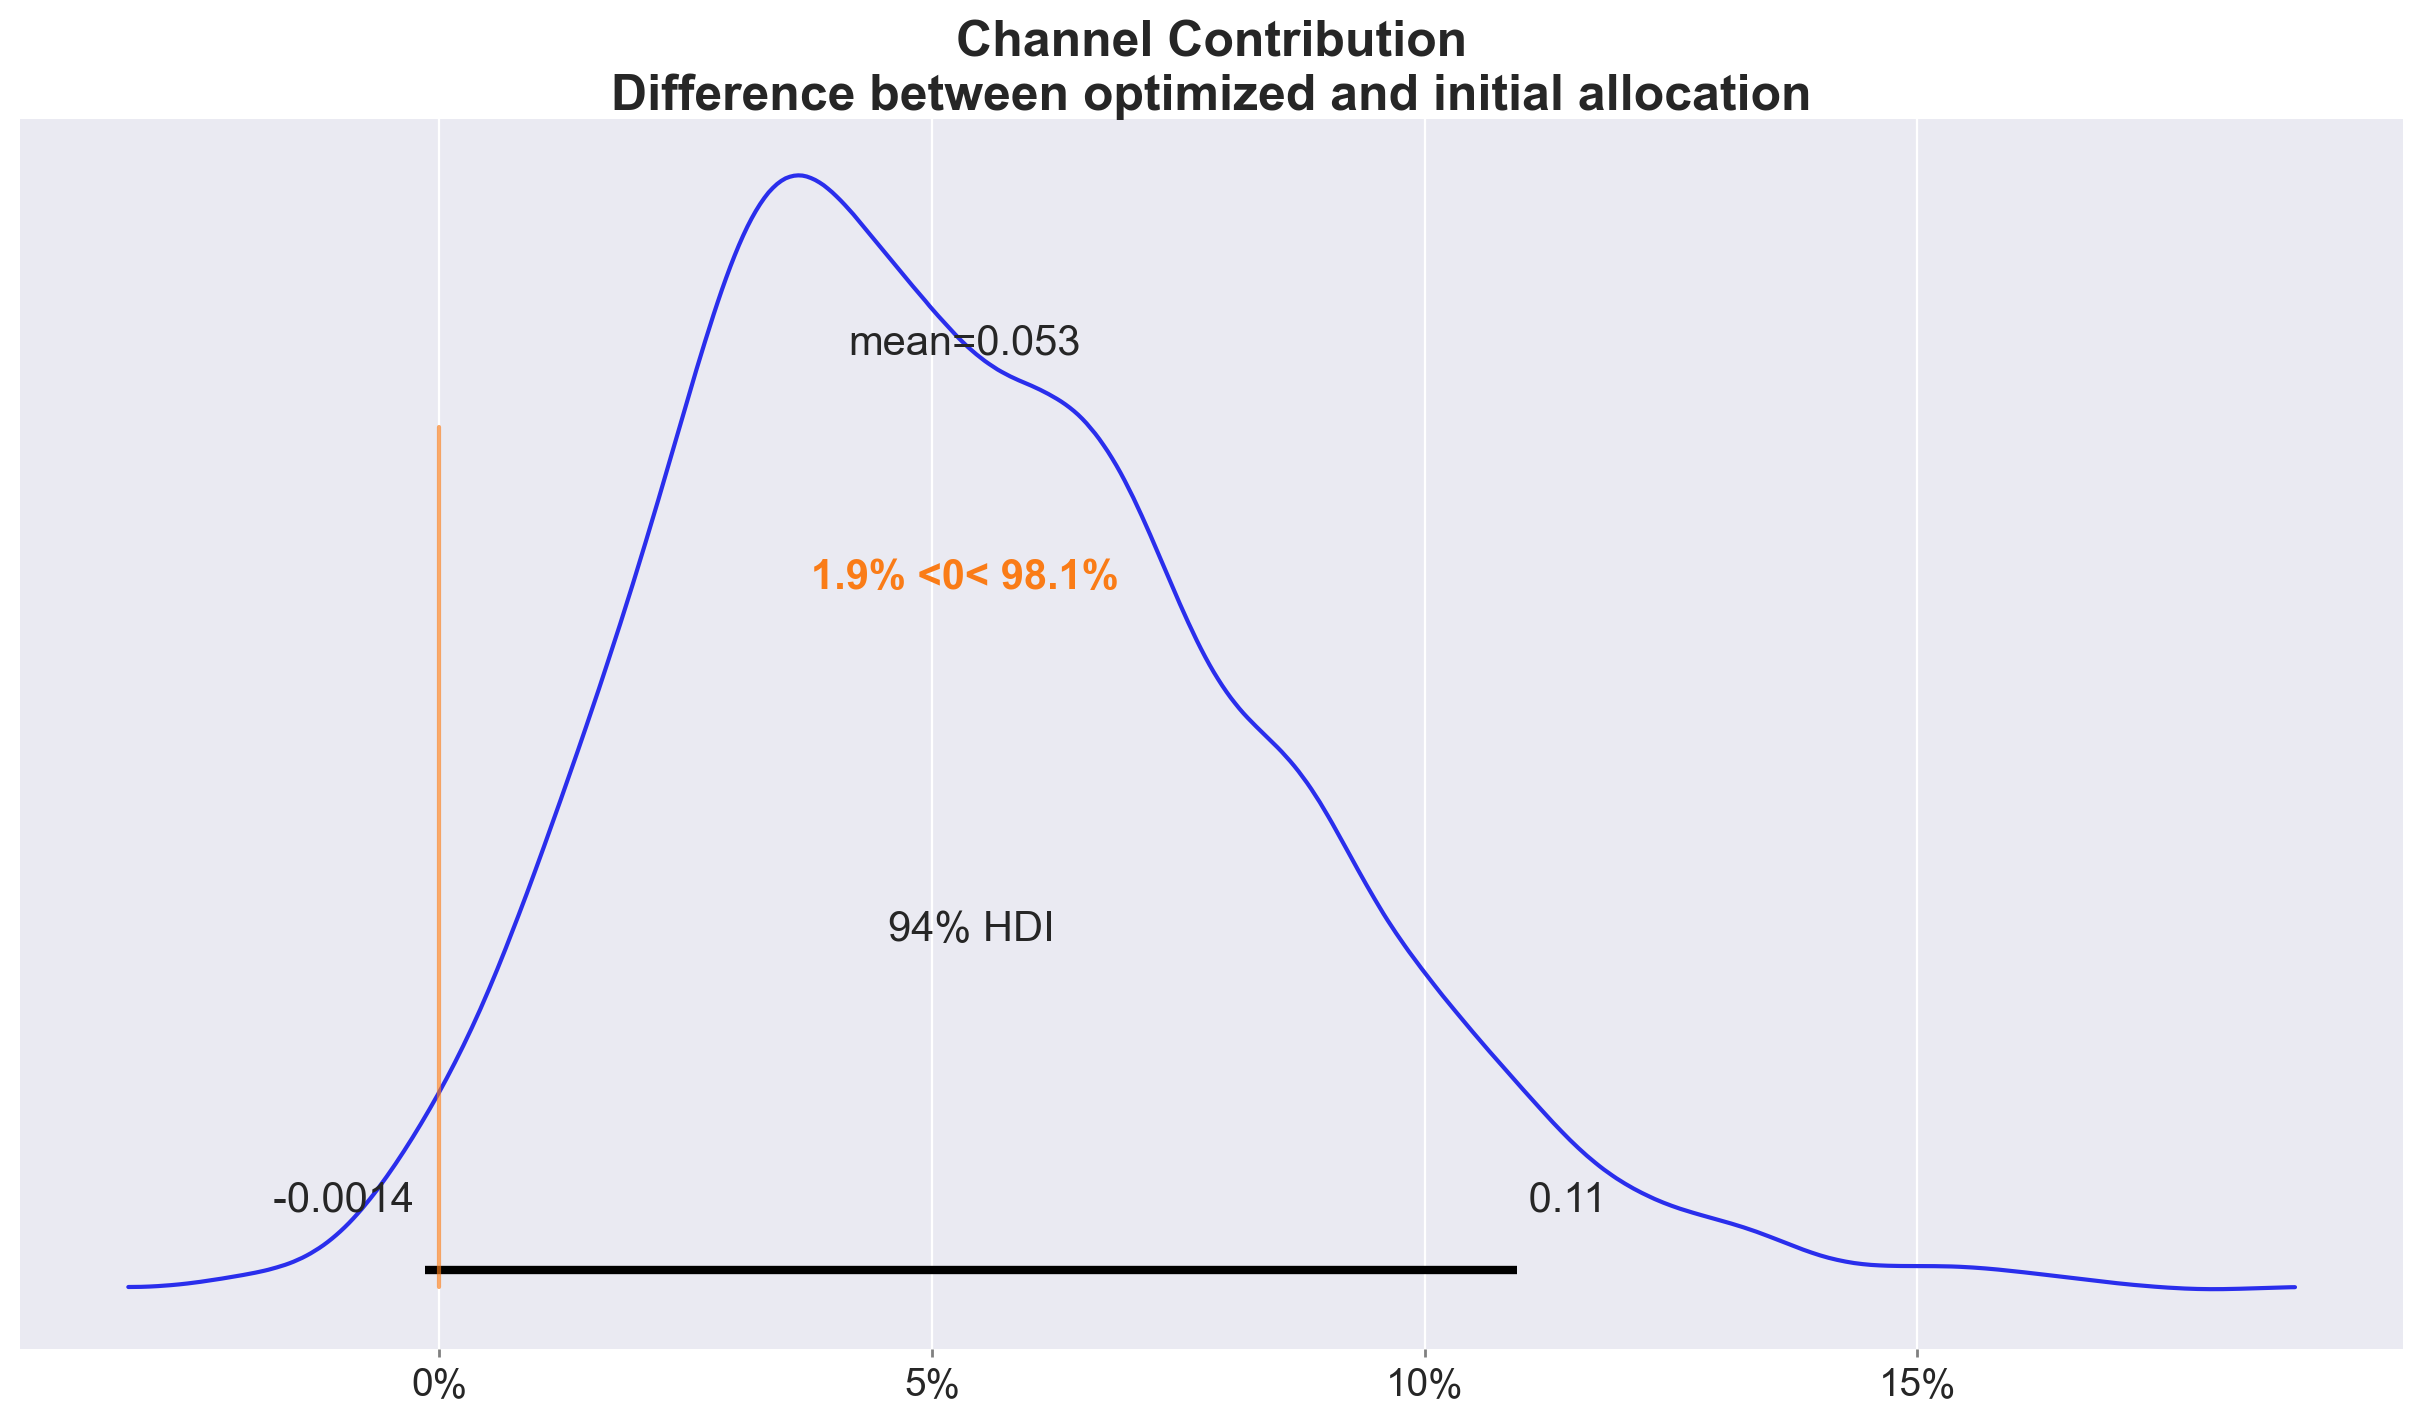

In [34]:
fig, ax = plt.subplots()
az.plot_posterior(
    (
        y_pred_test_weighted["channel_contribution_original_scale"].unstack()
        .sum(dim="channel")
        .transpose(..., "date").sum(dim="date")
        - y_pred_test["channel_contribution_original_scale"]
        .unstack()
        .sum(dim="channel")
        .transpose(..., "date")
        .sum(dim="date")
    )
    / y_pred_test["channel_contribution_original_scale"].unstack()
        .sum(dim="channel")
        .transpose(..., "date")
        .sum(dim="date"),
    ref_val=0,
    ax=ax,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(
    "Channel Contribution\nDifference between optimized and initial allocation",
    fontsize=18,
    fontweight="bold",
);

### Sales comparison

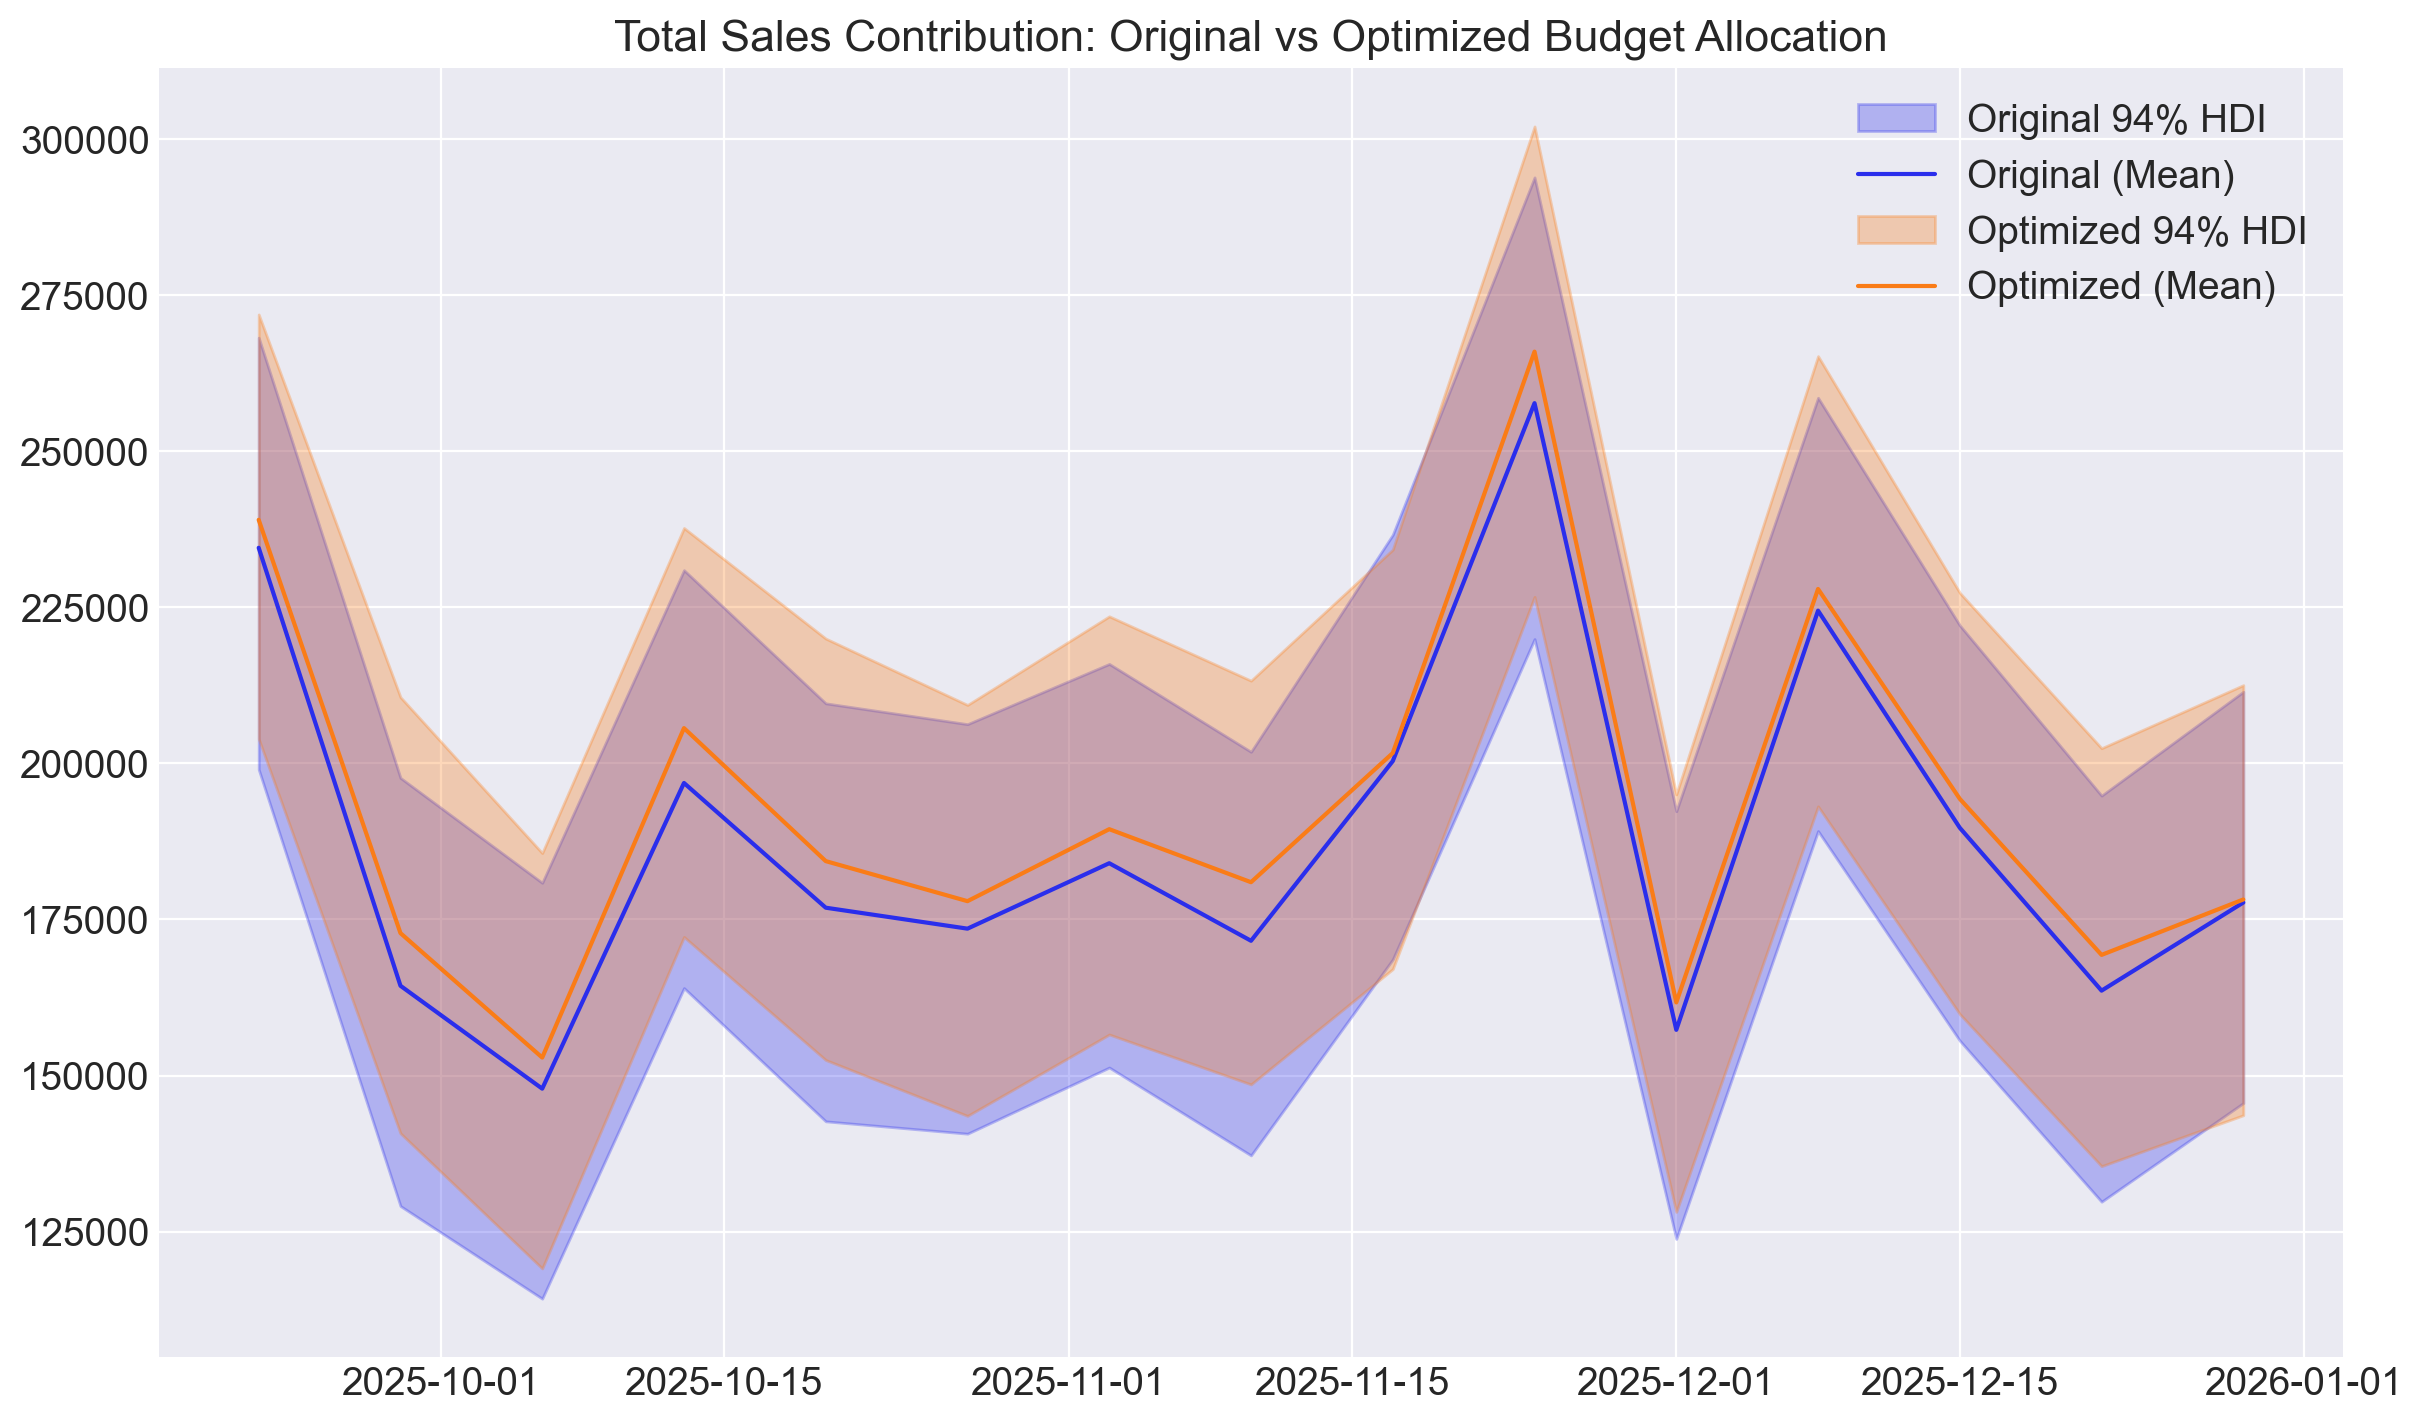

In [39]:
fig, ax = plt.subplots()

az.plot_hdi(
    y_pred_test.date,
    y_pred_test["y_original_scale"]
    .unstack()
    .transpose(..., "date"),
    smooth=False,
    color="C0",
    fill_kwargs={"alpha": 0.3, "label": "Original 94% HDI"},
    ax=ax,
)

ax.plot(
    y_pred_test.date,
    y_pred_test["y_original_scale"]
    .unstack()
    .transpose(..., "date")
    .mean(dim=("chain", "draw")),
    color="C0",
    label="Original (Mean)",
)

az.plot_hdi(
    y_pred_test_weighted.date,
    y_pred_test_weighted["y_original_scale"]
    .unstack()
    .transpose(..., "date"),
    smooth=False,
    color="C1",
    fill_kwargs={"alpha": 0.3, "label": "Optimized 94% HDI"},
    ax=ax,
)

ax.plot(
    y_pred_test_weighted.date,
    y_pred_test_weighted["y_original_scale"]
    .unstack()
    .transpose(..., "date")
    .mean(dim=("chain", "draw")),
    color="C1",
    label="Optimized (Mean)",
)

ax.legend()
ax.set_title("Total Sales Contribution: Original vs Optimized Budget Allocation", fontsize=16);

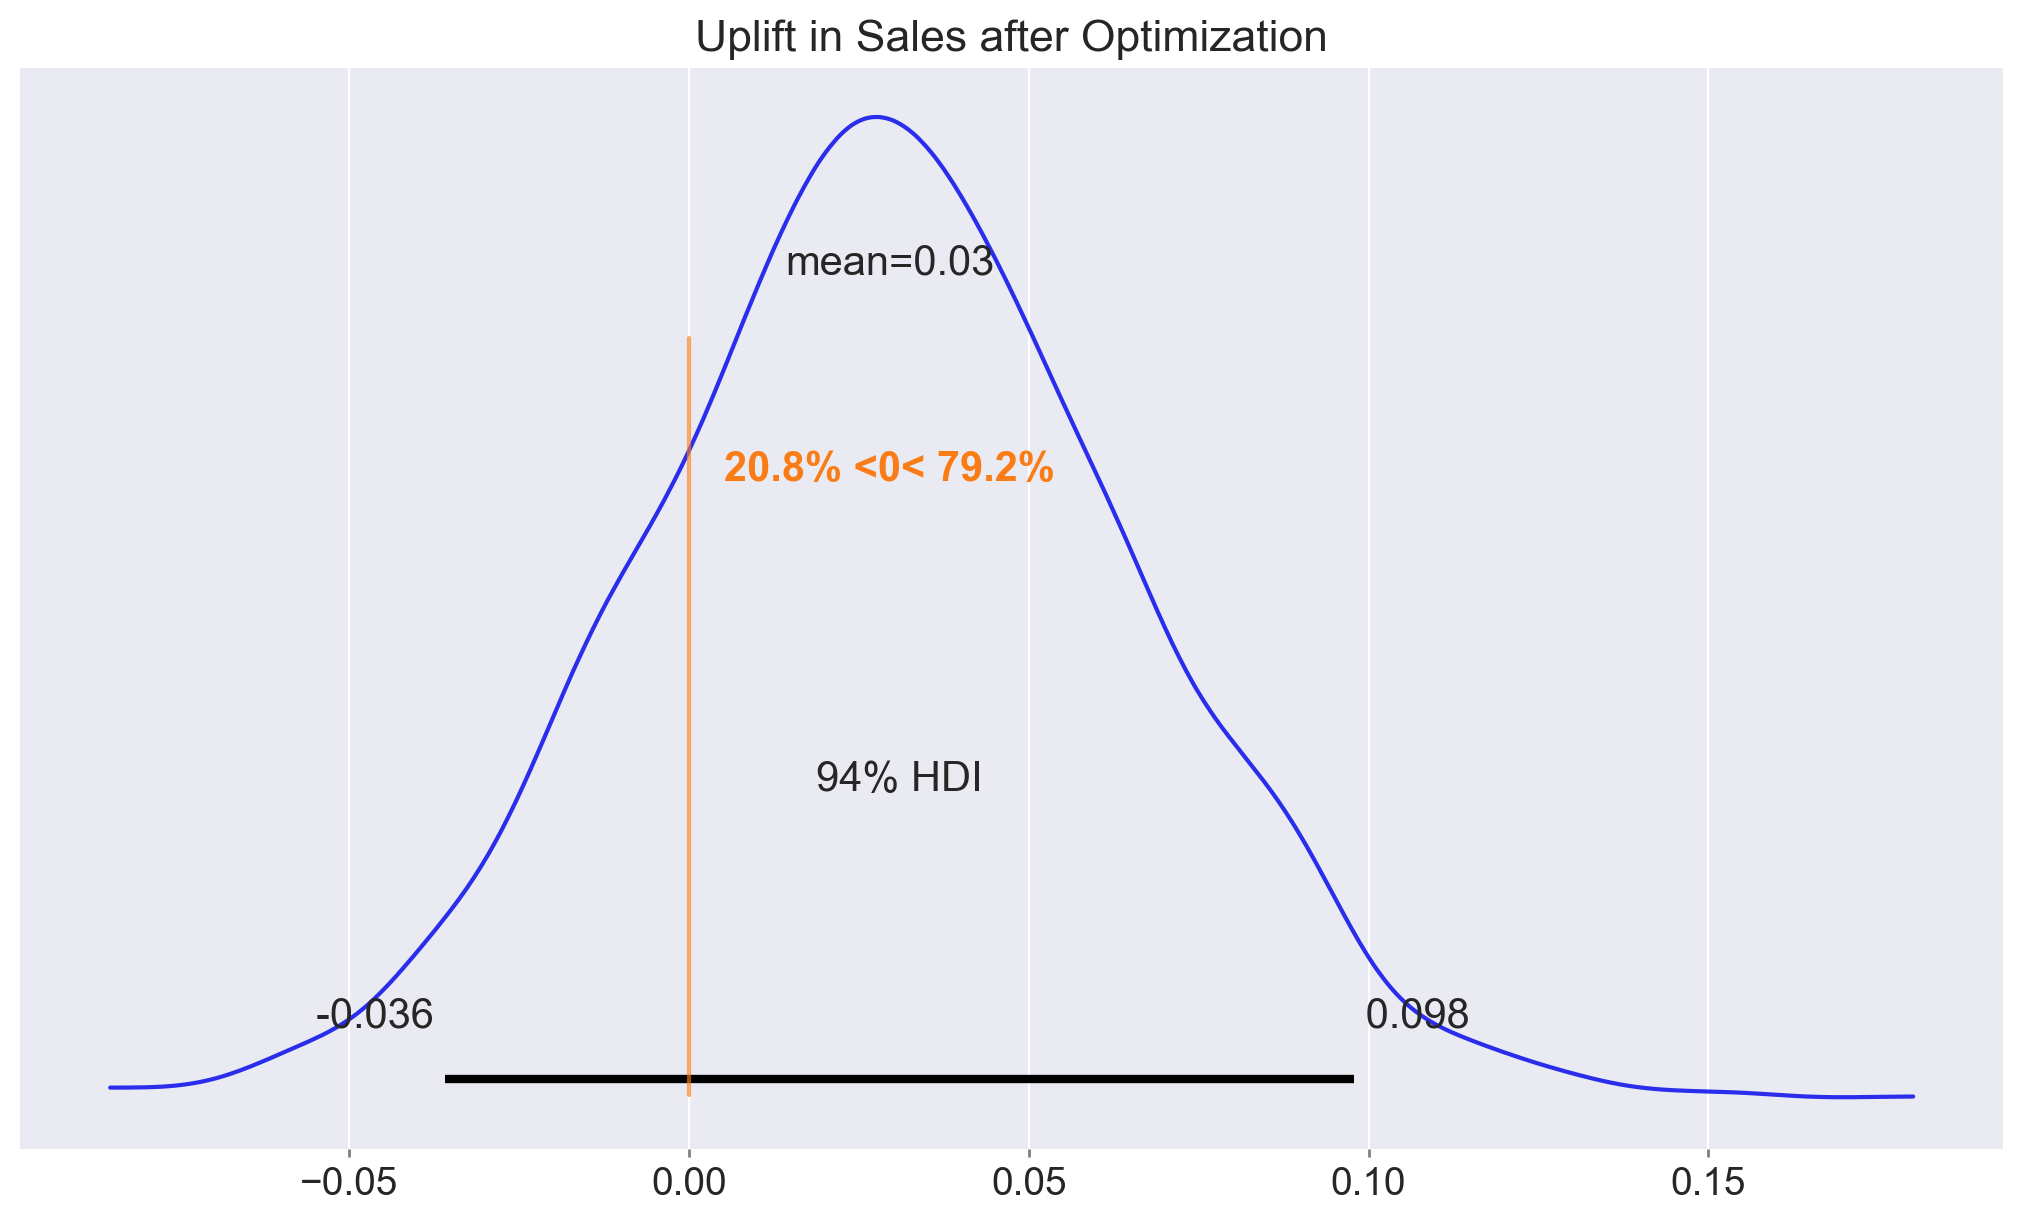

In [40]:
uplift = (
    y_pred_test_weighted["y_original_scale"].sum(dim=("date")).unstack()
    / y_pred_test["y_original_scale"].sum(dim=("date")).unstack()
) - 1

fig, ax = plt.subplots(figsize=(10, 6))
az.plot_posterior(uplift, var_names=["y_original_scale"], ref_val=0, ax=ax)
ax.set_title("Uplift in Sales after Optimization", fontsize=16);

## Budget sizing

Let us look at marketing response given initial spend during test period

In [41]:
initial_budget = mean_spend_per_period_test.to_dict()
initial_budget

{'channel1': 10014.405333333332,
 'channel2': 4860.161999999999,
 'channel3': 5653.487999999999}

In [42]:
import xarray as xr

initial_budget_xr = xr.DataArray(
    data=list(initial_budget.values()),
    dims=["channel"],
    coords={"channel": list(initial_budget.keys())},
    name="initial_budget"
)
initial_budget_xr

<xarray.DataArray 'initial_budget' (channel: 3)> Size: 24B
array([10014.40533333,  4860.162     ,  5653.488     ])
Coordinates:
  * channel  (channel) <U8 96B 'channel1' 'channel2' 'channel3'

In [43]:
sample_response_give_initial_budget = optimizable_model.sample_response_distribution(
    allocation_strategy=initial_budget_xr,  # Here we add the initial budget allocation strategy
    include_carryover=True,
    include_last_observations=False,
)

Sampling: [y]


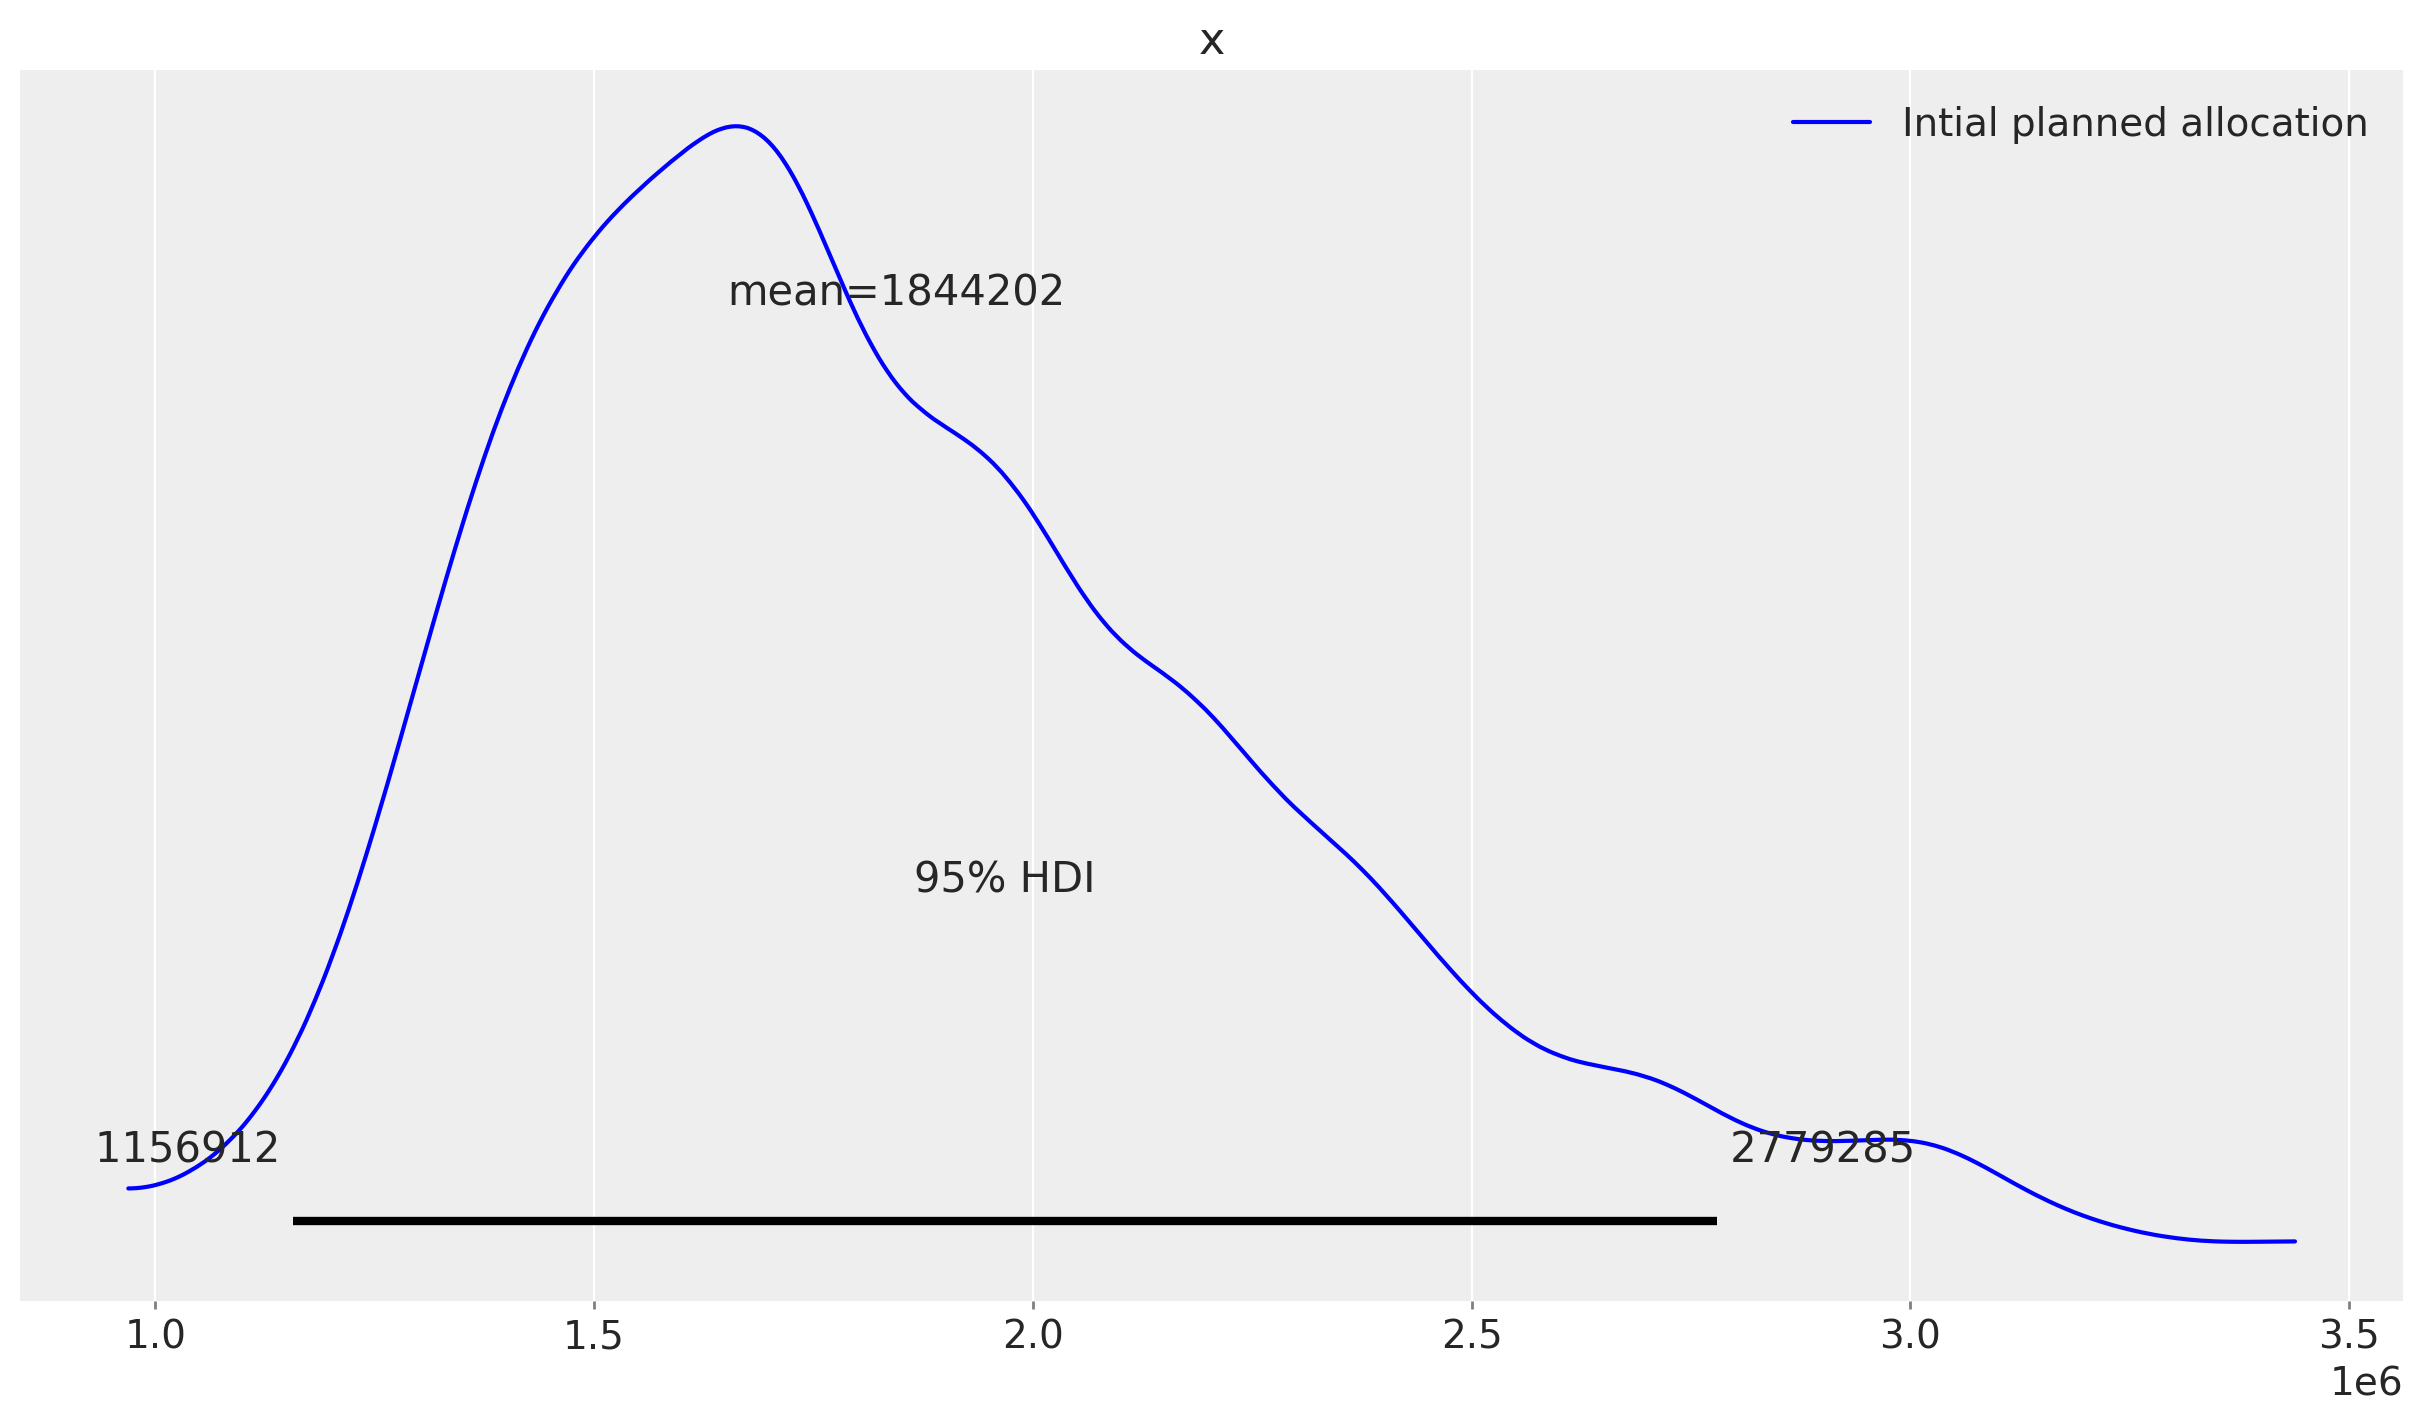

In [25]:
fig, ax = plt.subplots()
az.plot_posterior(
    sample_response_give_initial_budget.total_media_contribution_original_scale.values.flatten(),
    hdi_prob=0.95,
    color="blue",
    label="Intial planned allocation",
    ax=ax,
);

In [44]:
sample_response_given_allocation = optimizable_model.sample_response_distribution(
    allocation_strategy=allocation_strategy,  # Here we add the optimized budget allocation strategy
    include_carryover=True,
    include_last_observations=False,
)

Sampling: [y]


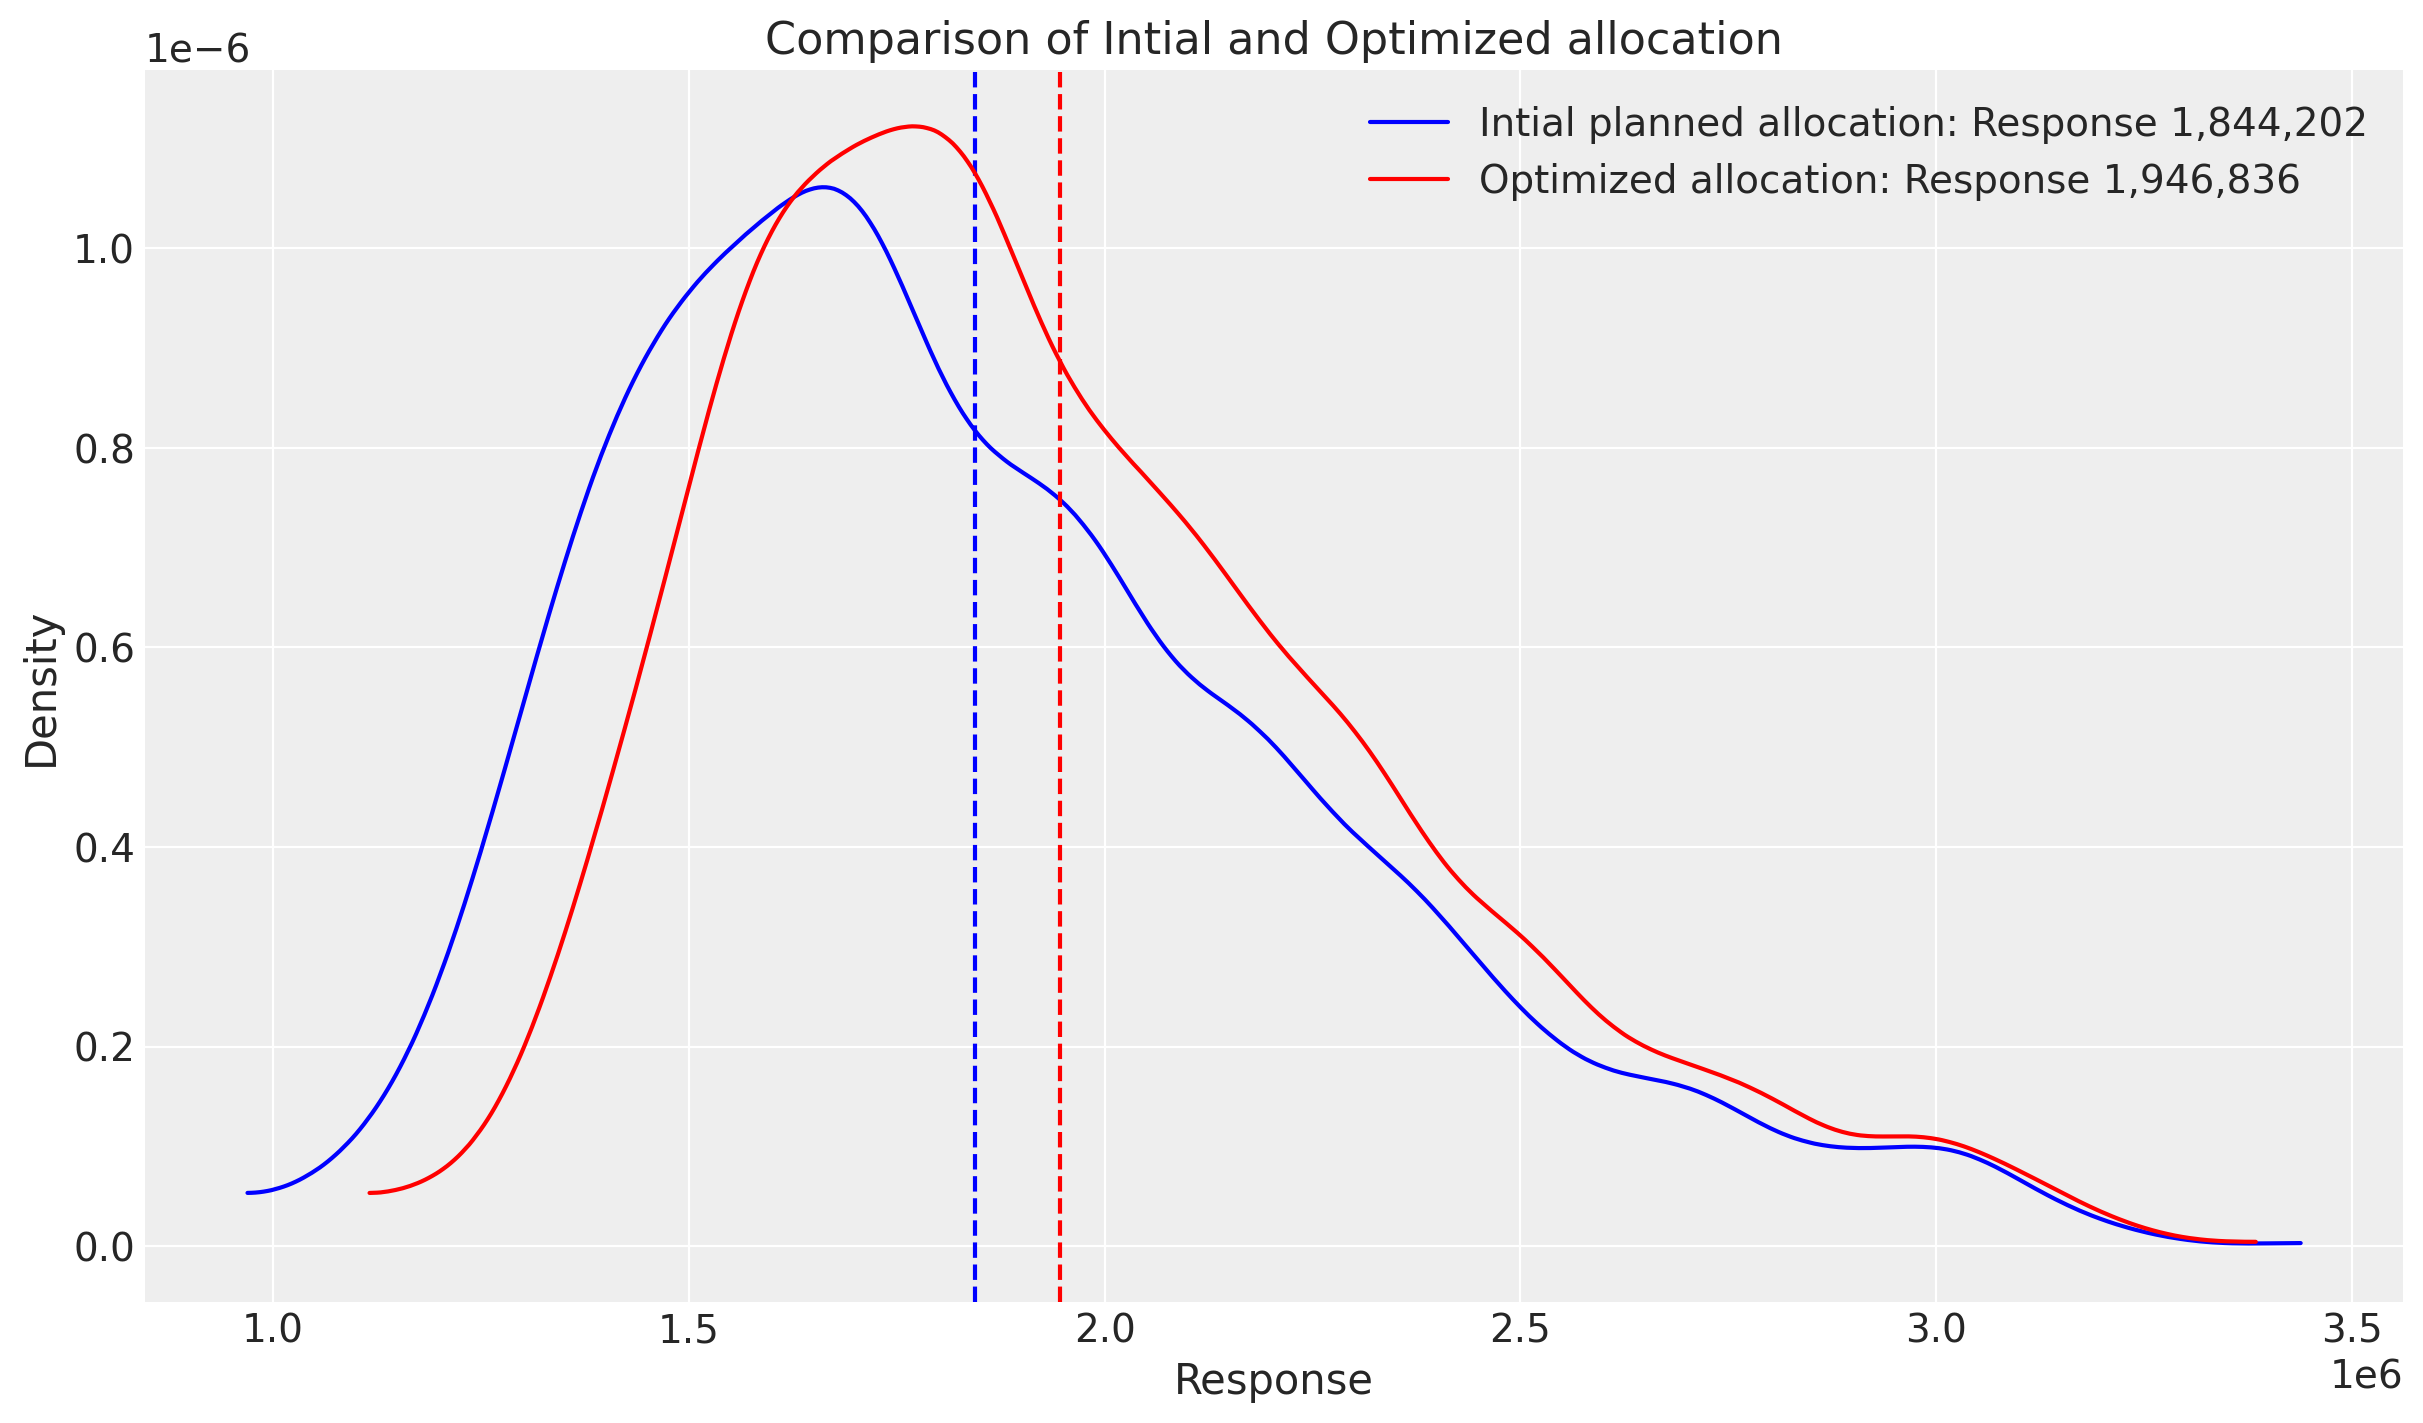

In [27]:
fig, ax = plt.subplots()

# Initial planned allocation
initial_data = sample_response_give_initial_budget.total_media_contribution_original_scale.values.flatten()
initial_mean = initial_data.mean()
az.plot_dist(
    initial_data,
    # hdi_prob=0.75,
    color="blue",
    label=f"Intial planned allocation: Response {initial_mean:,.0f}",
    ax=ax,
    # kind="hist",
)
ax.axvline(initial_mean, color="blue", linestyle="--")

# Optimized allocation
optimized_data = sample_response_given_allocation.total_media_contribution_original_scale.values.flatten()
optimized_mean = optimized_data.mean()
az.plot_dist(
    optimized_data,
    # hdi_prob=0.75,
    color="red",
    label=f"Optimized allocation: Response {optimized_mean:,.0f}",
    ax=ax,
    # kind="hist",
)
ax.axvline(optimized_mean, color="red", linestyle="--")

ax.set_title("Comparison of Intial and Optimized allocation")
ax.set_xlabel("Response")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [45]:
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
from pymc_marketing.mmm.constraints import Constraint
from pymc_marketing.mmm.utility import _check_samples_dimensionality

target_response = 1_844_000


def mean_response_eq_constraint_fun(budgets_sym, total_budget_sym,optimizer):
    """Enforces mean_response(budgets_sym) >= target_response, i.e. returns (mean_resp - target_response) >= 0."""
    resp_dist = optimizer.extract_response_distribution(
        "total_media_contribution_original_scale"
    )
    mean_resp = _check_samples_dimensionality(resp_dist).mean()
    return mean_resp - target_response


def minimize_budget_utility(samples, budgets):
    return -budgets.sum()


optimizer = BudgetOptimizer(
    num_periods=num_periods,
    model=optimizable_model,
    response_variable="total_media_contribution_original_scale",
    utility_function=minimize_budget_utility,
    default_constraints=False,
    custom_constraints=[
        Constraint(
            key="target_response_constraint",
            constraint_fun=mean_response_eq_constraint_fun,
            constraint_type="ineq",
        )
    ],
)



In [46]:
allocation_xarray_target_response, res = optimizer.allocate_budget(
    total_budget=weekly_budget,
    x0=optimization_result.x,
    minimize_kwargs={"options": {"maxiter": 2_500}},
    budget_bounds=budget_bounds_xr,
)

print("Optimal allocation:", allocation_xarray_target_response)
print("Solver result:", res)

Optimal allocation: <xarray.DataArray (channel: 3)> Size: 24B
array([6089.45030005, 4443.17397768, 8146.64888279])
Coordinates:
  * channel  (channel) <U8 96B 'channel1' 'channel2' 'channel3'
Solver result:      message: Optimization terminated successfully
     success: True
      status: 0
         fun: 18679.27316052412
           x: [ 6.089e+03  4.443e+03  8.147e+03]
         nit: 59
         jac: [ 1.000e+00  1.000e+00  1.000e+00]
        nfev: 315
        njev: 58
 multipliers: [ 1.733e-02]


In [47]:
sample_response_given_allocation_target_response = (
    optimizable_model.sample_response_distribution(
        allocation_strategy=allocation_xarray_target_response,
        include_carryover=True,
        include_last_observations=False,
    )
)

Sampling: [y]


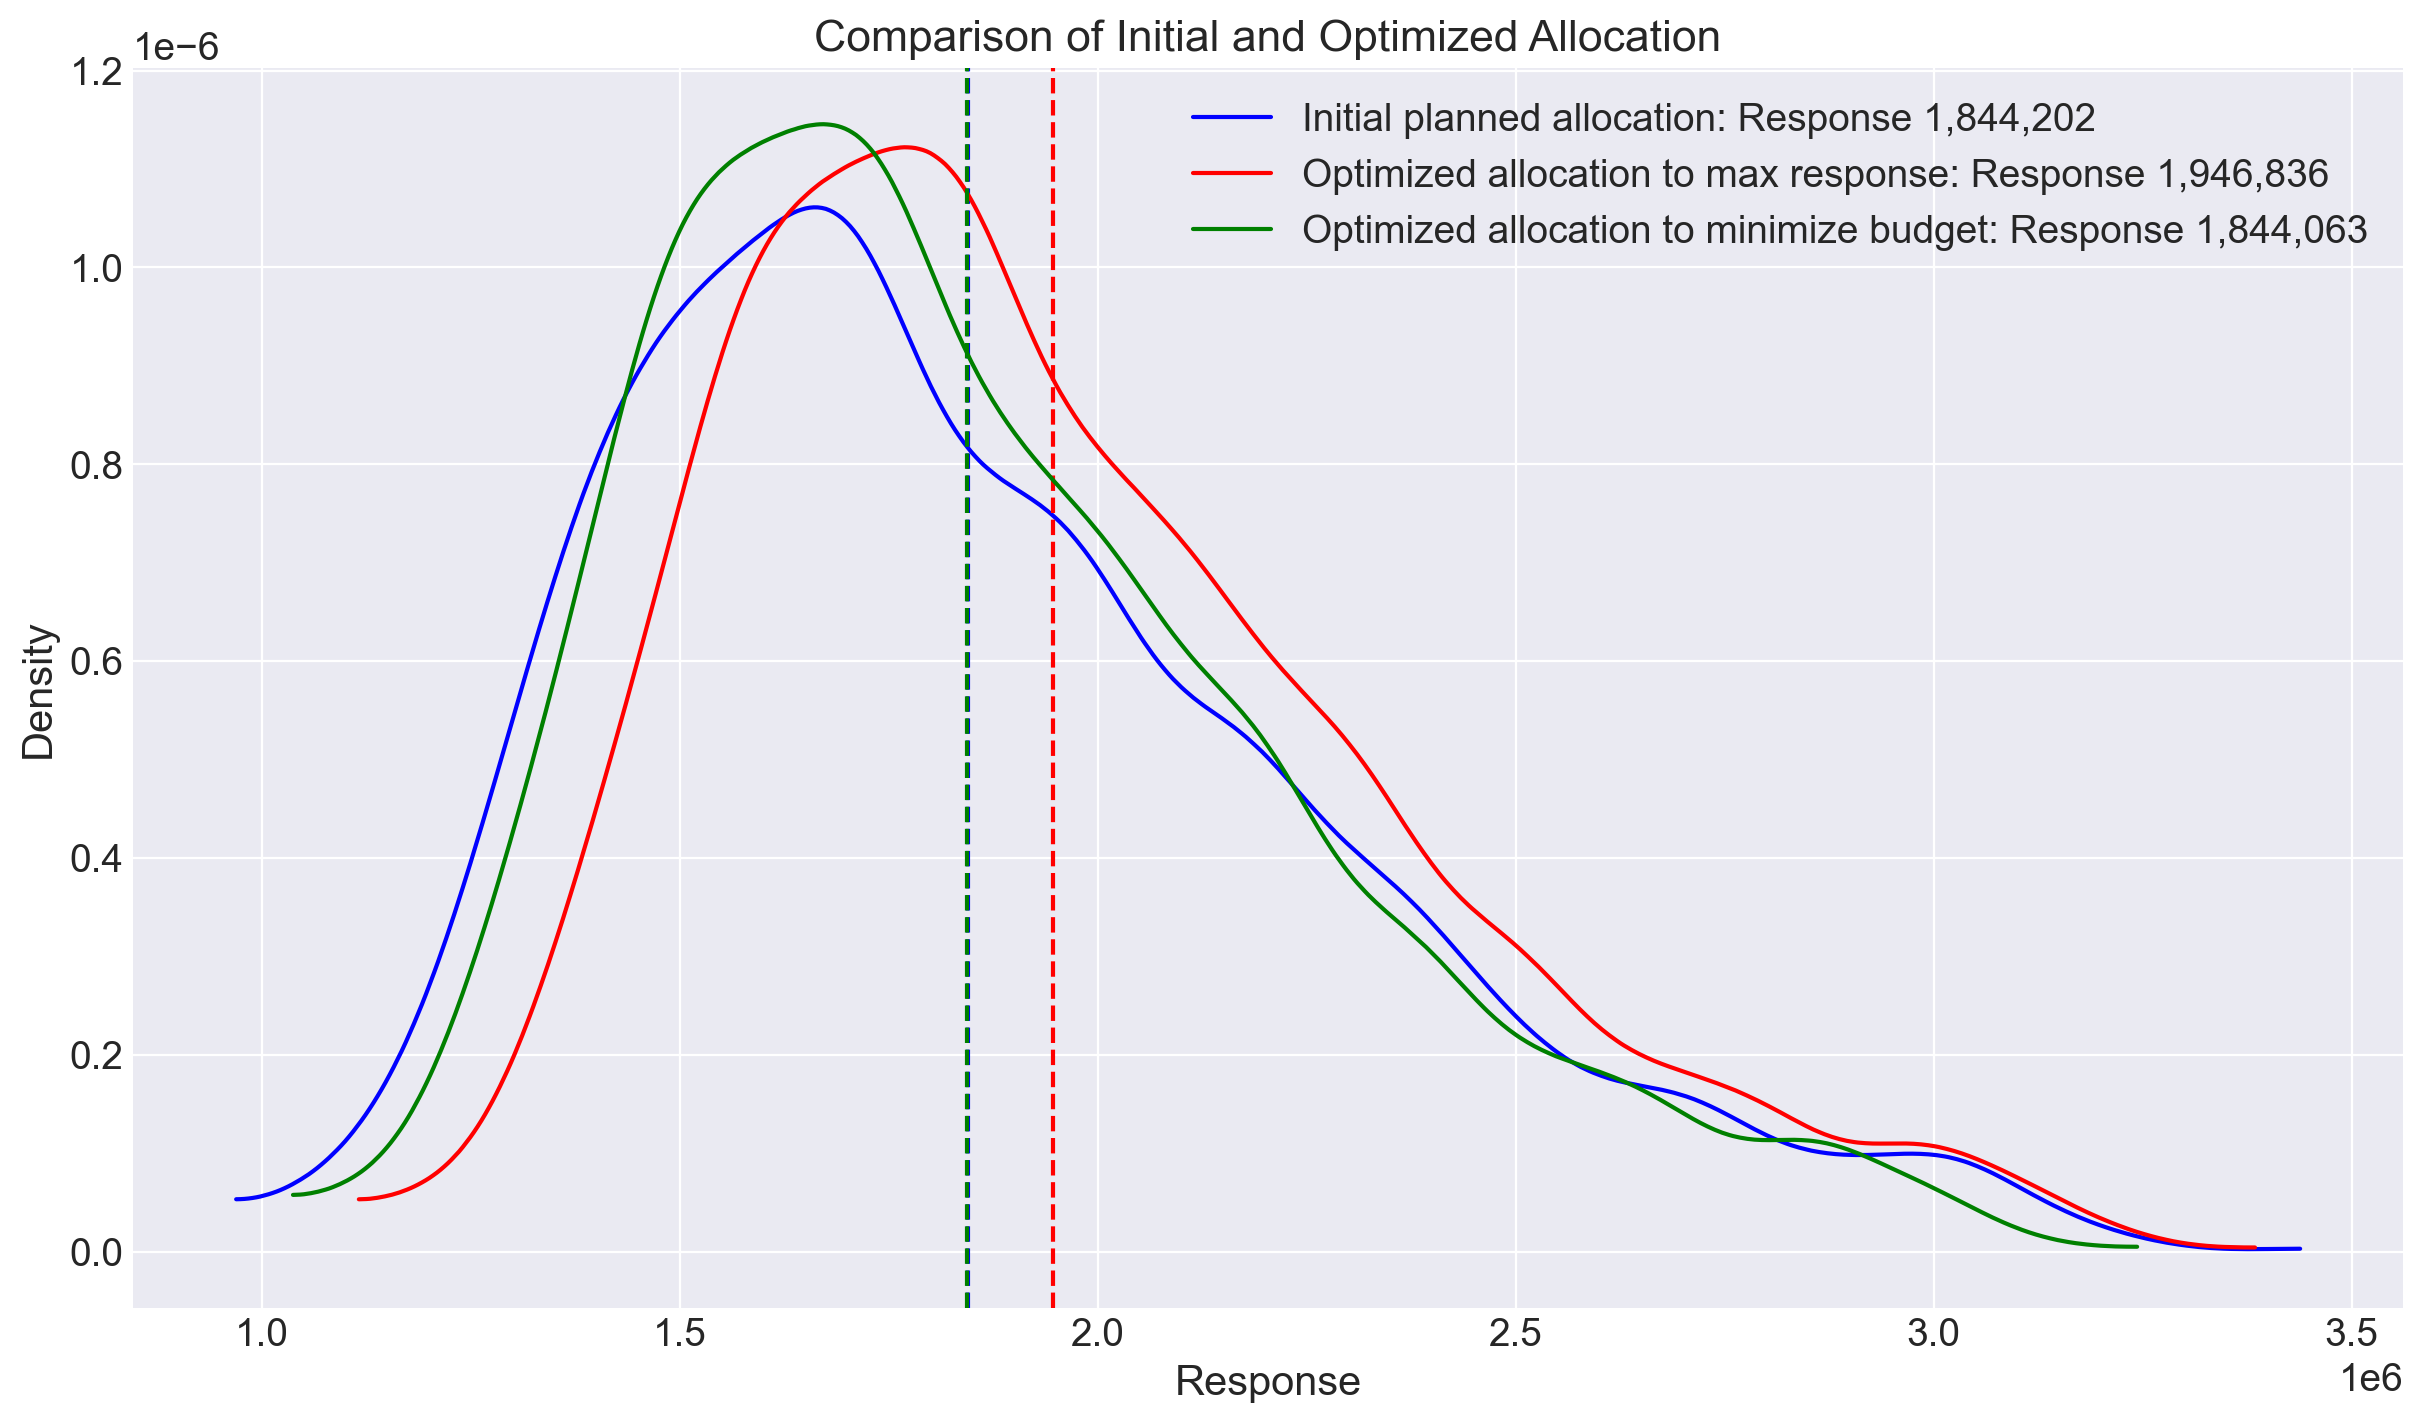

In [48]:
fig, ax = plt.subplots()

# Initial planned allocation
initial_data = sample_response_give_initial_budget.total_media_contribution_original_scale.values.flatten()
initial_mean = initial_data.mean()
az.plot_dist(
    initial_data,
    # hdi_prob=0.75,
    color="blue",
    label=f"Initial planned allocation: Response {initial_mean:,.0f}",
    ax=ax,
    # kind="hist",
)
ax.axvline(initial_mean, color="blue", linestyle="--")

# Optimized allocation based on maximizing the response
optimized_data = sample_response_given_allocation.total_media_contribution_original_scale.values.flatten()
optimized_mean = optimized_data.mean()
az.plot_dist(
    optimized_data,
    # hdi_prob=0.75,
    color="red",
    label=f"Optimized allocation to max response: Response {optimized_mean:,.0f}",
    ax=ax,
    # kind="hist",
)
ax.axvline(optimized_mean, color="red", linestyle="--")

# Optimized allocation based on minimizing the budget
optimized_data_target_response = sample_response_given_allocation_target_response.total_media_contribution_original_scale.values.flatten()  # noqa: E501
optimized_mean_target_response = optimized_data_target_response.mean()
az.plot_dist(
    optimized_data_target_response,
    # hdi_prob=0.75,
    color="green",
    label=f"Optimized allocation to minimize budget: Response {optimized_mean_target_response:,.0f}",
    ax=ax,
    # kind="hist",
)
ax.axvline(optimized_mean_target_response, color="green", linestyle="--")

ax.set_title("Comparison of Initial and Optimized Allocation")
ax.set_xlabel("Response")
ax.set_ylabel("Density")
ax.legend()

plt.show()

## Save and load model

In [96]:
# Save the model
mmm.save("demo-allocation.nc")

In [6]:
# Load the model
mmm= MMM.load("demo-allocation.nc")

/Users/Office/.local/lib/python3.12/site-packages/pymc_extras/prior.py:822: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


In [7]:
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)